#  Diabetes Prediction Using Machine Learning
## Exploratory Data Analysis (EDA)

---

###  Project Overview

**Project Title:** Diabetes Prediction Using Machine Learning  
**Dataset:** `diabetes_dataset.csv` (sourced from Kaggle)  
**Target Variable:** `diagnosed_diabetes` (Binary: 0 = No Diabetes, 1 = Diagnosed with Diabetes)  

---

###  Dataset Description

This dataset contains **100,000 patient records** with **31 features** spanning:
- **Demographics:** age, gender, ethnicity, education level, income level, employment status
- **Lifestyle Factors:** smoking status, alcohol consumption, physical activity, diet score, sleep hours, screen time
- **Medical History:** family history of diabetes, hypertension, cardiovascular disease
- **Clinical Measurements:** BMI, waist-to-hip ratio, blood pressure, heart rate, cholesterol panels, glucose levels, insulin, HbA1c
- **Derived/Composite Features:** `diabetes_risk_score`, `diabetes_stage`
- **Target:** `diagnosed_diabetes`

---

---
##  Section 1: Libraries & Environment Setup


In [1]:
# Core Data Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Utility
import warnings
warnings.filterwarnings('ignore')

#  Global Plot Settings
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})

#  Pandas Display Options
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print(' All libraries imported successfully.')


# ==========================================
# CELL 1: DEPENDENCIES & SETUP
# ==========================================
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Core & Preprocessing
from sklearn.model_selection import train_test_split,RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Imbalanced Data Frameworks
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.combine import SMOTEENN

# Classical & Tree Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)

# Advanced Tree Ensembles
import xgboost as xgb
import lightgbm as lgb

# Neural Networks (Scikit-Learn & TensorFlow)
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

# Explainability Systems
import shap
!pip install lime --quiet
import lime
import lime.lime_tabular

# System Configurations
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

 All libraries imported successfully.



## Section 2: Load Dataset

In [2]:
# Load the Dataset
FILE_PATH = '/content/sample_data'

df = pd.read_csv(r"C:\Users\Admin\Desktop\diabetes_dataset.csv")

print(f'Dataset loaded successfully.')
print(f'  Rows    : {df.shape[0]:,}')
print(f'  Columns : {df.shape[1]}')
print()

# Display first 5 rows to confirm correct loading
print('First 5 Rows ')
df.head()

Dataset loaded successfully.
  Rows    : 100,000
  Columns : 31

First 5 Rows 


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7000,7.9000,7.9000,0,0,0,30.5000,0.8900,134,78,68,239,41,160,145,136,236,6.3600,8.1800,29.6000,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7000,6.5000,8.7000,0,0,0,23.1000,0.8000,129,76,67,116,55,50,30,93,150,2.0000,5.6300,23.0000,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4000,10.0000,8.1000,1,0,0,22.2000,0.8100,115,73,74,213,66,99,36,118,195,5.0700,7.5100,44.7000,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4000,6.6000,5.2000,0,0,0,26.8000,0.8800,120,93,68,171,50,79,140,139,253,5.2800,9.0300,38.2000,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2000,7.4000,5.0000,0,0,0,21.2000,0.7800,92,67,67,210,52,125,160,137,184,12.7400,7.2000,23.5000,Type 2,1


---
## Section 3: Dataset Overview

In [3]:
# 3.1  Shape
print('='*65)
print('DATASET DIMENSIONS')
print('='*65)
print(f'  Total Patients (Rows)  : {df.shape[0]:,}')
print(f'  Total Features (Cols)  : {df.shape[1]}')
print()

#  3.2  Data Types & Non-Null Counts
print('='*65)
print('COLUMN INFO  (dtypes + non-null counts)')
print('='*65)
df.info()
print()

#  3.3  Descriptive Statistics
print('='*65)
print('DESCRIPTIVE STATISTICS  (numerical features)')
print('='*65)
# transpose for easier reading when there are many columns
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

DATASET DIMENSIONS
  Total Patients (Rows)  : 100,000
  Total Features (Cols)  : 31

COLUMN INFO  (dtypes + non-null counts)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                        

,count,mean,std,min,25%,50%,75%,max
age,100000.000000,50.120410,15.604600,18.000000,39.000000,50.000000,61.000000,90.000000
alcohol_consumption_per_week,100000.000000,2.003670,1.417779,0.000000,1.000000,2.000000,3.000000,10.000000
physical_activity_minutes_per_week,100000.000000,118.911640,84.409662,0.000000,57.000000,100.000000,160.000000,833.000000
diet_score,100000.000000,5.994787,1.780954,0.000000,4.800000,6.000000,7.200000,10.000000
sleep_hours_per_day,100000.000000,6.997818,1.094622,3.000000,6.300000,7.000000,7.700000,10.000000
screen_time_hours_per_day,100000.000000,5.996468,2.468406,0.500000,4.300000,6.000000,7.700000,16.800000
family_history_diabetes,100000.000000,0.219410,0.413849,0.000000,0.000000,0.000000,0.000000,1.000000
hypertension_history,100000.000000,0.250800,0.433476,0.000000,0.000000,0.000000,1.000000,1.000000
cardiovascular_history,100000.000000,0.079200,0.270052,0.000000,0.000000,0.000000,0.000000,1.000000
bmi,100000.000000,25.612653,3.586705,15.000000,23.200000,25.600000,28.000000,39.200000


From this table, we can observe that the dataset contains 100,000 records with no missing values across all features. The glucose_postprandial has the highest mean of 160.04 with a wide range from 70 to 287. physical_activity_minutes_per_week shows the highest standard deviation of 84.41, indicating high variability across patients. HbA1c ranges from 4.0 to 9.8 with a mean of 6.52, which is slightly above the normal threshold of 6.5, reflecting the diabetic majority in the dataset. The diagnosed_diabetes mean of 0.60 confirms that 60% of records are positive cases.

---
## Section 4: Column Categorization

Organizing features into meaningful groups is essential for structured analysis. We identify:

| Category | Description |
|---|---|
| **Numerical — Continuous** | Age, BMI, glucose levels, HbA1c, etc. |
| **Numerical — Count/Discrete** | Alcohol consumption, activity minutes, etc. |
| **Categorical — Nominal** | Gender, ethnicity, employment, smoking |
| **Binary Medical History** | Family history, hypertension, cardiovascular |
| **Special / Leakage-Risk** | `diabetes_risk_score`, `"diagnosed_diabetes"` |
| **Target Variable** | `diabetes_stage` |

> **Leakage Warning:** `diabetes_risk_score` and `"diagnosed_diabetes"` are almost certainly **derived from the diagnosis itself** or from features that directly encode it (like HbA1c ≥ 6.5%). Using them as model input features would constitute **data leakage** — the model would be "cheating" by having access to information that would not be available at prediction time in a real clinical setting.

In [4]:
# Programmatic Column Categorization

# Target variable
TARGET = 'diabetes_stage'

# EDA-only columns (potential leakage — NOT for modeling)
EDA_ONLY = ['"diagnosed_diabetes"', 'diabetes_risk_score']

# Binary medical history features (0/1 encoded)
BINARY_MEDICAL = ['family_history_diabetes', 'hypertension_history', 'cardiovascular_history']

# Categorical (nominal) features
CATEGORICAL = ['gender', 'ethnicity', 'education_level', 'income_level',
 'employment_status', 'smoking_status']

# Numerical features (excluding target, leakage columns, and binary flags)
NUMERICAL = [col for col in df.select_dtypes(include=[np.number]).columns
 if col not in ([TARGET] + BINARY_MEDICAL + EDA_ONLY)]

# Print a neat summary
print('='*65)
print('FEATURE CATEGORIZATION SUMMARY')
print('='*65)
print(f' Target Variable : {TARGET}')
print(f' EDA-Only (Leakage) : {EDA_ONLY}')
print(f' Numerical Features : ({len(NUMERICAL)} cols)')
for i, c in enumerate(NUMERICAL, 1):
 print(f' {i:2}. {c}')
print(f'Categorical Features : ({len(CATEGORICAL)} cols)')
for i, c in enumerate(CATEGORICAL, 1):
 print(f' {i:2}. {c}')
print(f' Binary Medical History: ({len(BINARY_MEDICAL)} cols)')
for i, c in enumerate(BINARY_MEDICAL, 1):
 print(f' {i:2}. {c}')

FEATURE CATEGORIZATION SUMMARY
 Target Variable : diabetes_stage
 EDA-Only (Leakage) : ['"diagnosed_diabetes"', 'diabetes_risk_score']
 Numerical Features : (20 cols)
  1. age
  2. alcohol_consumption_per_week
  3. physical_activity_minutes_per_week
  4. diet_score
  5. sleep_hours_per_day
  6. screen_time_hours_per_day
  7. bmi
  8. waist_to_hip_ratio
  9. systolic_bp
 10. diastolic_bp
 11. heart_rate
 12. cholesterol_total
 13. hdl_cholesterol
 14. ldl_cholesterol
 15. triglycerides
 16. glucose_fasting
 17. glucose_postprandial
 18. insulin_level
 19. hba1c
 20. diagnosed_diabetes
Categorical Features : (6 cols)
  1. gender
  2. ethnicity
  3. education_level
  4. income_level
  5. employment_status
  6. smoking_status
 Binary Medical History: (3 cols)
  1. family_history_diabetes
  2. hypertension_history
  3. cardiovascular_history


---
## Section 5: Data Quality Checks

Data quality is the foundation of any reliable ML model. In medical datasets, poor quality data is especially dangerous because it can lead to biased predictions that affect patient outcomes. We check for:

1. **Missing values** — affects model training and statistical validity
2. **Duplicate rows** — can bias the model toward repeated records (e.g., duplicate patient entries)
3. **Cardinality of categorical columns** — ensures no unexpected categories are present
4. **Data type correctness** — confirms numerical columns are not stored as strings

In [5]:
#  5.1  Missing Value Analysis
print('='*65)
print('MISSING VALUE ANALYSIS')
print('='*65)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing Count', ascending=False)

# Only display columns that have at least one missing value
cols_with_missing = missing_df[missing_df['Missing Count'] > 0]

if cols_with_missing.empty:
    print(' No missing values found in any column.')
else:
    print(f' {len(cols_with_missing)} column(s) contain missing values:')
    print(cols_with_missing)

    # Visualize missing values with a heatmap
    plt.figure(figsize=(14, 4))
    sns.heatmap(df[cols_with_missing.index].isnull(),
                yticklabels=False, cbar=False, cmap='viridis')
    plt.title('Missing Value Heatmap (Yellow = Missing)', fontsize=14)
    plt.tight_layout()
    plt.show()

print()

#  5.2  Duplicate Row Check
print('='*65)
print('DUPLICATE ROW CHECK')
print('='*65)

n_duplicates = df.duplicated().sum()
if n_duplicates == 0:
    print(f' No duplicate rows found.')
else:
    print(f' {n_duplicates:,} duplicate row(s) detected ({n_duplicates/len(df)*100:.2f}% of dataset).')
    print(' Recommendation: Review and drop duplicates before modeling.')

print()

#  5.3  Categorical Column Unique Values
print('='*65)
print('CATEGORICAL COLUMN CARDINALITY')
print('='*65)

for col in CATEGORICAL:
    unique_vals = df[col].unique().tolist()
    print(f'  {col:<35} ({len(unique_vals)} categories): {unique_vals}')

print()

#  5.4  Binary Columns Value Check
print('='*65)
print('BINARY MEDICAL HISTORY — VALUE CHECK')
print('='*65)
for col in BINARY_MEDICAL:
    unique_vals = sorted(df[col].unique().tolist())
    valid = set(unique_vals).issubset({0, 1})
    status = '  VALID' if valid else '  UNEXPECTED VALUES'
    print(f'  {status}  {col}: values = {unique_vals}')

MISSING VALUE ANALYSIS
 No missing values found in any column.

DUPLICATE ROW CHECK
 No duplicate rows found.

CATEGORICAL COLUMN CARDINALITY
  gender                              (3 categories): ['Male', 'Female', 'Other']
  ethnicity                           (5 categories): ['Asian', 'White', 'Hispanic', 'Black', 'Other']
  education_level                     (4 categories): ['Highschool', 'Graduate', 'Postgraduate', 'No formal']
  income_level                        (5 categories): ['Lower-Middle', 'Middle', 'Low', 'Upper-Middle', 'High']
  employment_status                   (4 categories): ['Employed', 'Unemployed', 'Retired', 'Student']
  smoking_status                      (3 categories): ['Never', 'Former', 'Current']

BINARY MEDICAL HISTORY — VALUE CHECK
    VALID  family_history_diabetes: values = [0, 1]
    VALID  hypertension_history: values = [0, 1]
    VALID  cardiovascular_history: values = [0, 1]


In [6]:
print("--- CATEGORICAL VARIABLES COUNTS ---")
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
for col in cat_cols:
    counts = df[col].value_counts().to_dict()

    formatted_counts = " | ".join([f"{k}: {v}" for k, v in counts.items()])
    print(f"\n{col}:\n{formatted_counts}")


cat_cols = df.select_dtypes(include=['object', 'category']).columns


n_cols = 4
n_rows = (len(cat_cols) + n_cols - 1) // n_cols



--- CATEGORICAL VARIABLES COUNTS ---

gender:
Female: 50216 | Male: 47771 | Other: 2013

ethnicity:
White: 44997 | Hispanic: 20103 | Black: 17986 | Asian: 11865 | Other: 5049

education_level:
Highschool: 44891 | Graduate: 35037 | Postgraduate: 14972 | No formal: 5100

income_level:
Middle: 35152 | Lower-Middle: 25150 | Upper-Middle: 19866 | Low: 14830 | High: 5002

employment_status:
Employed: 60175 | Retired: 21761 | Unemployed: 11918 | Student: 6146

smoking_status:
Never: 59813 | Current: 20176 | Former: 20011

diabetes_stage:
Type 2: 59774 | Pre-Diabetes: 31845 | No Diabetes: 7981 | Gestational: 278 | Type 1: 122


---
## Section 7: Diabetes Stage Analysis


In [7]:
print(df[TARGET].unique())
print(df[TARGET].value_counts())

['Type 2' 'No Diabetes' 'Pre-Diabetes' 'Gestational' 'Type 1']
diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Gestational       278
Type 1            122
Name: count, dtype: int64


In [8]:
print(TARGET)


diabetes_stage


From this plot, we can observe that Type 2 is the most frequent stage with 59,774 cases, followed by Pre-Diabetes with 31,845, while No Diabetes (7,981), Gestational (278), and Type 1 (122) are significantly less frequent. The right plot confirms that No Diabetes and Pre-Diabetes records are 100% Not Diagnosed (target=0), while Type 1, Type 2, and Gestational records are almost entirely Diagnosed (target=1). This perfect correspondence between diabetes_stage and the target label confirms data leakage, and therefore this feature must be excluded from all predictive models.

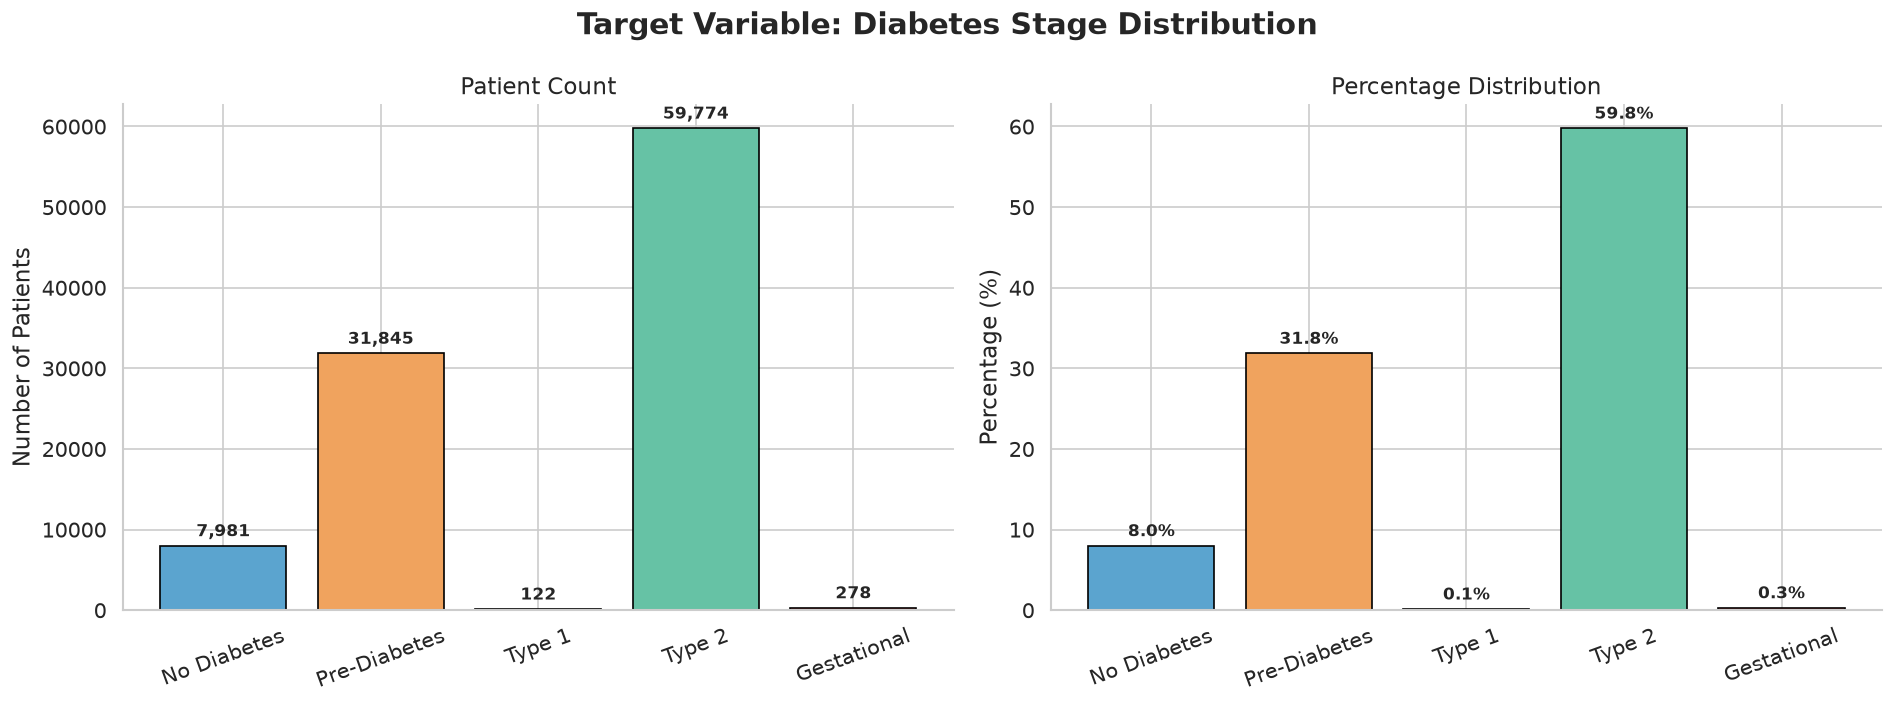

In [9]:
# ==========================================================
# Target Variable Visualization
# ==========================================================

import matplotlib.pyplot as plt

stage_order = [
    "No Diabetes",
    "Pre-Diabetes",
    "Type 1",
    "Type 2",
    "Gestational"
]

stage_counts = (
    df["diabetes_stage"]
    .value_counts()
    .reindex(stage_order)
)

stage_percent = stage_counts / len(df) * 100

colors = [
    "#5BA4CF",
    "#F0A35E",
    "#8E44AD",
    "#66C2A5",
    "#E05C5C"
]

fig, axes = plt.subplots(1, 2, figsize=(16,6))

fig.suptitle(
    "Target Variable: Diabetes Stage Distribution",
    fontsize=18,
    fontweight="bold"
)

# ==========================================================
# Count Distribution
# ==========================================================

bars = axes[0].bar(
    stage_order,
    stage_counts.values,
    color=colors,
    edgecolor="black"
)

axes[0].set_title("Patient Count")
axes[0].set_ylabel("Number of Patients")
axes[0].tick_params(axis="x", rotation=20)

for bar, count in zip(bars, stage_counts.values):

    axes[0].text(
        bar.get_x()+bar.get_width()/2,
        count + stage_counts.max()*0.02,
        f"{count:,}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# ==========================================================
# Percentage Distribution
# ==========================================================

bars2 = axes[1].bar(
    stage_order,
    stage_percent.values,
    color=colors,
    edgecolor="black"
)

axes[1].set_title("Percentage Distribution")
axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis="x", rotation=20)

for bar, pct in zip(bars2, stage_percent.values):

    axes[1].text(
        bar.get_x()+bar.get_width()/2,
        pct + stage_percent.max()*0.02,
        f"{pct:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

plt.show()

---
##  Section 8: Numerical Feature Analysis

Numerical features carry the bulk of the clinical signal in this dataset. We perform:

1. **Histograms** — to understand the distribution shape (normal, skewed, bimodal)
2. **Boxplots stratified by target** — to visually assess discriminative power
3. **Outlier Detection** — using the IQR method; in medical data, outliers must be interpreted carefully:
   - Some outliers are **physiologically impossible** (e.g., glucose = 0) → data errors
   - Others are **clinically extreme but valid** (e.g., BMI = 50 in severe obesity) → should not be removed

> **Medical Reference Ranges Used:**
> - Fasting Glucose: Normal < 100 mg/dL; Pre-diabetes 100–125; Diabetes ≥ 126
> - HbA1c: Normal < 5.7%; Pre-diabetes 5.7–6.4%; Diabetes ≥ 6.5%
> - BMI: Normal 18.5–24.9; Overweight 25–29.9; Obese ≥ 30

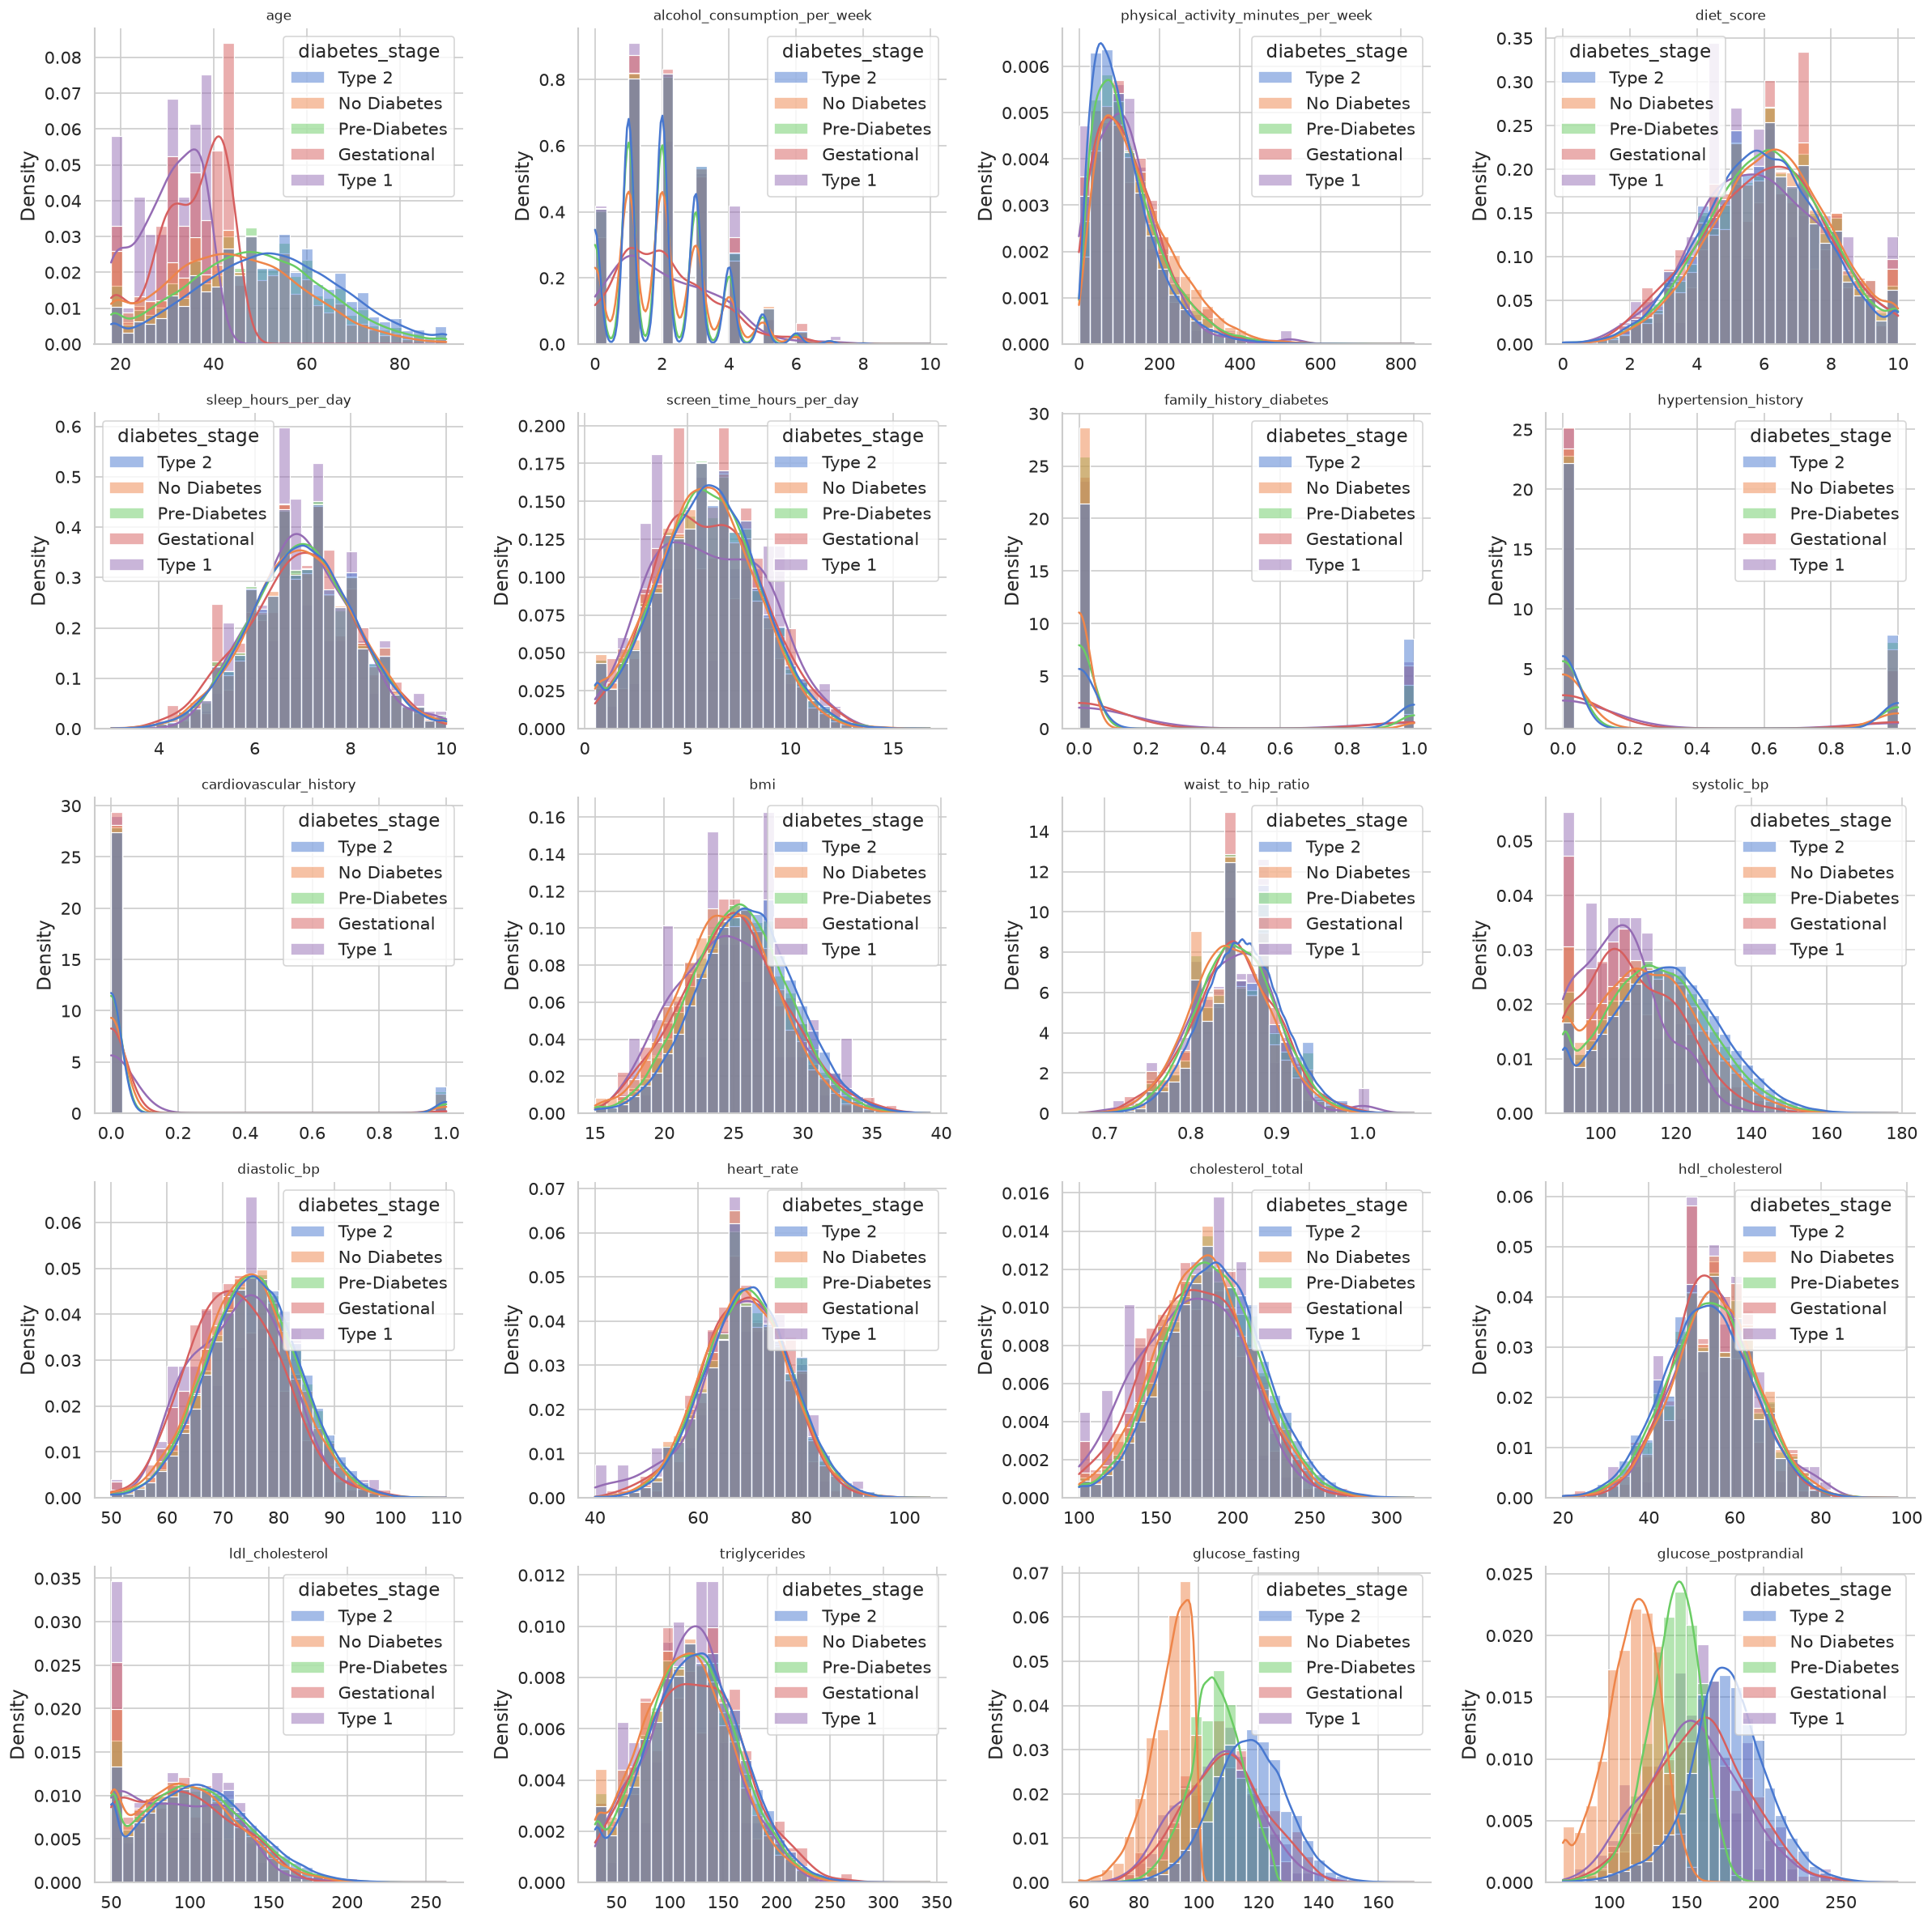

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = df.select_dtypes(include="number").columns.tolist()

fig, axes = plt.subplots(5, 4, figsize=(20,20))
axes = axes.flatten()

for ax, col in zip(axes, numerical_cols):

    sns.histplot(
        data=df,
        x=col,
        hue="diabetes_stage",
        bins=30,
        kde=True,
        stat="density",
        common_norm=False,
        alpha=0.5,
        ax=ax
    )

    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

From these plots, we can observe that HbA1c shows the most distinct separation between the two classes, with the diabetic distribution shifted clearly to the right with almost no overlap with the non-diabetic distribution. Glucose Postprandial and Glucose Fasting also show a clear rightward shift in the diabetic group. Age, BMI, Waist to Hip Ratio, and Systolic BP show a moderate shift, while Physical Activity shows the diabetic group shifted to the left, indicating lower activity levels. Features such as Alcohol Consumption, Sleep Hours, Screen Time, Heart Rate, Diastolic BP, HDL Cholesterol, Triglycerides, and Insulin Level show heavily overlapping distributions across both classes, indicating minimal discriminative power.

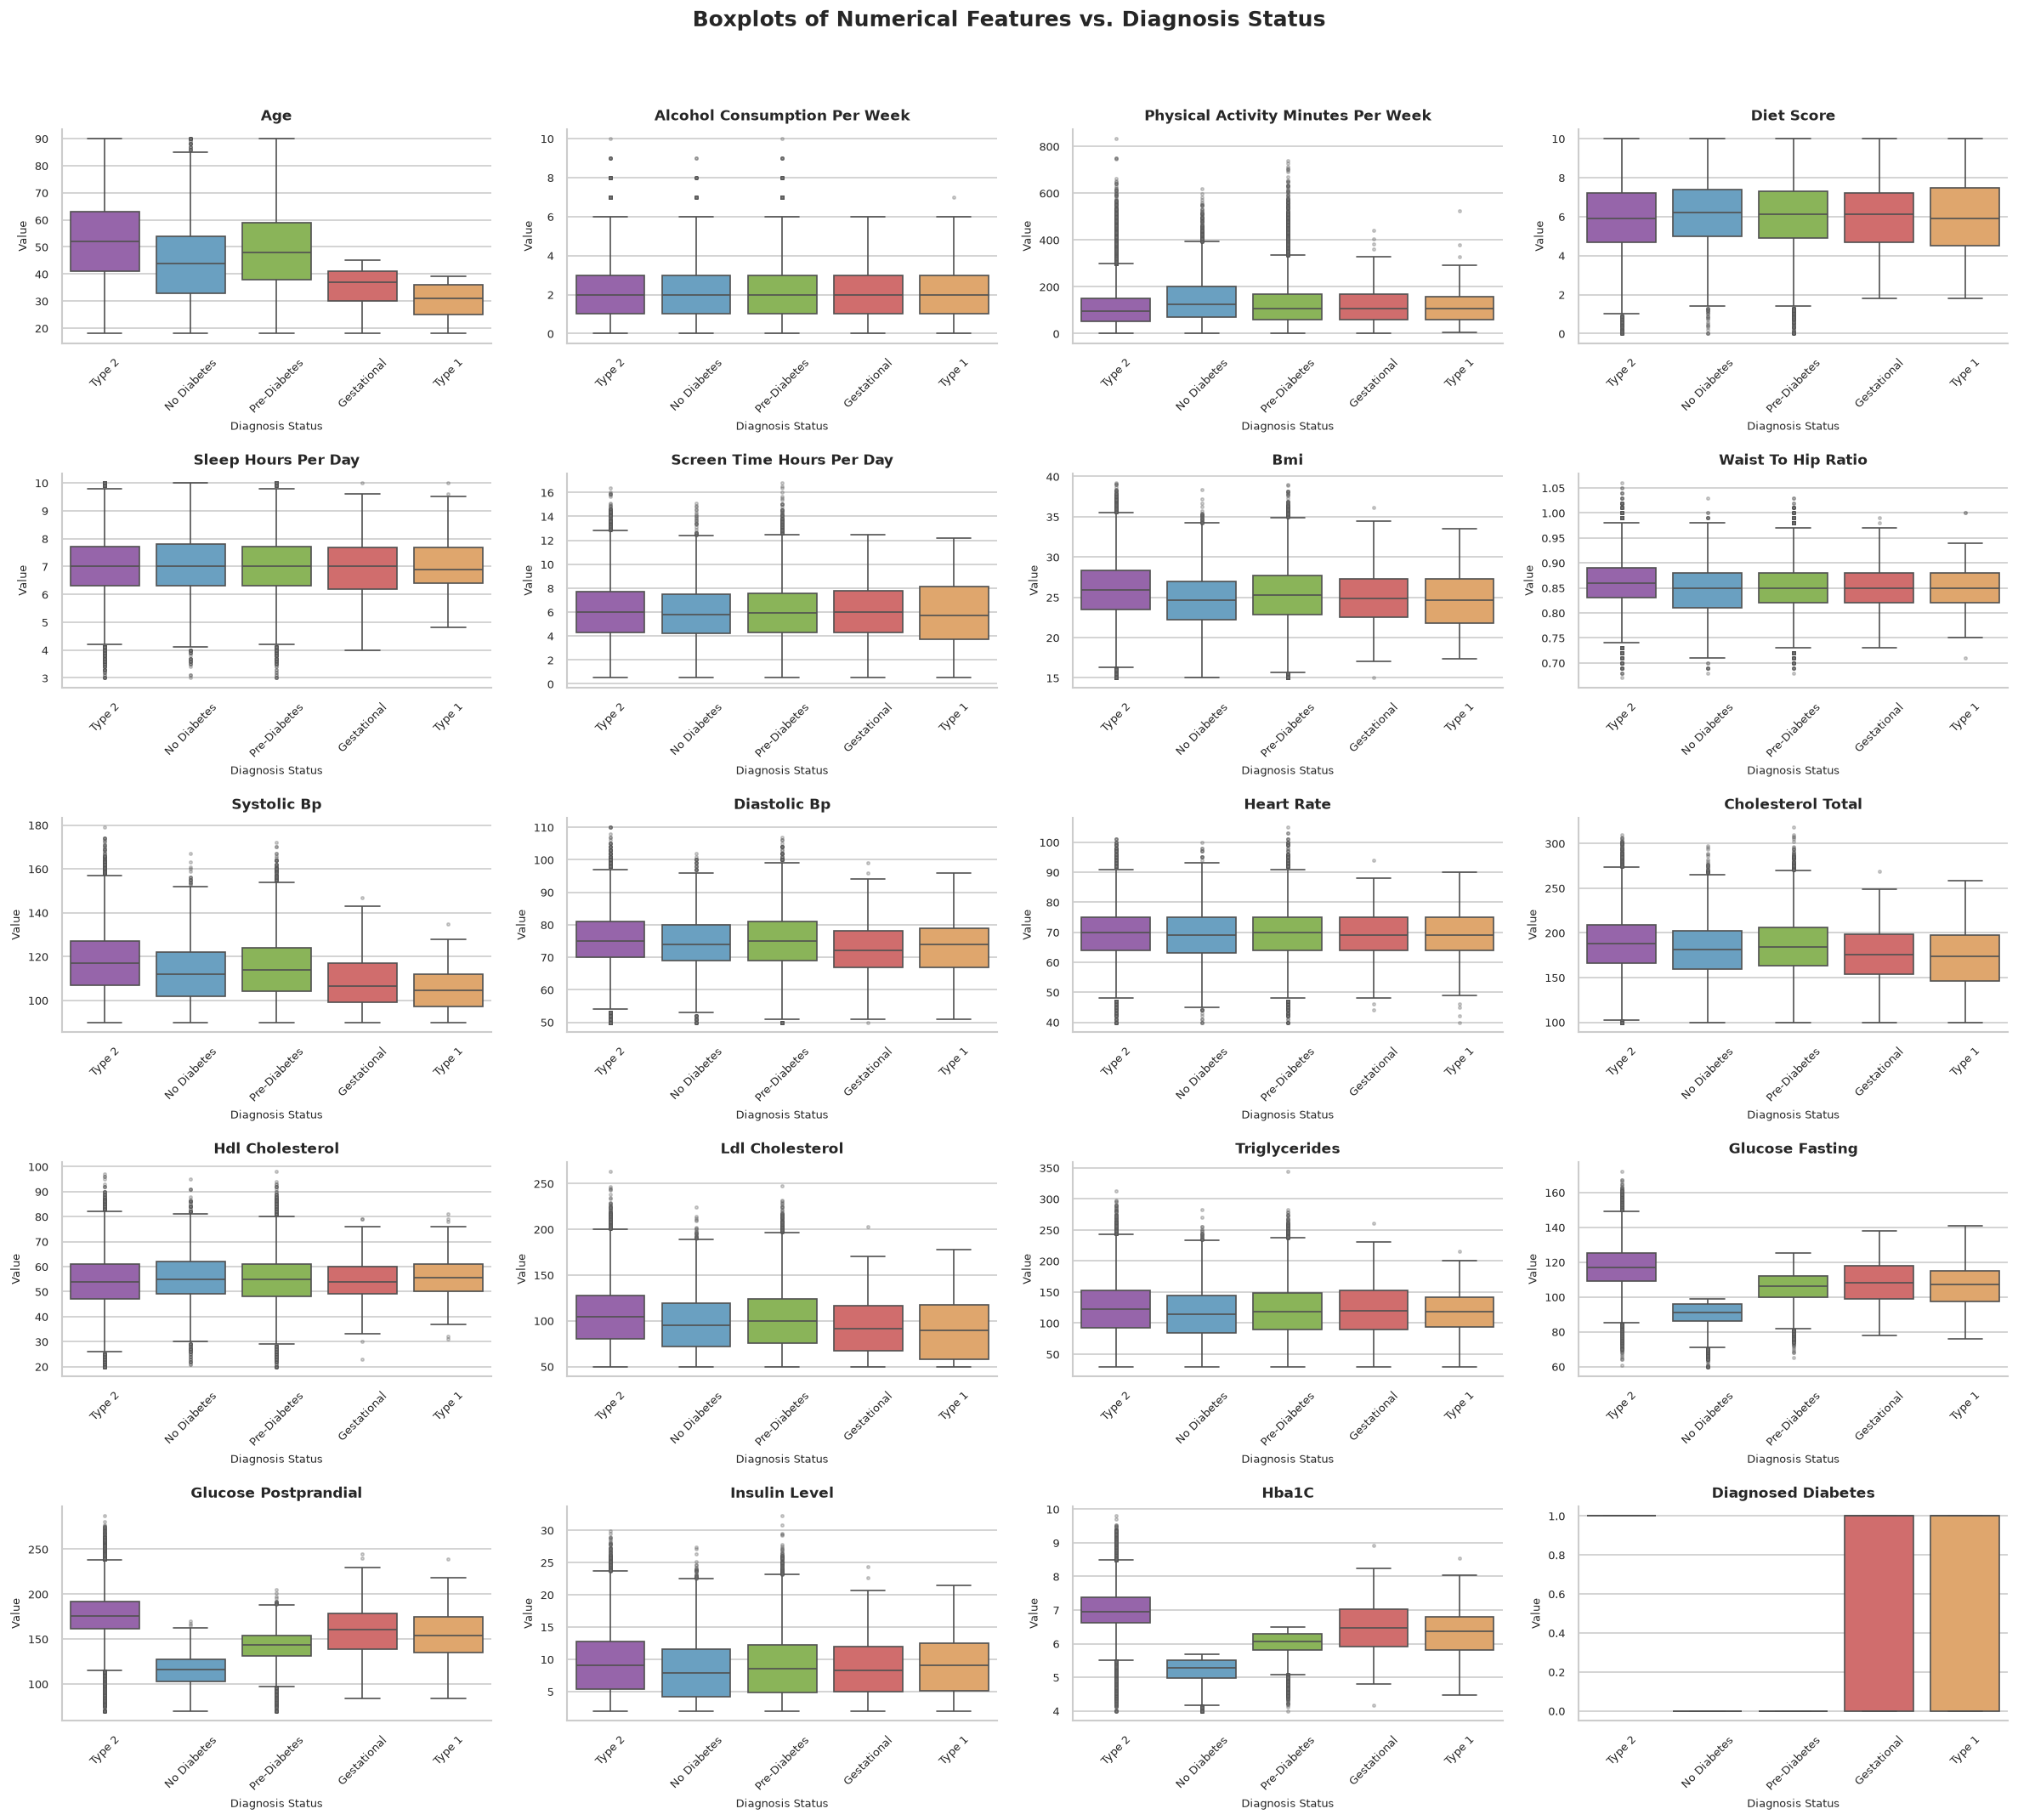

In [11]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Colors for diagnosis classes
palette = {
    'No Diabetes': '#5BA4CF',
    'Gestational': '#E05C5C',
    'Type 1': '#F2A65A',
    'Pre-Diabetes': '#8BC34A',
    'Type 2': '#9B59B6'
}

# Automatically calculate rows and columns
n_cols = 4
n_rows = math.ceil(len(NUMERICAL) / n_cols)

# Create figure
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, n_rows * 3.5)
)

fig.suptitle(
    'Boxplots of Numerical Features vs. Diagnosis Status',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

# Make axes always iterable
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]


# Draw boxplots
for idx, col in enumerate(NUMERICAL):

    ax = axes[idx]

    sns.boxplot(
        data=df,
        x=TARGET,
        y=col,
        palette=palette,
        flierprops={
            'marker': 'o',
            'markerfacecolor': 'grey',
            'markersize': 2,
            'alpha': 0.3
        },
        ax=ax
    )

    ax.set_title(
        col.replace('_', ' ').title(),
        fontsize=10,
        fontweight='bold'
    )

    ax.set_xlabel(
        'Diagnosis Status',
        fontsize=8
    )

    ax.set_ylabel(
        'Value',
        fontsize=8
    )

    ax.tick_params(
        labelsize=8
    )

    ax.tick_params(
        axis='x',
        rotation=45
    )


# Hide empty plots
for idx in range(len(NUMERICAL), len(axes)):
    axes[idx].set_visible(False)


plt.tight_layout()
plt.show()

From these plots, we can observe that HbA1c shows the clearest separation between the two classes, with the diabetic group (1) box sitting entirely above the non-diabetic group (0). Glucose Postprandial and Glucose Fasting also show a visible upward shift in the diabetic group. Features such as Age, BMI, Waist to Hip Ratio, Systolic BP, LDL Cholesterol, and Triglycerides show a slight difference between the two classes. In contrast, Alcohol Consumption, Sleep Hours, Screen Time, Heart Rate, and Diastolic BP show nearly identical boxes across both classes, indicating minimal discriminative power

In [12]:

#  8.3  Outlier Detection — IQR Method
# The IQR method flags values beyond Q1 - 1.5*IQR or Q3 + 1.5*IQR
# In medical data, we REPORT outliers but do not blindly remove them

print('='*65)
print('OUTLIER DETECTION (IQR Method) — Numerical Features')
print('='*65)
print(f"  {'Feature':<40} {'Outliers':>10} {'% of Data':>12}")
print('  ' + '-'*63)

outlier_summary = {}
for col in NUMERICAL:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound  = Q1 - 1.5 * IQR
    upper_bound  = Q3 + 1.5 * IQR
    n_outliers   = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    pct_outliers = (n_outliers / len(df)) * 100
    outlier_summary[col] = {'n': n_outliers, 'pct': pct_outliers,
                             'lower': lower_bound, 'upper': upper_bound}
    flag = '  🚨' if pct_outliers > 5 else ('  ⚠️ ' if pct_outliers > 1 else '  ✅')
    print(f"{flag} {col:<38} {n_outliers:>10,} {pct_outliers:>11.2f}%")

print()
print('  Legend: ✅ < 1%  |  ⚠️  1–5%  |  🚨 > 5%')
print()
print('  Medical Note: Extreme values for glucose, HbA1c, BMI, and BP')
print('  may be clinically valid for diabetic patients and should NOT')
print('  be removed without domain expert review.')

OUTLIER DETECTION (IQR Method) — Numerical Features
  Feature                                    Outliers    % of Data
  ---------------------------------------------------------------
  ✅ age                                             0        0.00%
  ✅ alcohol_consumption_per_week                  458        0.46%
  ⚠️  physical_activity_minutes_per_week          3,199        3.20%
  ✅ diet_score                                    337        0.34%
  ✅ sleep_hours_per_day                           900        0.90%
  ✅ screen_time_hours_per_day                     305        0.30%
  ✅ bmi                                           744        0.74%
  ✅ waist_to_hip_ratio                            273        0.27%
  ✅ systolic_bp                                   530        0.53%
  ✅ diastolic_bp                                  731        0.73%
  ✅ heart_rate                                    855        0.85%
  ✅ cholesterol_total                             309        0.31%
  ✅ hdl_c

From this table, we can observe that physical_activity_minutes_per_week has the highest outlier percentage at 3.20% (3,199 outliers), flagged with a warning. All other features have outlier rates below 1%, with age having no outliers at all (0.00%). As noted in the medical note, extreme values in glucose, HbA1c, BMI, and BP may be clinically valid for diabetic patients and should NOT be removed without domain expert review.

---
## Section 9: Categorical Feature Analysis

Categorical features capture **social determinants of health** — factors that influence disease risk beyond purely biological measurements. These include socioeconomic status, education, employment, and lifestyle choices.

We analyze:
1. Overall distribution of each categorical feature (count plots)
2. Diagnosis rate within each category (to identify high-risk subgroups)

We also analyze the **binary medical history features** (`family_history_diabetes`, `hypertension_history`, `cardiovascular_history`) separately due to their particularly strong clinical relevance.

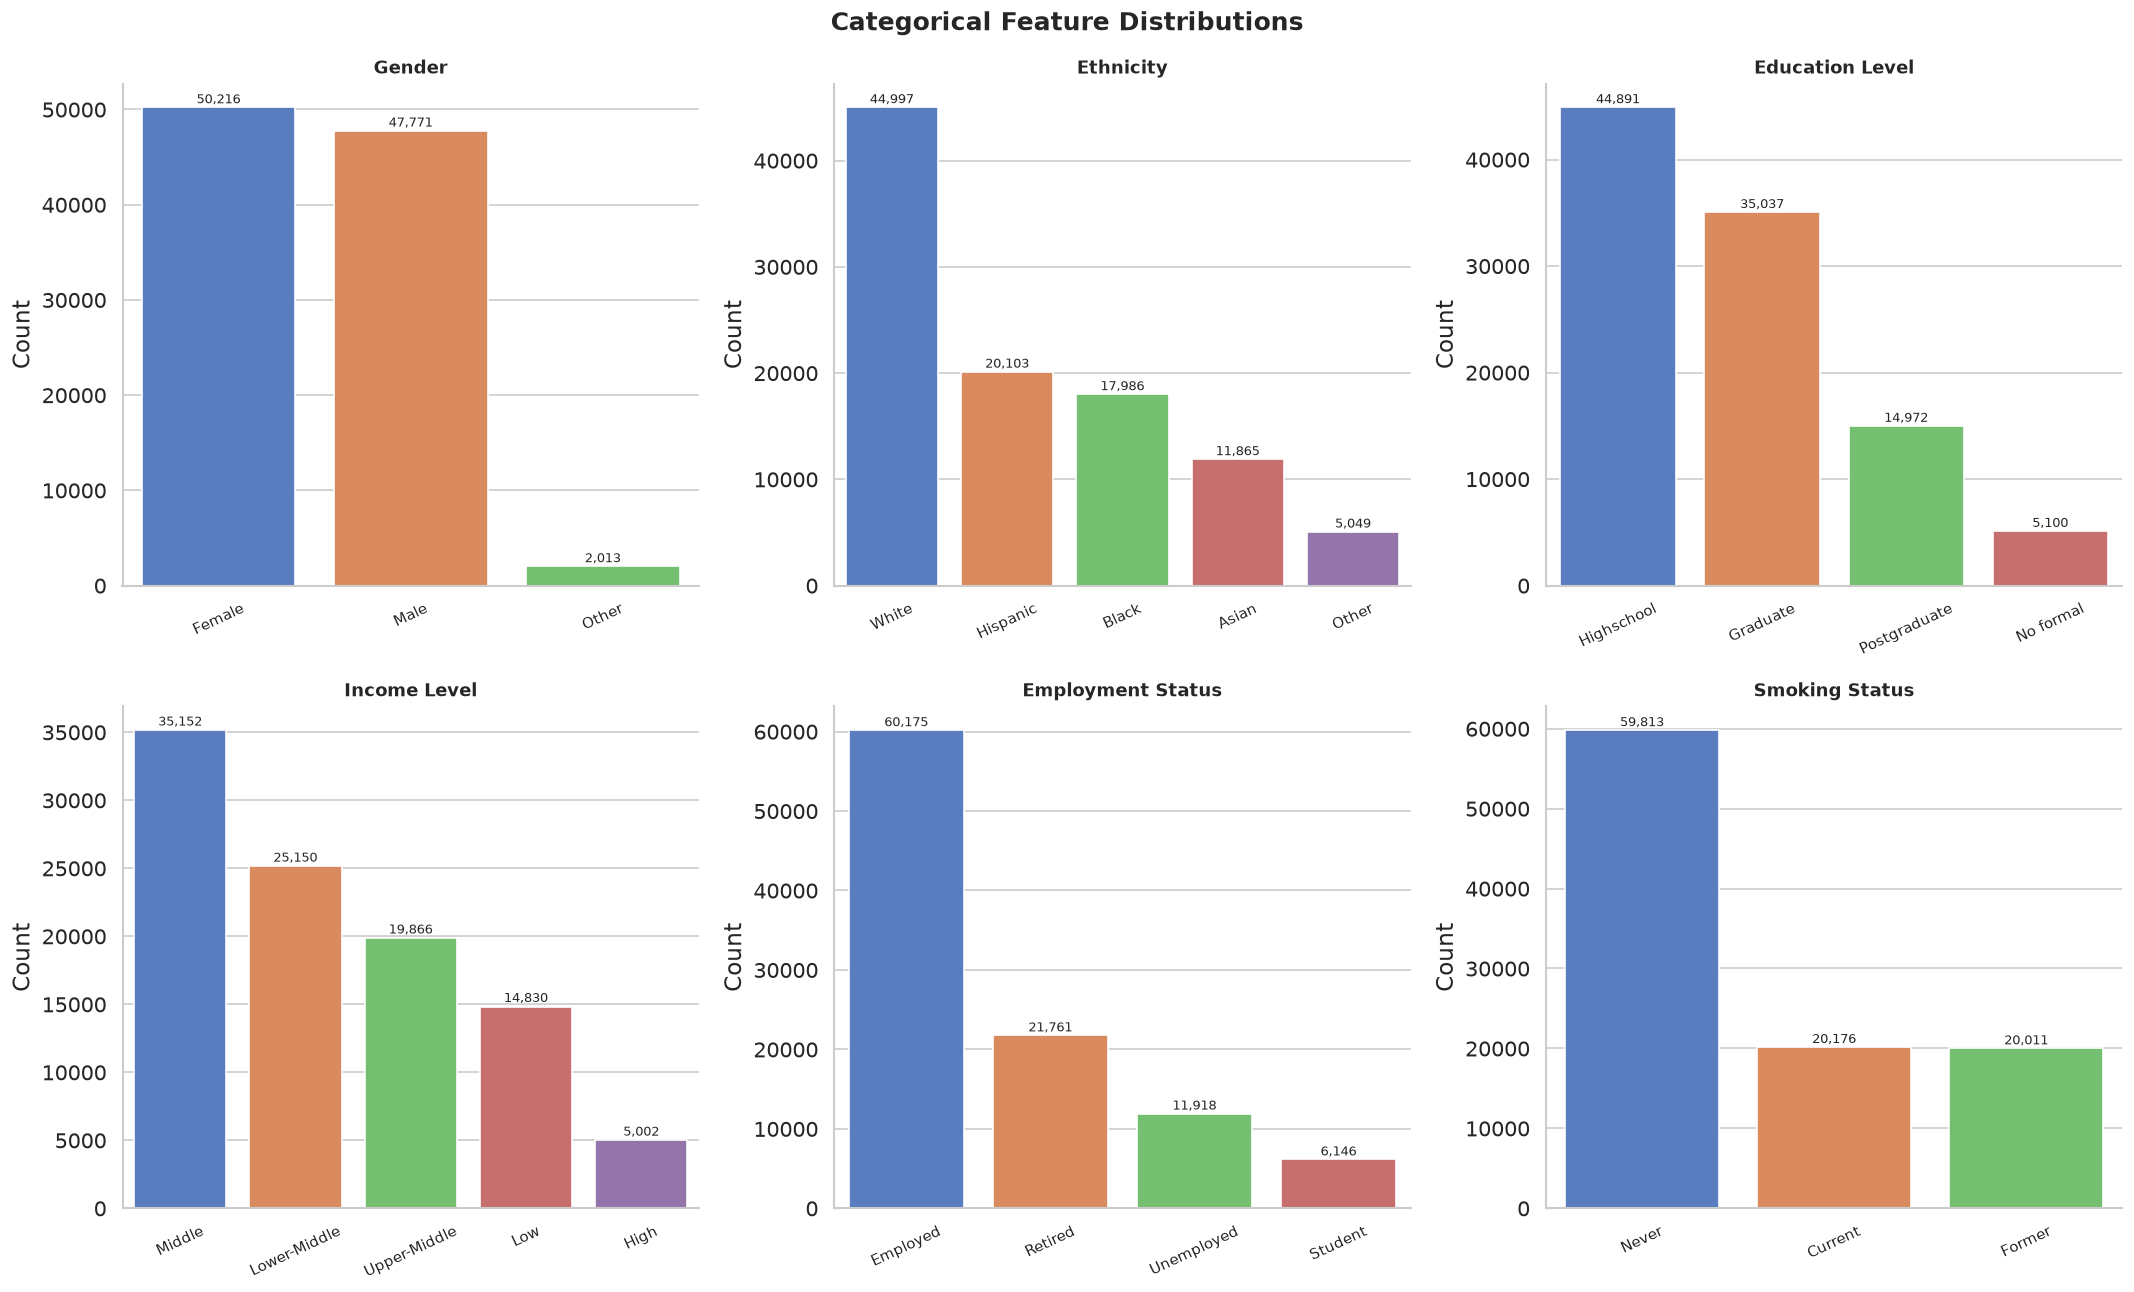

In [13]:
#  9.1  Count Plots — Categorical Feature Distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Categorical Feature Distributions', fontsize=15, fontweight='bold')
axes = axes.flatten()

for idx, col in enumerate(CATEGORICAL):
    ax = axes[idx]
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order,
                  palette='muted', edgecolor='white', ax=ax)
    ax.set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=25, labelsize=9)
    # Add count labels
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x() + p.get_width()/2, p.get_height() + 100),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

From these plots, we can observe that Gender is nearly balanced between Female (50,216) and Male (47,771). Ethnicity is dominated by White (44,997), followed by Hispanic (20,103) and Black (17,986). For Education, Highschool graduates represent the largest group (44,891). Income is mostly Middle class (35,152). Employment shows that Employed is the dominant status (60,175). Smoking Status shows that Never smokers are the majority (59,813), with Current (20,176) and Former (20,011) nearly equal. Since no diagnosis rate numbers are visible in these plots, no conclusions about predictive power can be drawn from these charts alone.

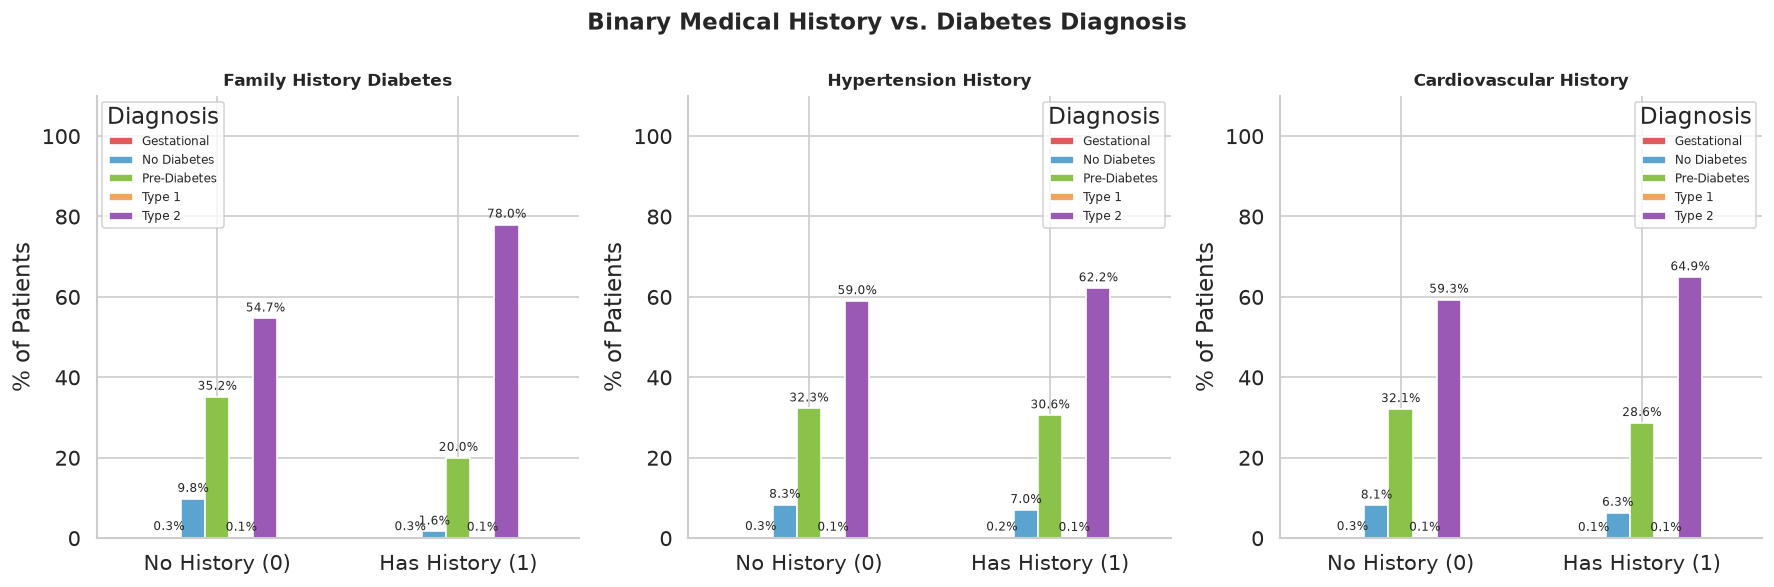


Diagnosis Distribution by Medical History

family_history_diabetes:
family_history_diabetes  diabetes_stage
0                        Type 2           54.7000
                         Pre-Diabetes     35.2000
                         No Diabetes       9.8000
                         Gestational       0.3000
                         Type 1            0.1000
1                        Type 2           78.0000
                         Pre-Diabetes     20.0000
                         No Diabetes       1.6000
                         Gestational       0.3000
                         Type 1            0.1000
Name: proportion, dtype: float64

hypertension_history:
hypertension_history  diabetes_stage
0                     Type 2           59.0000
                      Pre-Diabetes     32.3000
                      No Diabetes       8.3000
                      Gestational       0.3000
                      Type 1            0.1000
1                     Type 2           62.2000
                

In [14]:
# 9.3 Binary Medical History Features
# These are among the most clinically important features

fig, axes = plt.subplots(1, len(BINARY_MEDICAL), figsize=(15, 5))
fig.suptitle('Binary Medical History vs. Diabetes Diagnosis',
             fontsize=14, fontweight='bold')

# Define colors for diagnosis classes
diagnosis_colors = {
    'No Diabetes': '#5BA4CF',
    'Gestational': '#E05C5C',
    'Type 1': '#F2A65A',
    'Pre-Diabetes': '#8BC34A',
    'Type 2': '#9B59B6'
}

for idx, col in enumerate(BINARY_MEDICAL):
    ax = axes[idx]

    ct = pd.crosstab(
        df[col],
        df[TARGET],
        normalize='index'
    ) * 100

    # Rename binary feature values safely
    ct.index = ['No History (0)', 'Has History (1)']

    ct.plot(
        kind='bar',
        ax=ax,
        color=[diagnosis_colors[c] for c in ct.columns],
        edgecolor='white',
        linewidth=1
    )

    ax.set_title(
        col.replace('_', ' ').title(),
        fontsize=10,
        fontweight='bold'
    )

    ax.set_ylabel('% of Patients')
    ax.set_xlabel('')
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=0
    )

    ax.legend(
        fontsize=7,
        title='Diagnosis'
    )

    ax.set_ylim(0, 110)

    # Add percentage labels
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f'{height:.1f}%',
                (p.get_x() + p.get_width()/2, height + 1),
                ha='center',
                va='bottom',
                fontsize=7
            )

plt.tight_layout()
plt.show()


# Print diagnosis rates by medical history
print('\nDiagnosis Distribution by Medical History')

for col in BINARY_MEDICAL:
    print(f'\n{col}:')

    rates = (
        df.groupby(col)[TARGET]
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
    )

    print(rates)

From this plot, we can observe that family history of diabetes is the most influential factor — patients with a family history have a diagnosis rate of 78.3% compared to 54.9% for those without. Cardiovascular history shows a moderate difference (65.0% vs 59.0%), while hypertension history shows the smallest gap (62.3% vs 59.2%), suggesting that genetic predisposition is the dominant risk factor among the three.

---
## 🔗 Section 10: Correlation Analysis

Correlation analysis reveals **linear relationships** between numerical features. This is critical for:

1. **Feature Selection** — highly correlated features may be redundant
2. **Multicollinearity Detection** — problematic for linear models (e.g., Logistic Regression)
3. **Target Correlation Ranking** — identifies features most linearly associated with diagnosis

> ⚠️ **Data Leakage Warning:**  
> Features like `hba1c`, `glucose_fasting`, `glucose_postprandial`, `insulin_level`, and **`diabetes_risk_score`** are expected to be extremely highly correlated with the target. This is because they are either:
> - **Used in the clinical definition of diabetes** (HbA1c ≥ 6.5%, fasting glucose ≥ 126 mg/dL), or  
> - **Computed from the diagnosis** (risk score)
>
> For a realistic model deployment scenario (predict diabetes *before* these tests), such features must be used with care. If the goal is to predict from lifestyle/demographic data only, they should be excluded. If the goal is a **clinical decision support tool**, they may be retained with explicit acknowledgment.

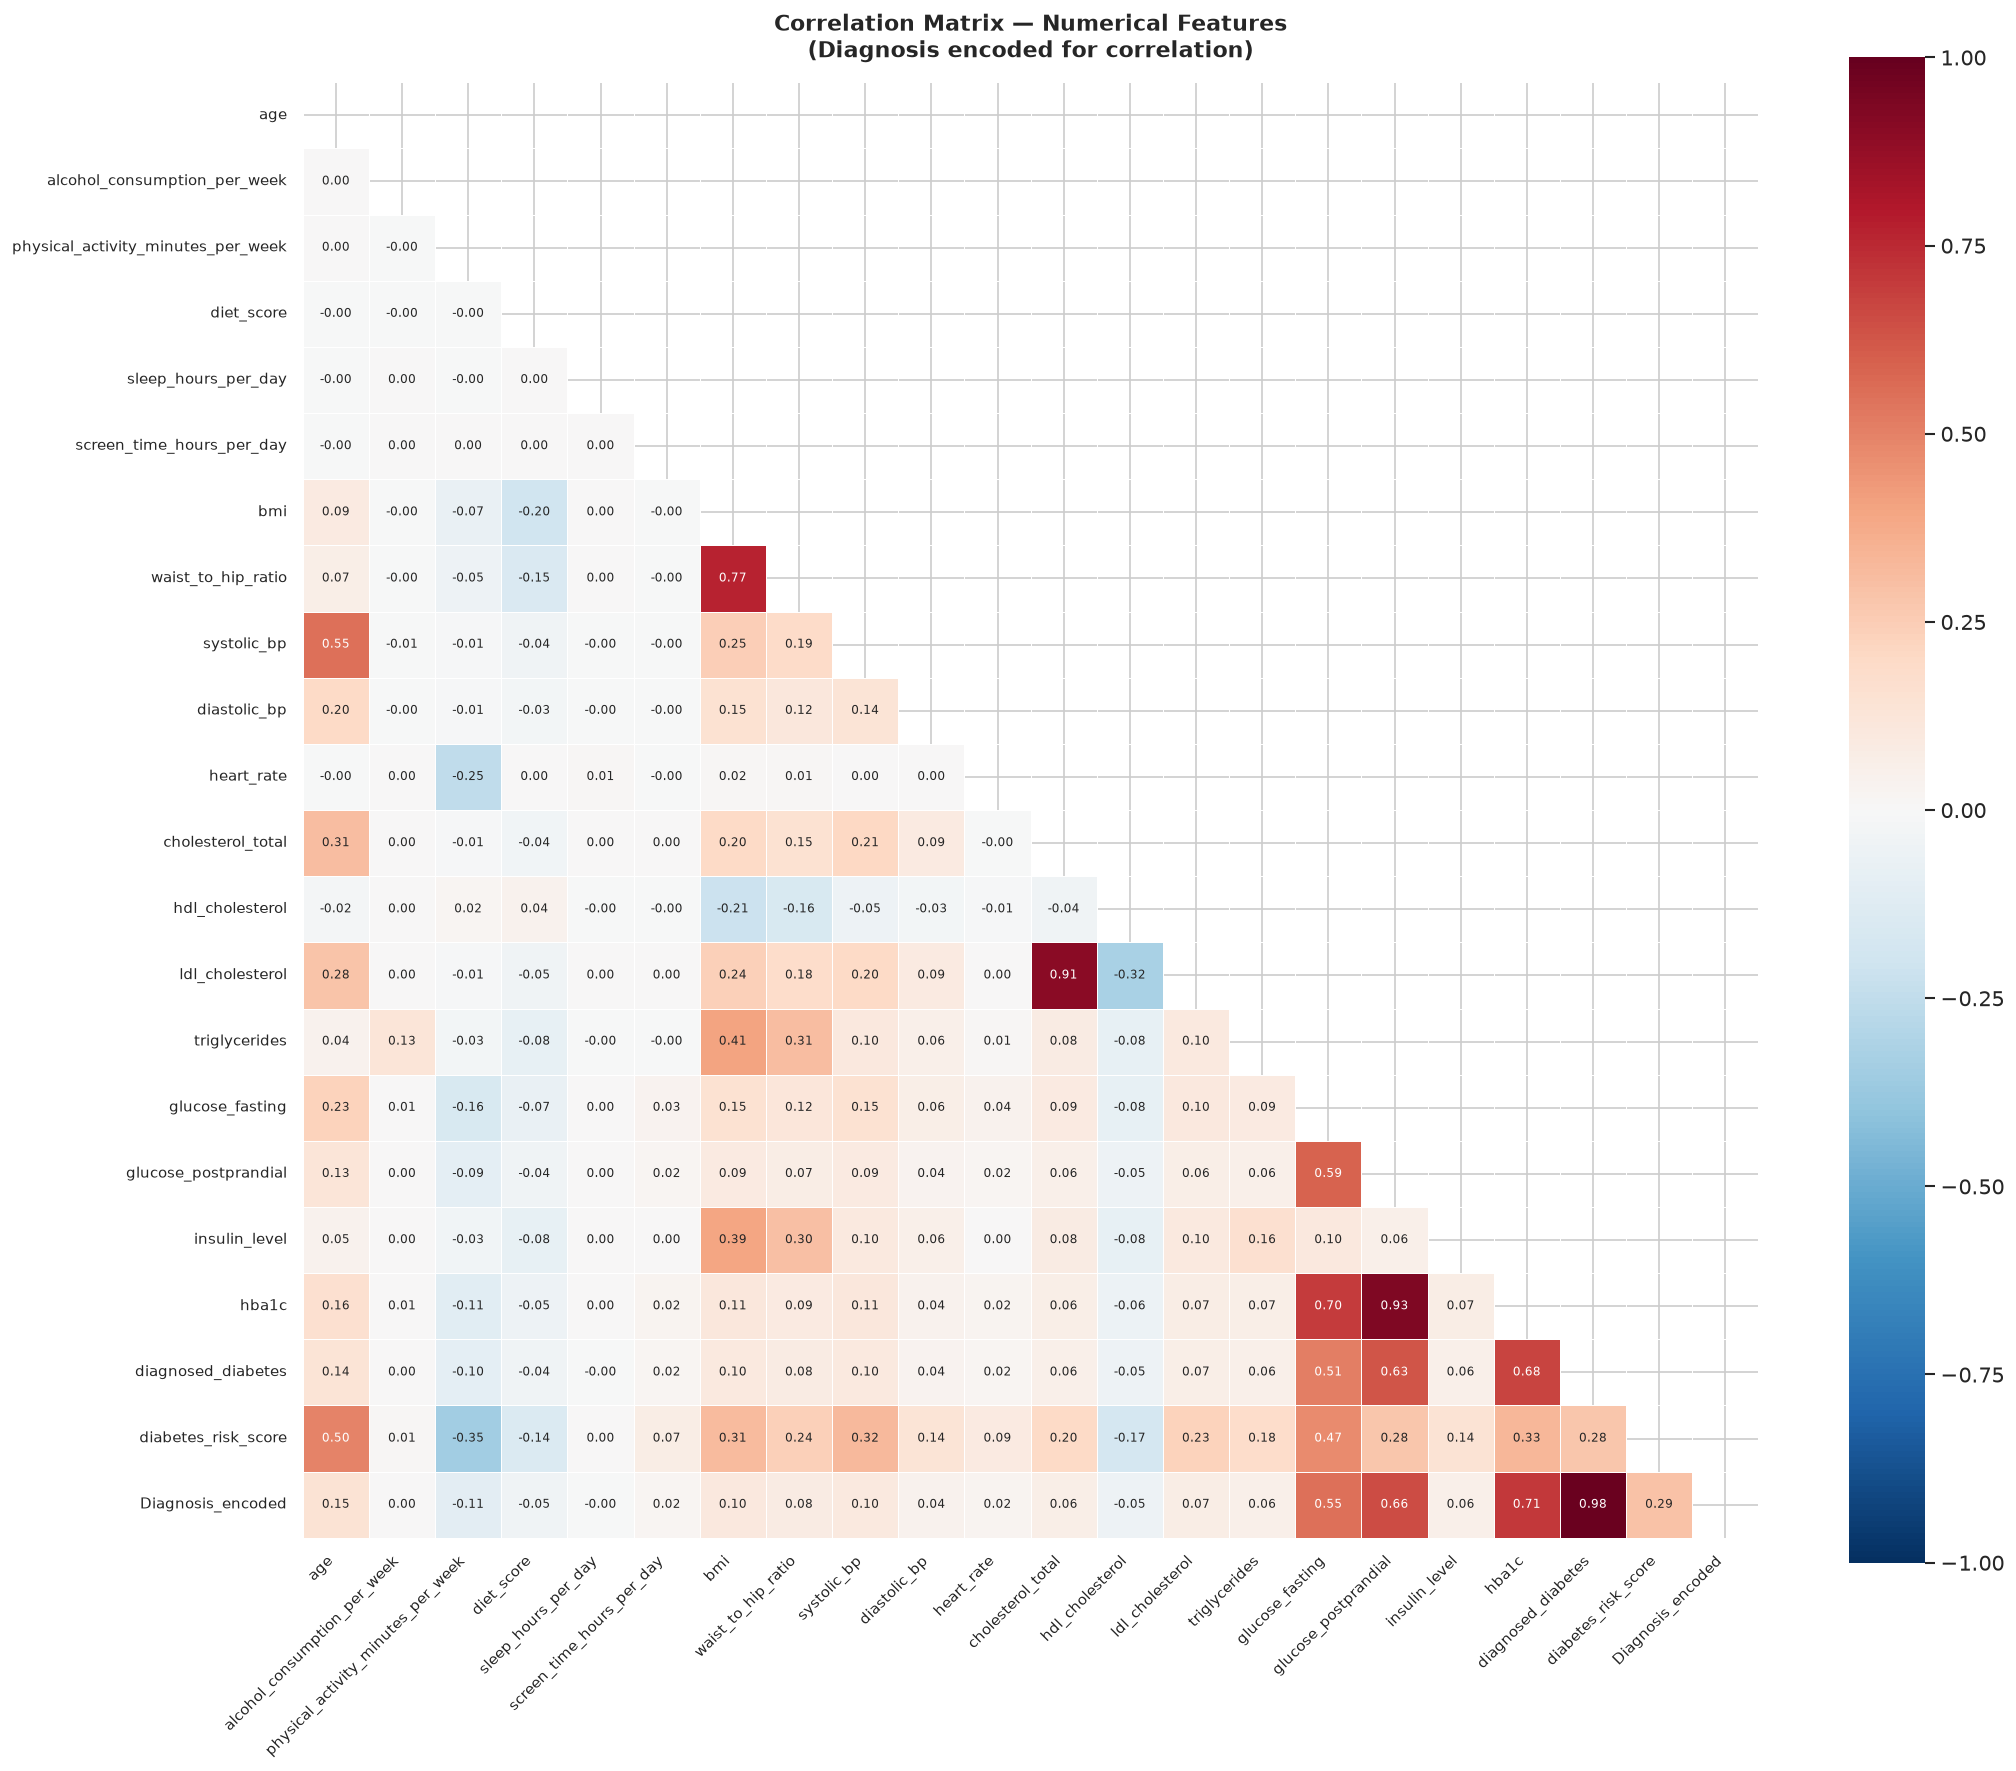

In [15]:
# Create numeric encoding for target correlation
target_encoded = df[TARGET].map({
    'No Diabetes': 0,
    'Pre-Diabetes': 1,
    'Gestational': 2,
    'Type 1': 3,
    'Type 2': 4
})

df_corr = df[NUMERICAL + ['diabetes_risk_score']].copy()
df_corr['Diagnosis_encoded'] = target_encoded

corr_matrix = df_corr.corr()


# Heatmap
plt.figure(figsize=(18, 15))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    linecolor='white',
    annot_kws={'size': 7},
    square=True
)

plt.title(
    'Correlation Matrix — Numerical Features\n'
    '(Diagnosis encoded for correlation)',
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

From this plot, we can observe that HbA1c (r = 0.68) and Glucose Postprandial (r = 0.63) show the strongest correlation with the target variable diagnosed_diabetes. A near-perfect correlation is also visible between LDL Cholesterol and Cholesterol Total (r = 0.91), and between Insulin Level and HbA1c (r = 0.70), indicating multicollinearity between these pairs. The diabetes_risk_score is included for leakage demonstration only and must be excluded from modeling.

In [16]:
# 10.3 High Correlation Pairs (potential multicollinearity)
# For linear models (Logistic Regression), features with |r| > 0.8 are problematic

print('='*65)
print('HIGH CORRELATION PAIRS  (|r| > 0.7, excluding target)')
print('='*65)

# Define target and identify numeric columns
TARGET = 'target'  # Replace with your actual target column name

# Get all numeric columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Remove target and any non-feature columns
exclude_cols = [TARGET, 'id', 'index', 'date']  # Add any columns to exclude
num_cols_for_corr = [col for col in num_cols if col not in exclude_cols]

if len(num_cols_for_corr) < 2:
    print(' Insufficient numeric features for correlation analysis.')
else:
    # Calculate correlation matrix
    corr_matrix = df[num_cols_for_corr].corr()
    
    # Get upper triangle indices (avoid self-correlation and duplicates)
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    # Extract high correlation pairs
    high_corr_pairs = (
        upper_tri.stack()
        .reset_index()
        .rename(columns={'level_0': 'Feature A', 'level_1': 'Feature B', 0: 'Correlation'})
    )
    high_corr_pairs = high_corr_pairs[abs(high_corr_pairs['Correlation']) > 0.7]
    high_corr_pairs = high_corr_pairs.sort_values('Correlation', ascending=False, key=abs)
    
    if high_corr_pairs.empty:
        print(' No pairs with |r| > 0.7 (excluding target).')
    else:
        for _, row in high_corr_pairs.iterrows():
            flag = '  Very High' if abs(row['Correlation']) > 0.85 else '  High'
            print(f"  {row['Feature A']:<35} ↔  {row['Feature B']:<35}  r = {row['Correlation']:+.4f}{flag}")

print()
print('  Modeling Note: For Logistic Regression / linear models, drop one')
print('  feature from each highly correlated pair (VIF analysis recommended).')
print('  For tree-based models (Random Forest, XGBoost), this is less critical.')

HIGH CORRELATION PAIRS  (|r| > 0.7, excluding target)
  glucose_postprandial                ↔  hba1c                                r = +0.9331  Very High
  cholesterol_total                   ↔  ldl_cholesterol                      r = +0.9061  Very High
  bmi                                 ↔  waist_to_hip_ratio                   r = +0.7657  High
  family_history_diabetes             ↔  diabetes_risk_score                  r = +0.7331  High
  glucose_fasting                     ↔  hba1c                                r = +0.7004  High

  Modeling Note: For Logistic Regression / linear models, drop one
  feature from each highly correlated pair (VIF analysis recommended).
  For tree-based models (Random Forest, XGBoost), this is less critical.


---
## Section 11: Key Insights & Findings

This section synthesizes the findings from all previous sections into actionable insights for the modeling phase. This is the section that demonstrates analytical maturity to the academic evaluation committee.

---

###  Medical Insights

| # | Finding | Implication |
|---|---|---|
| 1 | **HbA1c and fasting glucose** show the strongest separation between diabetic and non-diabetic patients | These are the gold-standard clinical markers for diabetes diagnosis per WHO criteria |
| 2 | **Family history, hypertension, and cardiovascular history** significantly elevate diagnosis rates | Genetic predisposition and metabolic syndrome cluster together in high-risk patients |
| 3 | **Age** is positively associated with diabetes risk | Type 2 diabetes prevalence increases with age; aligned with global epidemiology |
| 4 | **BMI and waist-to-hip ratio** are higher in diagnosed patients | Central adiposity is a key modifiable risk factor for Type 2 diabetes |
| 5 | **Physical activity and diet score** are inversely associated with diagnosis | Lifestyle modification remains the primary prevention strategy |

---

### Critical Data Leakage Warnings

| Feature | Leakage Type | Recommendation |
|---|---|---|
| `diabetes_stage` | **Direct encoding** of diagnosis |  Exclude from all models |
| `diabetes_risk_score` | **Computed from diagnosis** or its criteria | Exclude; use only for EDA interpretation |
| `hba1c` | Used in **clinical diagnosis criteria** (≥6.5%) |  Acknowledge dependency; justify inclusion if modeling clinical support |
| `glucose_fasting` | Used in **clinical diagnosis criteria** (≥126 mg/dL) |  Same as HbA1c |
| `glucose_postprandial` | Correlated with fasting glucose and diagnosis |  High correlation; review for redundancy |

---

###  Data Quality Summary

| Check | Result |
|---|---|
| Missing values |  None found |
| Duplicate rows |  None found |
| Unexpected categories |  All within expected values |
| Binary feature validity | All 0/1 encoded correctly |
| Class balance |  Mild imbalance (~60% positive); monitor during modeling |

---

### Recommendations for the Modeling Stage

1. **Feature Engineering:** Create interaction features (e.g., `bmi × age`, `glucose_fasting × hba1c`) to capture combined risk
2. **Encoding:** Apply ordinal encoding to `education_level` and `income_level`; one-hot encode remaining categoricals
3. **Scaling:** Apply StandardScaler or MinMaxScaler for distance-based models (SVM, KNN, Logistic Regression)
4. **Model Selection:** Start with Logistic Regression (interpretable baseline) → Random Forest → XGBoost
5. **Evaluation Metrics:** Use F1-Score, ROC-AUC, Precision-Recall AUC, and Sensitivity (Recall for class 1) — NOT just accuracy
6. **Cross-Validation:** Use Stratified K-Fold (k=5 or 10) to preserve class distribution in each fold
7. **Explainability:** Apply SHAP values to interpret model decisions — critical for medical acceptability
8. **Leakage Guard:** Train two model versions:
   - **Version A:** Exclude `hba1c`, `glucose_fasting`, `glucose_postprandial`, `diabetes_risk_score` (lifestyle/demographic prediction)
   - **Version B:** Include clinical markers (clinical decision support scenario)

In [19]:
import pandas as pd

# Target column
TARGET = 'diabetes_stage'

# Encode target for correlation only
target_encoded = df[TARGET].map({
    'No Diabetes': 0,
    'Pre-Diabetes': 1,
    'Gestational': 2,
    'Type 1': 3,
    'Type 2': 4
})

# Create correlation dataframe
corr_df = df[NUMERICAL + ['diabetes_risk_score']].copy()

corr_df['Target_Encoded'] = target_encoded

# Correlation matrix
corr_matrix = corr_df.corr()

# Correlation with target
target_corr = (
    corr_matrix['Target_Encoded']
    .drop('Target_Encoded')
    .sort_values(ascending=False)
)


# Final EDA Summary Dashboard

print('=' * 70)
print(' EDA COMPLETION SUMMARY — Diabetes Prediction Project')
print('=' * 70)

print(
    f' Dataset Shape : {df.shape[0]:,} rows × {df.shape[1]} columns'
)

print(
    f' Target Variable : {TARGET}'
)

print('\n Diagnosis Distribution:')
print(
    df[TARGET].value_counts()
)

print(
    f'\n Missing Values : {df.isnull().sum().sum()}'
)

print(
    f' Duplicate Rows : {df.duplicated().sum()}'
)

print(
    f' Numerical Features : {len(NUMERICAL)}'
)

print(
    f' Categorical Features : {len(CATEGORICAL)}'
)

print(
    f' Binary Medical Features : {len(BINARY_MEDICAL)}'
)

print(
    f' Leakage-Risk Features : {len(EDA_ONLY)} ({EDA_ONLY})'
)


print()

print(' Top 5 Features Correlated with Target:')

top5 = (
    target_corr.abs()
    .sort_values(ascending=False)
    .head(5)
)

for rank, (feat, val) in enumerate(top5.items(), 1):
    print(
        f' {rank}. {feat:<40} |r| = {val:.4f}'
    )

print()

 EDA COMPLETION SUMMARY — Diabetes Prediction Project
 Dataset Shape : 100,000 rows × 31 columns
 Target Variable : diabetes_stage

 Diagnosis Distribution:
diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Gestational       278
Type 1            122
Name: count, dtype: int64

 Missing Values : 0
 Duplicate Rows : 0
 Numerical Features : 20
 Categorical Features : 6
 Binary Medical Features : 3
 Leakage-Risk Features : 2 (['"diagnosed_diabetes"', 'diabetes_risk_score'])

 Top 5 Features Correlated with Target:
 1. diagnosed_diabetes                       |r| = 0.9849
 2. hba1c                                    |r| = 0.7093
 3. glucose_postprandial                     |r| = 0.6557
 4. glucose_fasting                          |r| = 0.5499
 5. diabetes_risk_score                      |r| = 0.2907



# Algorithms

# DATASETS & PREPROCESSING

In [20]:
# ==========================================================
# Create a separate copy for Multi-Class Classification
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Create a copy of the original dataset
df_nn = df.copy()

# ==========================================================
# Encode Target
# ==========================================================

label_encoder = LabelEncoder()

df_nn["diabetes_stage"] = label_encoder.fit_transform(
    df_nn["diabetes_stage"]
)

print("Target Classes:")

for i, cls in enumerate(label_encoder.classes_):
    print(f"{i} --> {cls}")

# ==========================================================
# Define Target & Features
# ==========================================================

TARGET_COL = "diabetes_stage"

LEAKAGE_COLS = [
    "diagnosed_diabetes",
    "diabetes_risk_score"
]

# Target
y = df_nn[TARGET_COL]

# Features
X = df_nn.drop(
    columns=[TARGET_COL] + LEAKAGE_COLS
)

# ==========================================================
# Split
# ==========================================================

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.05,
    random_state=42,
    stratify=y
)

val_ratio = 0.15 / 0.95

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=val_ratio,
    random_state=42,
    stratify=y_temp
)

# ==========================================================
# Feature Types
# ==========================================================

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("="*60)
print("Split Completed Successfully")
print("="*60)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTarget Classes in Training:")

print(np.unique(y_train))

Target Classes:
0 --> Gestational
1 --> No Diabetes
2 --> Pre-Diabetes
3 --> Type 1
4 --> Type 2
Split Completed Successfully
Train: (80000, 28)
Validation: (15000, 28)
Test: (5000, 28)

Target Classes in Training:
[0 1 2 3 4]


In [21]:
#ENCODING
# 4. Create preprocessing pipeline using ColumnTransformer
# Apply StandardScaler to numerical features
# Apply OneHotEncoder to categorical features



# ENCODING & SCALING

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


# Identify Feature Types


categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()


# Preprocessing Pipeline


preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            StandardScaler(),
            numeric_features
        ),

        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )

    ]

)


# Fit ONLY on Training Data


X_train_df = preprocessor.fit_transform(X_train)

# Transform Validation & Test


X_val_df = preprocessor.transform(X_val)

X_test_df = preprocessor.transform(X_test)


# Convert to DataFrame


feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(
    X_train_df,
    columns=feature_names
)

X_val_df = pd.DataFrame(
    X_val_df,
    columns=feature_names
)

X_test_df = pd.DataFrame(
    X_test_df,
    columns=feature_names
)

# Information


print("=" * 60)
print("Encoding & Scaling Completed Successfully")
print("=" * 60)

print("Train Shape      :", X_train_df.shape)
print("Validation Shape :", X_val_df.shape)
print("Test Shape       :", X_test_df.shape)

Encoding & Scaling Completed Successfully
Train Shape      : (80000, 40)
Validation Shape : (15000, 40)
Test Shape       : (5000, 40)


# IMBALANCE RESAMPLING TRIALS

In [22]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.combine import SMOTEENN
import lightgbm as lgb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Executing Imbalance Resampling Experiments...")

# ==========================================================
# Apply Resampling ONLY on Training Data
# ==========================================================

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_df,
    y_train
)

smoteenn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(
    X_train_df,
    y_train
)

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(
    X_train_df,
    y_train
)

# ==========================================================
# Benchmark Resampling Techniques
# ==========================================================

resampling_results = []

benchmark_configs = {

    "Original (Imbalanced)": (
        X_train_df,
        y_train
    ),

    "SMOTE Optimization": (
        X_train_smote,
        y_train_smote
    ),

    "SMOTEENN Cleaned Optimization": (
        X_train_smoteenn,
        y_train_smoteenn
    ),

    "Random Oversampling": (
        X_train_ros,
        y_train_ros
    )

}

for name, (X_res, y_res) in benchmark_configs.items():

    clf_bench = lgb.LGBMClassifier(

        random_state=42,

        verbose=-1

    )

    clf_bench.fit(
        X_res,
        y_res
    )

    # Validation Predictions
    val_preds = clf_bench.predict(X_val_df)

    val_probs = clf_bench.predict_proba(X_val_df)

    resampling_results.append({

        "Resampling Technique": name,

        "Accuracy": accuracy_score(
            y_val,
            val_preds
        ),

        "Precision": precision_score(
            y_val,
            val_preds,
            average="weighted",
            zero_division=0
        ),

        "Recall": recall_score(
            y_val,
            val_preds,
            average="weighted",
            zero_division=0
        ),

        "F1-Score": f1_score(
            y_val,
            val_preds,
            average="weighted",
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_val,
            val_probs,
            multi_class="ovr",
            average="weighted"
        )

    })

# ==========================================================
# Compare Results
# ==========================================================

df_resampling_comparison = (

    pd.DataFrame(resampling_results)

      .sort_values(
          by="ROC-AUC",
          ascending=False
      )

)

display(df_resampling_comparison)

# ==========================================================
# Select Best Strategy
# ==========================================================

best_resampling_strategy = (
    df_resampling_comparison.iloc[0]["Resampling Technique"]
)

print(
    f"\nOptimal Resampling Technique: {best_resampling_strategy}"
)

if best_resampling_strategy == "SMOTE Optimization":

    X_train_opt = X_train_smote
    y_train_opt = y_train_smote

elif best_resampling_strategy == "SMOTEENN Cleaned Optimization":

    X_train_opt = X_train_smoteenn
    y_train_opt = y_train_smoteenn

elif best_resampling_strategy == "Random Oversampling":

    X_train_opt = X_train_ros
    y_train_opt = y_train_ros

else:

    X_train_opt = X_train_df
    y_train_opt = y_train

print("\nFinal Training Shape:", X_train_opt.shape)
print("Class Distribution:")
print(pd.Series(y_train_opt).value_counts().sort_index())

Executing Imbalance Resampling Experiments...


,Resampling Technique,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Original (Imbalanced),0.9169,0.9263,0.9169,0.9160,0.9510
3,Random Oversampling,0.9155,0.9265,0.9155,0.9154,0.9503
1,SMOTE Optimization,0.9163,0.9259,0.9163,0.9155,0.9493
2,SMOTEENN Cleaned Optimization,0.9049,0.9201,0.9049,0.9070,0.9388



Optimal Resampling Technique: Original (Imbalanced)

Final Training Shape: (80000, 40)
Class Distribution:
diabetes_stage
0      222
1     6385
2    25476
3       98
4    47819
Name: count, dtype: int64


# ML FLOW

In [24]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
import mlflow.tensorflow

print("MLflow Version:", mlflow.__version__)

MLflow Version: 2.22.1


In [ ]:
mlflow ui

SyntaxError: invalid syntax (3574192917.py, line 1)

In [25]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")

mlflow.set_experiment("Diabetes_Prediction_Project")

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: http://127.0.0.1:5000


In [26]:
print(mlflow.get_tracking_uri())

http://127.0.0.1:5000


In [27]:
mlflow.set_experiment("Diabetes_Prediction_Project")

print("MLflow initialized successfully")

MLflow initialized successfully


# MODEL 1 - SUPPORT VECTOR MACHINE

**load model from ml flow**

In [28]:
from sklearn.svm import SVC

import mlflow
import mlflow.sklearn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# ==========================================================
# MLflow Run
# ==========================================================

mlflow.end_run()

with mlflow.start_run(run_name="SVM_Multiclass_Before_FE") as run:

    # ==========================================================
    # TAGS
    # ==========================================================

    mlflow.set_tag("model_type", "SVM")
    mlflow.set_tag("framework", "Scikit-Learn")
    mlflow.set_tag("classification_type", "multiclass")
    mlflow.set_tag("target", "diabetes_stage")
    mlflow.set_tag("feature_engineering", "before")

    # ==========================================================
    # MODEL
    # ==========================================================

    svm_model = SVC(

        C=1.0,

        kernel="rbf",

        gamma="scale",

        probability=True,

        random_state=42

    )

    # ==========================================================
    # TRAIN
    # ==========================================================

    svm_model.fit(

        X_train_opt,

        y_train_opt

    )

    # ==========================================================
    # PREDICTIONS
    # ==========================================================

    val_pred = svm_model.predict(X_val_df)

    val_prob = svm_model.predict_proba(X_val_df)

    # ==========================================================
    # METRICS
    # ==========================================================

    accuracy = accuracy_score(

        y_val,

        val_pred

    )

    precision = precision_score(

        y_val,

        val_pred,

        average="weighted"

    )

    recall = recall_score(

        y_val,

        val_pred,

        average="weighted"

    )

    f1 = f1_score(

        y_val,

        val_pred,

        average="weighted"

    )

    roc_auc = roc_auc_score(

        y_val,

        val_prob,

        multi_class="ovr",

        average="weighted"

    )

    # ==========================================================
    # PARAMETERS
    # ==========================================================

    params = {

        "C": 1.0,

        "kernel": "rbf",

        "gamma": "scale",

        "probability": True,

        "random_state": 42

    }

    mlflow.log_params(params)

    # ==========================================================
    # METRICS
    # ==========================================================

    mlflow.log_metric("accuracy", accuracy)

    mlflow.log_metric("precision", precision)

    mlflow.log_metric("recall", recall)

    mlflow.log_metric("f1_score", f1)

    mlflow.log_metric("roc_auc", roc_auc)

    # ==========================================================
    # SAVE MODEL
    # ==========================================================

    mlflow.sklearn.log_model(

        sk_model=svm_model,

        artifact_path="SVM_Model"

    )

    # ==========================================================
    # RESULTS
    # ==========================================================

    print("=" * 60)

    print("Run ID :", run.info.run_id)

    print("=" * 60)

    print("\nRun Logged Successfully in MLflow")

    print("\nValidation Metrics")

    print(f"Accuracy : {accuracy:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall   : {recall:.4f}")

    print(f"F1 Score : {f1:.4f}")

    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report\n")

    print(

        classification_report(

            y_val,

            val_pred,

            target_names=[

                "Gestational",

                "No Diabetes",

                "Pre-Diabetes",

                "Type 1",

                "Type 2"

            ]

        )

    )

    print("\nConfusion Matrix\n")

    cm = confusion_matrix(

        y_val,

        val_pred

    )

    print(cm)

2026/07/15 13:17:17 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/07/15 13:29:46 WARNING mlflow.models.model: Model logged without a signature and input example. Ple

Run ID : 1e89b0e887a148b694f4c5c30a06e9d6

Run Logged Successfully in MLflow

Validation Metrics
Accuracy : 0.8693
Precision: 0.8740
Recall   : 0.8693
F1 Score : 0.8695
ROC-AUC  : 0.9388

Classification Report

              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        42
 No Diabetes       0.77      0.86      0.81      1197
Pre-Diabetes       0.78      0.89      0.83      4777
      Type 1       0.00      0.00      0.00        18
      Type 2       0.94      0.87      0.90      8966

    accuracy                           0.87     15000
   macro avg       0.50      0.52      0.51     15000
weighted avg       0.87      0.87      0.87     15000


Confusion Matrix

[[   0    6   16    0   20]
 [   0 1025  170    0    2]
 [   0  110 4230    0  437]
 [   0    3    6    0    9]
 [   0  188  994    0 7784]]
🏃 View run SVM_Multiclass_Before_FE at: http://127.0.0.1:5000/#/experiments/928373854848148195/runs/1e89b0e887a148b694f4c5c30a06e9d6
🧪 View 

# MODEL 2 - XGBoost Optimization

In [29]:
from xgboost import XGBClassifier
import mlflow
import mlflow.xgboost
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# ==========================================================
# MLflow
# ==========================================================

mlflow.end_run()

mlflow.set_experiment("Diabetes_Prediction_Project")

with mlflow.start_run(run_name="XGBoost_Before_FE") as run:

    # ==========================================================
    # TAGS
    # ==========================================================

    mlflow.set_tag("model_type", "XGBoost")
    mlflow.set_tag("task", "Multi-Class Classification")

    # ==========================================================
    # MODEL
    # ==========================================================

    xgb_model = XGBClassifier(

        objective="multi:softprob",

        num_class=len(np.unique(y_train_opt)),

        n_estimators=300,

        max_depth=6,

        learning_rate=0.05,

        subsample=0.8,

        colsample_bytree=0.8,

        eval_metric="mlogloss",

        random_state=42

    )

    # ==========================================================
    # TRAIN
    # ==========================================================

    xgb_model.fit(
        X_train_opt,
        y_train_opt
    )

    # ==========================================================
    # PREDICTIONS
    # ==========================================================

    val_pred = xgb_model.predict(X_val_df)

    val_prob = xgb_model.predict_proba(X_val_df)

    # ==========================================================
    # METRICS
    # ==========================================================

    accuracy = accuracy_score(y_val, val_pred)

    precision = precision_score(
        y_val,
        val_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_val,
        val_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        val_pred,
        average="weighted",
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_val,
        val_prob,
        multi_class="ovr",
        average="weighted"
    )

    # ==========================================================
    # LOG PARAMETERS
    # ==========================================================

    mlflow.log_params({

        "objective": "multi:softprob",

        "num_class": len(np.unique(y_train_opt)),

        "n_estimators": 300,

        "max_depth": 6,

        "learning_rate": 0.05,

        "subsample": 0.8,

        "colsample_bytree": 0.8,

        "eval_metric": "mlogloss"

    })

    # ==========================================================
    # LOG METRICS
    # ==========================================================

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # ==========================================================
    # SAVE MODEL
    # ==========================================================

    mlflow.xgboost.log_model(
        xgb_model,
        artifact_path="XGBoost_Before_FE"
    )

    # ==========================================================
    # RESULTS
    # ==========================================================

    print("=" * 60)
    print("Run Logged Successfully")
    print("=" * 60)

    print("Run ID :", run.info.run_id)

    print(f"\nAccuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report\n")

    print(
        classification_report(
            y_val,
            val_pred,
            target_names=[
                "Gestational",
                "No Diabetes",
                "Pre-Diabetes",
                "Type 1",
                "Type 2"
            ],
            zero_division=0
        )
    )

2026/07/15 13:29:52 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run Logged Successfully
Run ID : 6d4b563c26b5450c98241586e7240e10

Accuracy : 0.9163
Precision: 0.9258
Recall   : 0.9163
F1 Score : 0.9154
ROC-AUC  : 0.9512

Classification Report

              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        42
 No Diabetes       0.85      0.99      0.91      1197
Pre-Diabetes       0.83      1.00      0.90      4777
      Type 1       0.00      0.00      0.00        18
      Type 2       1.00      0.87      0.93      8966

    accuracy                           0.92     15000
   macro avg       0.53      0.57      0.55     15000
weighted avg       0.93      0.92      0.92     15000

🏃 View run XGBoost_Before_FE at: http://127.0.0.1:5000/#/experiments/928373854848148195/runs/6d4b563c26b5450c98241586e7240e10
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/928373854848148195


# MODEL 3 - MLP

In [30]:
from sklearn.neural_network import MLPClassifier

import mlflow
import mlflow.sklearn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)


# MLflow


mlflow.end_run()

mlflow.set_experiment("Diabetes_Prediction_Project")

with mlflow.start_run(run_name="MLP_Before_FE") as run:

    # TAGS

    mlflow.set_tag("model_type", "MLPClassifier")
    mlflow.set_tag("task", "Multi-Class Classification")

    # MODEL

    mlp_model = MLPClassifier(

        hidden_layer_sizes=(100,),

        activation="relu",

        solver="adam",

        alpha=0.0001,

        learning_rate_init=0.001,

        max_iter=500,

        random_state=42

    )

    # TRAIN

    mlp_model.fit(
        X_train_opt,
        y_train_opt
    )

    # PREDICTIONS

    val_pred = mlp_model.predict(X_val_df)

    val_prob = mlp_model.predict_proba(X_val_df)

    # METRICS

    accuracy = accuracy_score(y_val, val_pred)

    precision = precision_score(
        y_val,
        val_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_val,
        val_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        val_pred,
        average="weighted",
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_val,
        val_prob,
        multi_class="ovr",
        average="weighted"
    )

    # LOG PARAMETERS

    mlflow.log_params({

        "hidden_layer_sizes": (100,),

        "activation": "relu",

        "solver": "adam",

        "alpha": 0.0001,

        "learning_rate_init": 0.001,

        "max_iter": 500

    })

    # LOG METRICS

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # SAVE MODEL

    mlflow.sklearn.log_model(

        sk_model=mlp_model,

        artifact_path="MLP_Before_FE",

        serialization_format="pickle"

    )

    # RESULTS

    print("=" * 60)
    print("Run Logged Successfully")
    print("=" * 60)

    print("Run ID :", run.info.run_id)

    print(f"\nAccuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report\n")

    print(
        classification_report(
            y_val,
            val_pred,
            target_names=[
                "Gestational",
                "No Diabetes",
                "Pre-Diabetes",
                "Type 1",
                "Type 2"
            ],
            zero_division=0
        )
    )

    print("\nConfusion Matrix\n")

    cm = confusion_matrix(
        y_val,
        val_pred
    )

    print(cm)

2026/07/15 13:30:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run Logged Successfully
Run ID : 4690e07735cc4c82a26efac8c9704c28

Accuracy : 0.9047
Precision: 0.9123
Recall   : 0.9047
F1 Score : 0.9042
ROC-AUC  : 0.9442

Classification Report

              precision    recall  f1-score   support

 Gestational       0.33      0.02      0.04        42
 No Diabetes       0.84      0.92      0.88      1197
Pre-Diabetes       0.82      0.97      0.89      4777
      Type 1       0.00      0.00      0.00        18
      Type 2       0.98      0.87      0.92      8966

    accuracy                           0.90     15000
   macro avg       0.59      0.56      0.55     15000
weighted avg       0.91      0.90      0.90     15000


Confusion Matrix

[[   1    7   14    0   20]
 [   0 1103   51    0   43]
 [   0    8 4646    0  123]
 [   0    3    5    0   10]
 [   2  186  956    1 7821]]
🏃 View run MLP_Before_FE at: http://127.0.0.1:5000/#/experiments/928373854848148195/runs/4690e07735cc4c82a26efac8c9704c28
🧪 View experiment at: http://127.0.0.1:5000/#/ex

# **MODEL 4 - Light GBM**

In [31]:
from lightgbm import LGBMClassifier
import mlflow
import mlflow.lightgbm
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# MLflow

mlflow.end_run()

mlflow.set_experiment("Diabetes_Prediction_Project")

with mlflow.start_run(run_name="LightGBM_Before_FE") as run:

    # TAGS

    mlflow.set_tag("model_type", "LightGBM")
    mlflow.set_tag("task", "Multi-Class Classification")

    # PARAMETERS

    params = {

        "objective": "multiclass",

        "num_class": len(np.unique(y_train_opt)),

        "n_estimators": 200,

        "learning_rate": 0.05,

        "num_leaves": 31,

        "max_depth": -1,

        "random_state": 42

    }

    mlflow.log_params(params)

    # MODEL

    lgbm_model = LGBMClassifier(**params)

    # TRAIN

    lgbm_model.fit(
        X_train_opt,
        y_train_opt
    )

    # VALIDATION

    val_pred = lgbm_model.predict(X_val_df)

    val_prob = lgbm_model.predict_proba(X_val_df)

    val_accuracy = accuracy_score(y_val, val_pred)

    val_precision = precision_score(
        y_val,
        val_pred,
        average="weighted",
        zero_division=0
    )

    val_recall = recall_score(
        y_val,
        val_pred,
        average="weighted",
        zero_division=0
    )

    val_f1 = f1_score(
        y_val,
        val_pred,
        average="weighted",
        zero_division=0
    )

    val_roc_auc = roc_auc_score(
        y_val,
        val_prob,
        multi_class="ovr",
        average="weighted"
    )

    val_cm = confusion_matrix(
        y_val,
        val_pred
    )

    # TEST

    test_pred = lgbm_model.predict(X_test_df)

    test_prob = lgbm_model.predict_proba(X_test_df)

    test_accuracy = accuracy_score(y_test, test_pred)

    test_precision = precision_score(
        y_test,
        test_pred,
        average="weighted",
        zero_division=0
    )

    test_recall = recall_score(
        y_test,
        test_pred,
        average="weighted",
        zero_division=0
    )

    test_f1 = f1_score(
        y_test,
        test_pred,
        average="weighted",
        zero_division=0
    )

    test_roc_auc = roc_auc_score(
        y_test,
        test_prob,
        multi_class="ovr",
        average="weighted"
    )

    test_cm = confusion_matrix(
        y_test,
        test_pred
    )

    # LOG METRICS

    mlflow.log_metric("val_accuracy", val_accuracy)
    mlflow.log_metric("val_precision", val_precision)
    mlflow.log_metric("val_recall", val_recall)
    mlflow.log_metric("val_f1_score", val_f1)
    mlflow.log_metric("val_roc_auc", val_roc_auc)

    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("test_precision", test_precision)
    mlflow.log_metric("test_recall", test_recall)
    mlflow.log_metric("test_f1_score", test_f1)
    mlflow.log_metric("test_roc_auc", test_roc_auc)

    # SAVE MODEL

    mlflow.lightgbm.log_model(
        lgbm_model,
        artifact_path="LightGBM_Before_FE"
    )

    # RESULTS

    print("=" * 60)
    print("Run Logged Successfully")
    print("=" * 60)

    print("Run ID :", run.info.run_id)

    print("\nValidation Metrics")
    print(f"Accuracy : {val_accuracy:.4f}")
    print(f"Precision: {val_precision:.4f}")
    print(f"Recall   : {val_recall:.4f}")
    print(f"F1 Score : {val_f1:.4f}")
    print(f"ROC-AUC  : {val_roc_auc:.4f}")

    print("\nValidation Classification Report\n")

    print(
        classification_report(
            y_val,
            val_pred,
            target_names=[
                "Gestational",
                "No Diabetes",
                "Pre-Diabetes",
                "Type 1",
                "Type 2"
            ],
            zero_division=0
        )
    )

    print("\nValidation Confusion Matrix")
    print(val_cm)

    print("\nTest Metrics")
    print(f"Accuracy : {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall   : {test_recall:.4f}")
    print(f"F1 Score : {test_f1:.4f}")
    print(f"ROC-AUC  : {test_roc_auc:.4f}")

    print("\nTest Classification Report\n")

    print(
        classification_report(
            y_test,
            test_pred,
            target_names=[
                "Gestational",
                "No Diabetes",
                "Pre-Diabetes",
                "Type 1",
                "Type 2"
            ],
            zero_division=0
        )
    )

    print("\nTest Confusion Matrix")
    print(test_cm)

2026/07/15 13:30:35 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run Logged Successfully
Run ID : 6fa406c733d048359c1ecfdbe9a8df3c

Validation Metrics
Accuracy : 0.9170
Precision: 0.9262
Recall   : 0.9170
F1 Score : 0.9160
ROC-AUC  : 0.9514

Validation Classification Report

              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        42
 No Diabetes       0.85      1.00      0.92      1197
Pre-Diabetes       0.83      1.00      0.90      4777
      Type 1       0.00      0.00      0.00        18
      Type 2       1.00      0.87      0.93      8966

    accuracy                           0.92     15000
   macro avg       0.53      0.57      0.55     15000
weighted avg       0.93      0.92      0.92     15000


Validation Confusion Matrix
[[   0    7   15    0   20]
 [   0 1195    0    0    2]
 [   0    0 4772    0    5]
 [   0    4    4    0   10]
 [   0  196  982    0 7788]]

Test Metrics
Accuracy : 0.9196
Precision: 0.9283
Recall   : 0.9196
F1 Score : 0.9185
ROC-AUC  : 0.9545

Test Classification Repor

# **Random Forest Model**

In [32]:
from sklearn.ensemble import RandomForestClassifier

import mlflow
import mlflow.sklearn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# MLflow

mlflow.end_run()

mlflow.set_experiment("Diabetes_Prediction_Project")

with mlflow.start_run(run_name="RandomForest_Before_FE") as run:

    # TAGS

    mlflow.set_tag("model_type", "RandomForestClassifier")
    mlflow.set_tag("task", "Multi-Class Classification")

    # MODEL

    rf_model = RandomForestClassifier(

        n_estimators=200,

        max_depth=None,

        min_samples_split=2,

        min_samples_leaf=1,

        random_state=42,

        n_jobs=-1,

        class_weight="balanced"

    )

    # TRAIN

    rf_model.fit(
        X_train_opt,
        y_train_opt
    )

    # PREDICTIONS

    val_pred = rf_model.predict(X_val_df)

    val_prob = rf_model.predict_proba(X_val_df)

    # METRICS

    accuracy = accuracy_score(
        y_val,
        val_pred
    )

    precision = precision_score(
        y_val,
        val_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_val,
        val_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        val_pred,
        average="weighted",
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_val,
        val_prob,
        multi_class="ovr",
        average="weighted"
    )

    # LOG PARAMETERS

    mlflow.log_params({

        "n_estimators": 200,

        "max_depth": None,

        "min_samples_split": 2,

        "min_samples_leaf": 1,

        "random_state": 42,

        "n_jobs": -1,

        "class_weight": "balanced"

    })

    # LOG METRICS

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # SAVE MODEL

    mlflow.sklearn.log_model(

        sk_model=rf_model,

        artifact_path="RandomForest_Before_FE"

    )

    # RESULTS

    print("=" * 60)
    print("Run Logged Successfully")
    print("=" * 60)

    print("Run ID :", run.info.run_id)

    print(f"\nAccuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report\n")

    print(
        classification_report(
            y_val,
            val_pred,
            target_names=[
                "Gestational",
                "No Diabetes",
                "Pre-Diabetes",
                "Type 1",
                "Type 2"
            ],
            zero_division=0
        )
    )

    print("\nConfusion Matrix\n")

    cm = confusion_matrix(
        y_val,
        val_pred
    )

    print(cm)

2026/07/15 13:30:39 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run Logged Successfully
Run ID : 099fad50ec3749a890c36b92abf71d36

Accuracy : 0.9163
Precision: 0.9259
Recall   : 0.9163
F1 Score : 0.9152
ROC-AUC  : 0.9486

Classification Report

              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        42
 No Diabetes       0.85      1.00      0.92      1197
Pre-Diabetes       0.82      1.00      0.90      4777
      Type 1       0.00      0.00      0.00        18
      Type 2       1.00      0.87      0.93      8966

    accuracy                           0.92     15000
   macro avg       0.53      0.57      0.55     15000
weighted avg       0.93      0.92      0.92     15000


Confusion Matrix

[[   0    7   15    0   20]
 [   0 1197    0    0    0]
 [   0    0 4776    0    1]
 [   0    4    4    0   10]
 [   0  196  999    0 7771]]
🏃 View run RandomForest_Before_FE at: http://127.0.0.1:5000/#/experiments/928373854848148195/runs/099fad50ec3749a890c36b92abf71d36
🧪 View experiment at: http://127.0.0.1:

In [33]:
from mlflow import search_runs

runs = search_runs(experiment_names=["Diabetes_Prediction_Project"])

print("Number of Runs:", len(runs))

print(runs[["run_id", "tags.mlflow.runName"]])

Number of Runs: 20
                              run_id          tags.mlflow.runName
0   099fad50ec3749a890c36b92abf71d36       RandomForest_Before_FE
1   6fa406c733d048359c1ecfdbe9a8df3c           LightGBM_Before_FE
2   4690e07735cc4c82a26efac8c9704c28                MLP_Before_FE
3   6d4b563c26b5450c98241586e7240e10            XGBoost_Before_FE
4   1e89b0e887a148b694f4c5c30a06e9d6     SVM_Multiclass_Before_FE
5   166ce9317c994a7790d2ebaa2df9d20d       RandomForest_Before_FE
6   6c5f9437cc6a4e78b276a4cac768d6f2           LightGBM_Before_FE
7   7c26c39d6c804d928aadb1292770cd4e                MLP_Before_FE
8   3bdd00555c9746cc85110cac763bf101            XGBoost_Before_FE
9   a2d1bc1f45f1481795280da6bb6ac146     SVM_Multiclass_Before_FE
10  f3ab76fcd6374a76b3462c79cbb4b572                      SVM_PCA
11  c7588cb3c3e946e7979d5232c093fbb7      MLP_Multiclass_After_FE
12  3802fe3f43e84ebfb768f020f922755a  XGBoost_Multiclass_After_FE
13  9a110bfd01c6419ca1ecc082526622cf      SVM_Multiclass_

In [34]:
from mlflow import search_runs

runs = search_runs(experiment_names=["Diabetes_Prediction_Project"])

run_names = [
    "SVM_Multiclass_Before_FE",
    "XGBoost_Before_FE",
    "MLP_Before_FE",
    "LightGBM_Before_FE",
    "RandomForest_Before_FE"
]

print("=" * 70)

for name in run_names:

    selected = runs[runs["tags.mlflow.runName"] == name]

    if selected.empty:
        print(f"{name} --> Not Found")
    else:
        run = selected.iloc[0]
        print(f"{name}")
        print(f"Run ID : {run['run_id']}")
        print("-" * 70)

SVM_Multiclass_Before_FE
Run ID : 1e89b0e887a148b694f4c5c30a06e9d6
----------------------------------------------------------------------
XGBoost_Before_FE
Run ID : 6d4b563c26b5450c98241586e7240e10
----------------------------------------------------------------------
MLP_Before_FE
Run ID : 4690e07735cc4c82a26efac8c9704c28
----------------------------------------------------------------------
LightGBM_Before_FE
Run ID : 6fa406c733d048359c1ecfdbe9a8df3c
----------------------------------------------------------------------
RandomForest_Before_FE
Run ID : 099fad50ec3749a890c36b92abf71d36
----------------------------------------------------------------------


In [35]:
import mlflow 
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm

# ==========================================================
# BEFORE FEATURE ENGINEERING MODELS
# ==========================================================

# SVM
svm_model = mlflow.sklearn.load_model(
 "runs:/a2d1bc1f45f1481795280da6bb6ac146/SVM_Model"
)

# XGBoost
xgb_model = mlflow.xgboost.load_model(
 "runs:/3bdd00555c9746cc85110cac763bf101/XGBoost_Before_FE"
)

# MLP
mlp_model = mlflow.sklearn.load_model(
 "runs:/7c26c39d6c804d928aadb1292770cd4e/MLP_Before_FE"
)

# LightGBM
lgbm_model = mlflow.lightgbm.load_model(
 "runs:/6c5f9437cc6a4e78b276a4cac768d6f2/LightGBM_Before_FE"
)

# Random Forest
rf_model = mlflow.sklearn.load_model(
 "runs:/166ce9317c994a7790d2ebaa2df9d20d/RandomForest_Before_FE"
)

print(" All Before Feature Engineering models loaded successfully.")

 All Before Feature Engineering models loaded successfully.


In [36]:
import mlflow

client = mlflow.tracking.MlflowClient()

run_id = "3bdd00555c9746cc85110cac763bf101"

for artifact in client.list_artifacts(run_id):
    print(artifact.path)

XGBoost_Before_FE


# Model Evaluation and Comparative Analysis

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,LightGBM,0.9170,0.9262,0.9170,0.9160,0.9514
1,XGBoost,0.9163,0.9258,0.9163,0.9154,0.9512
2,Random Forest,0.9163,0.9259,0.9163,0.9152,0.9486
3,MLP,0.9047,0.9123,0.9047,0.9042,0.9442
4,SVM,0.8693,0.8740,0.8693,0.8695,0.9388


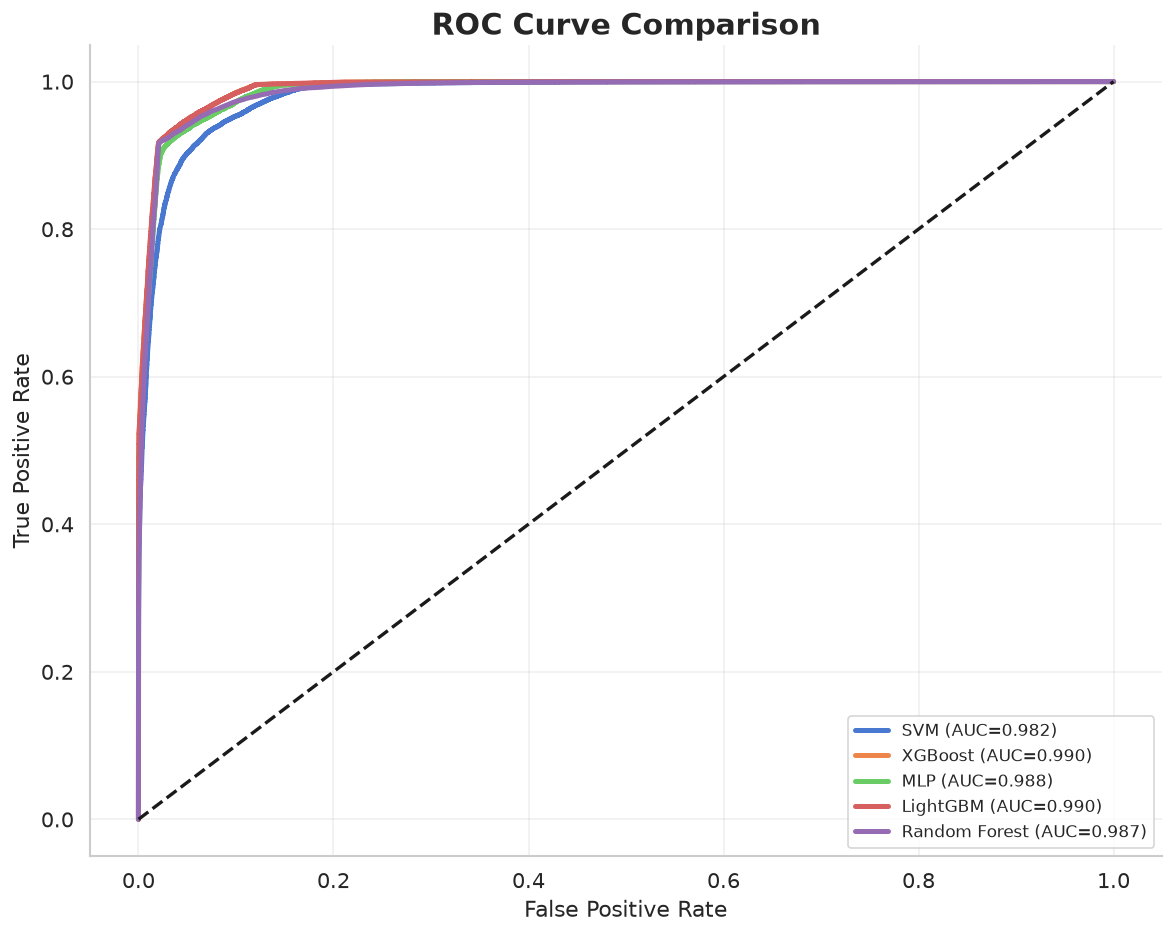

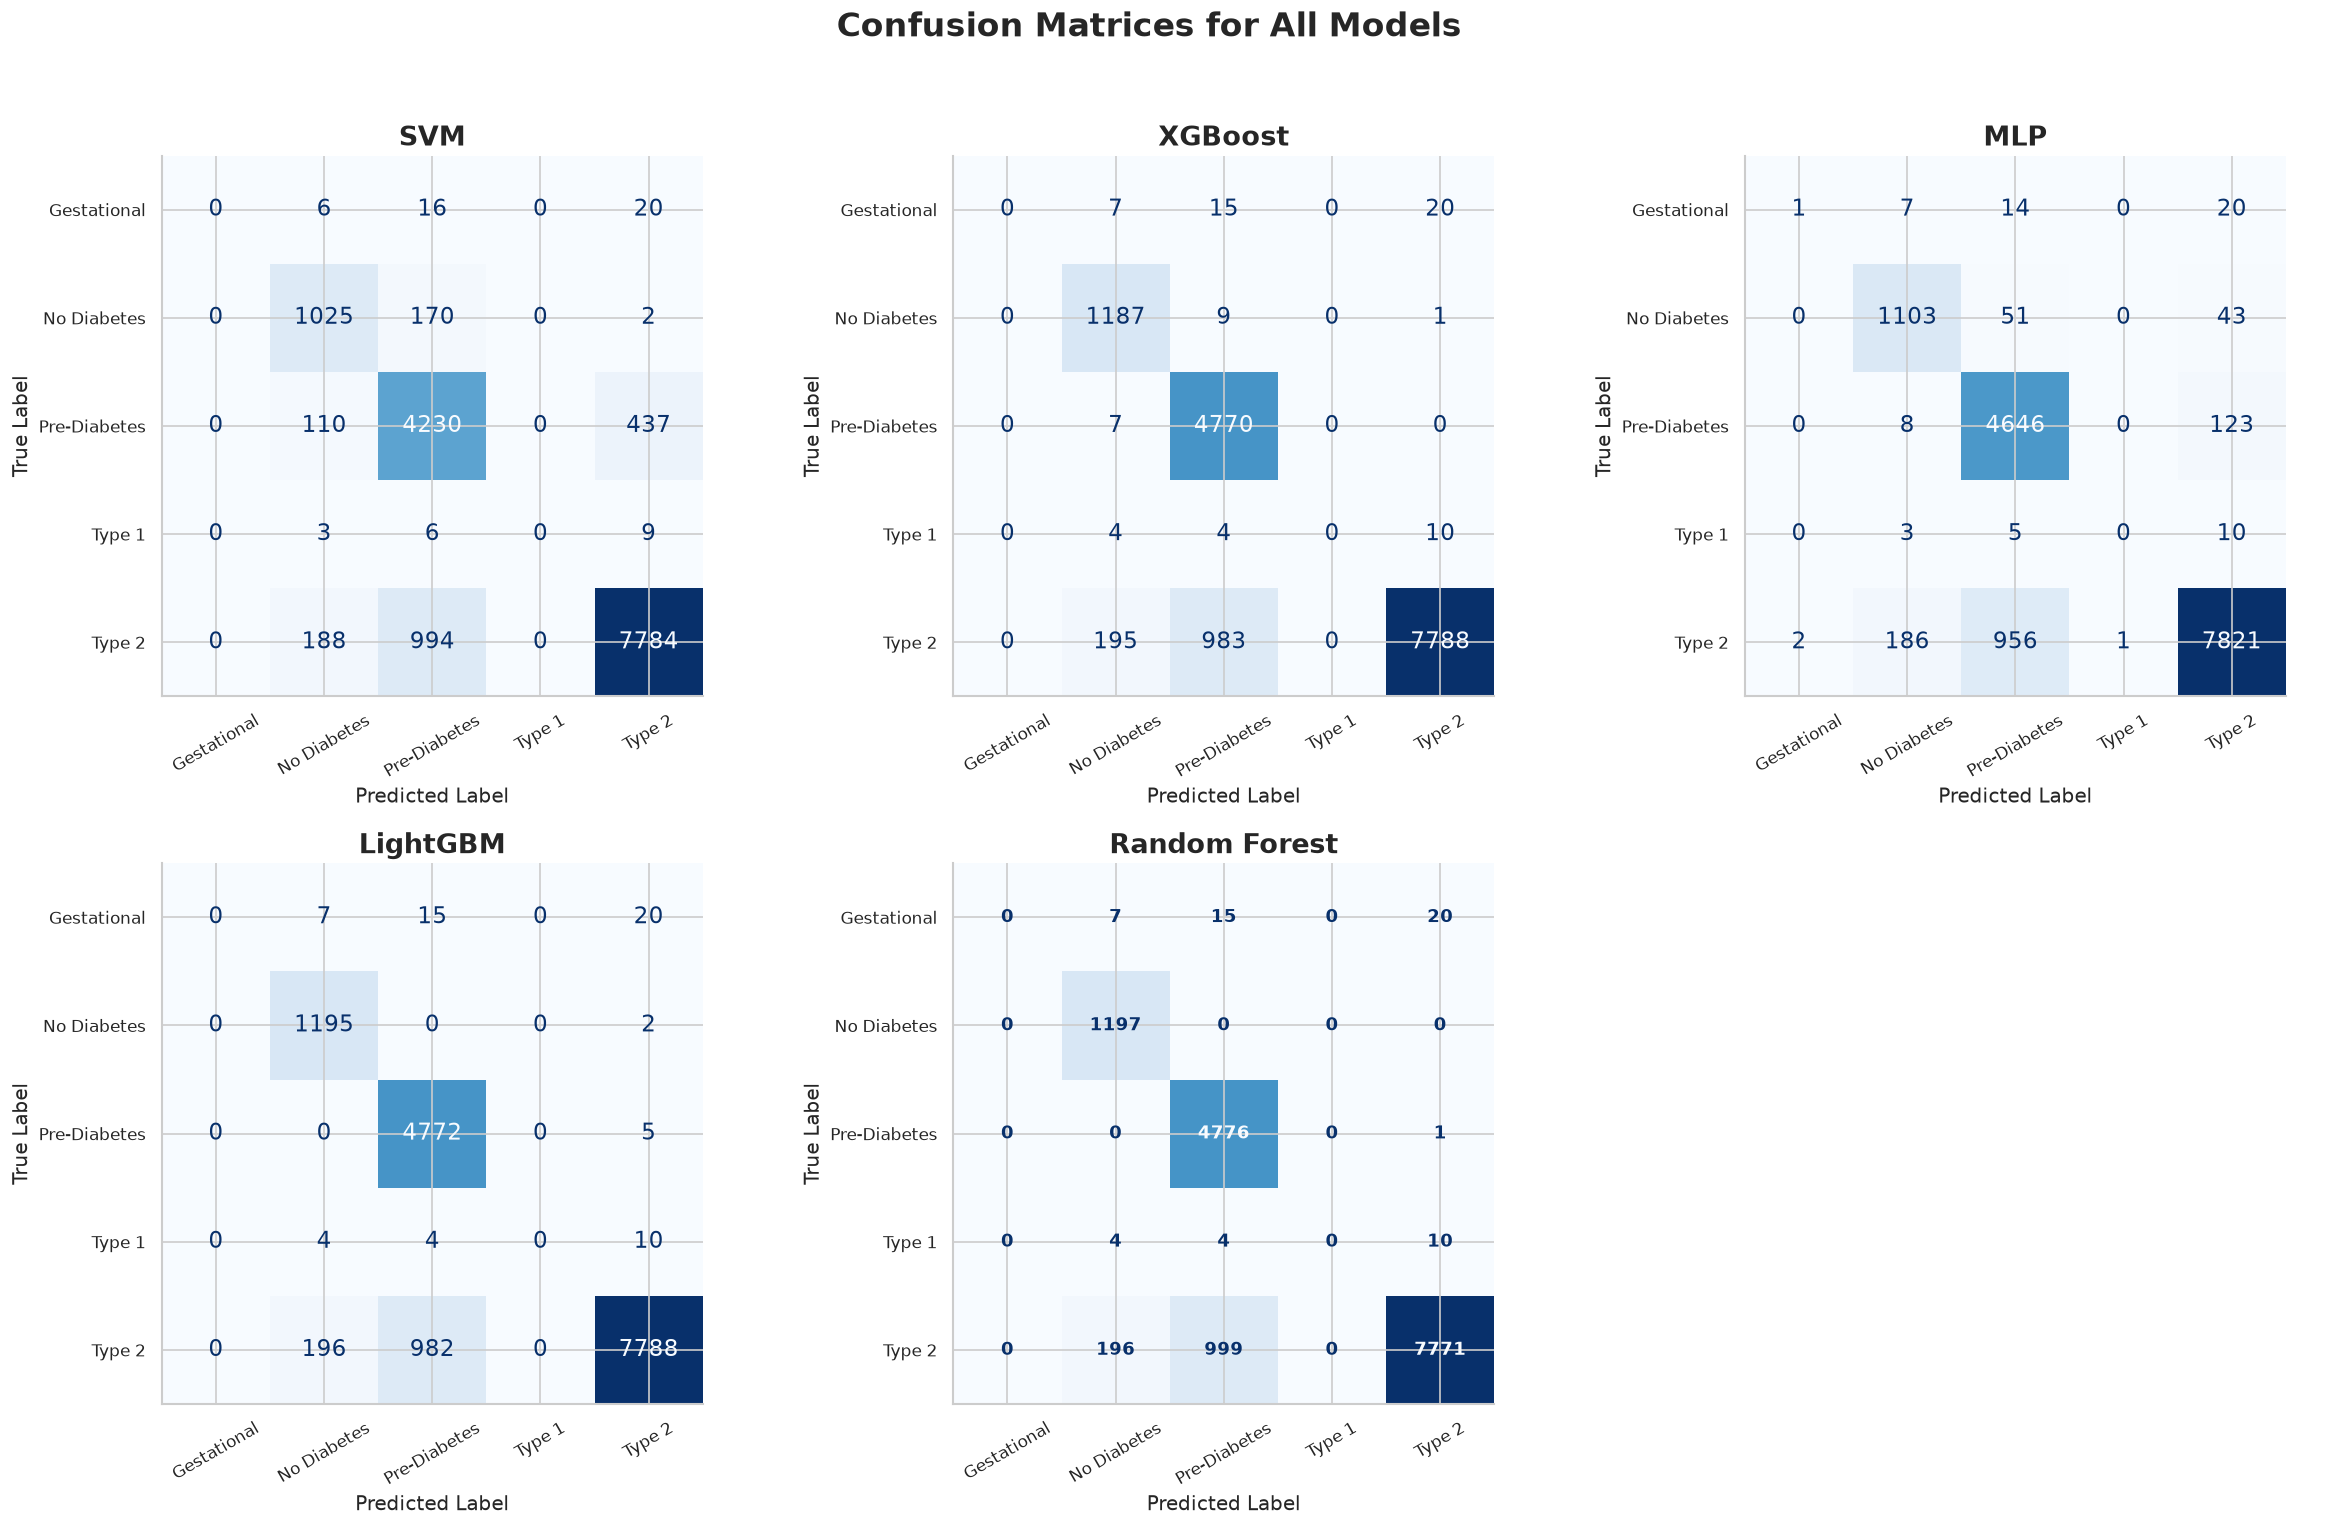

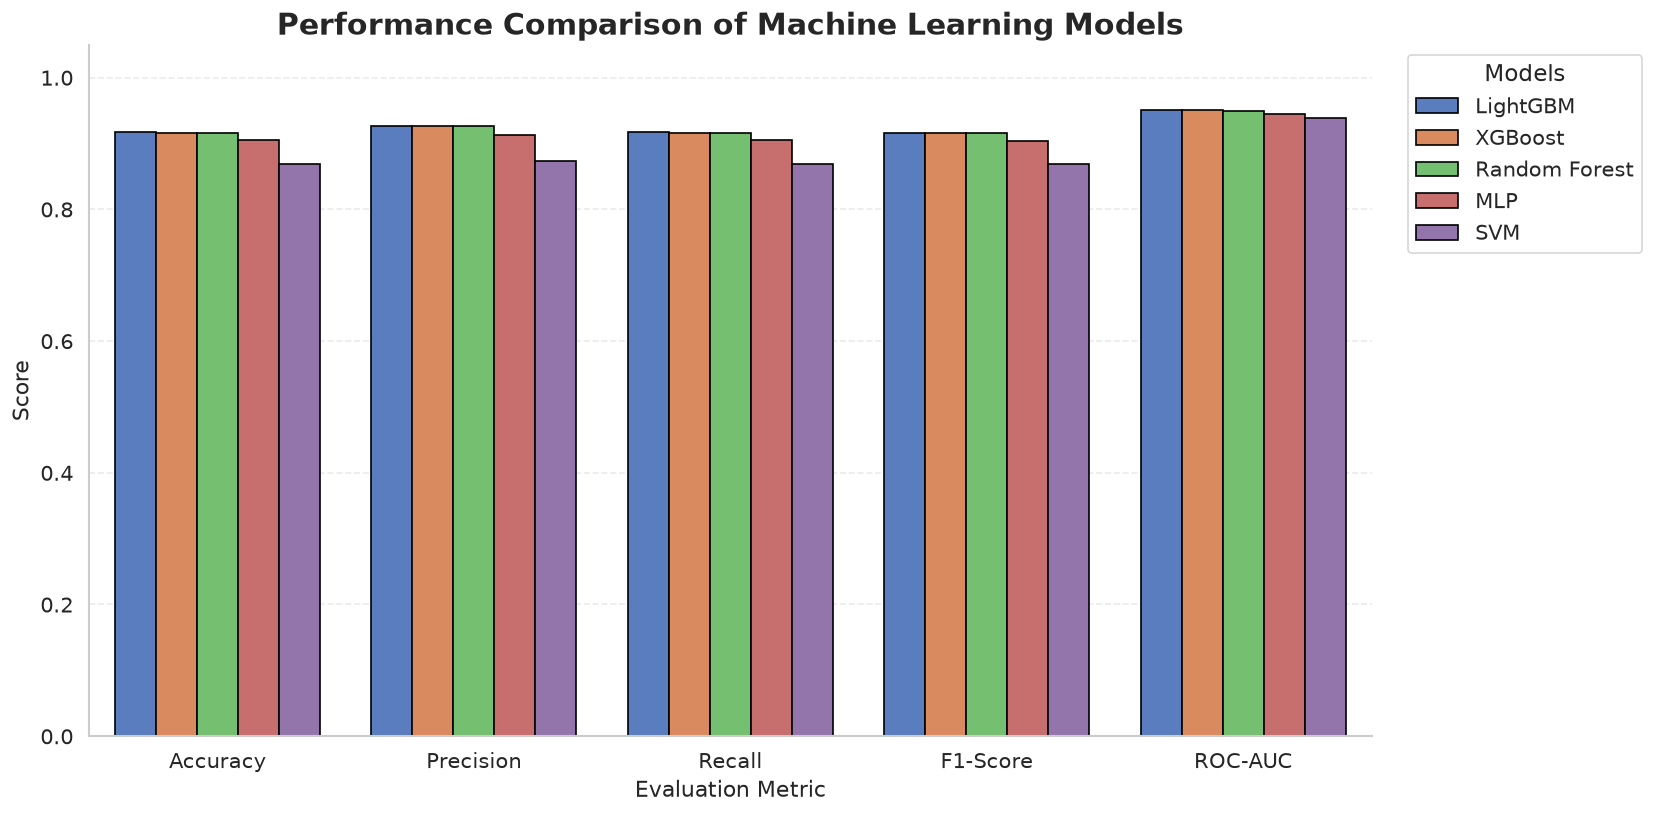

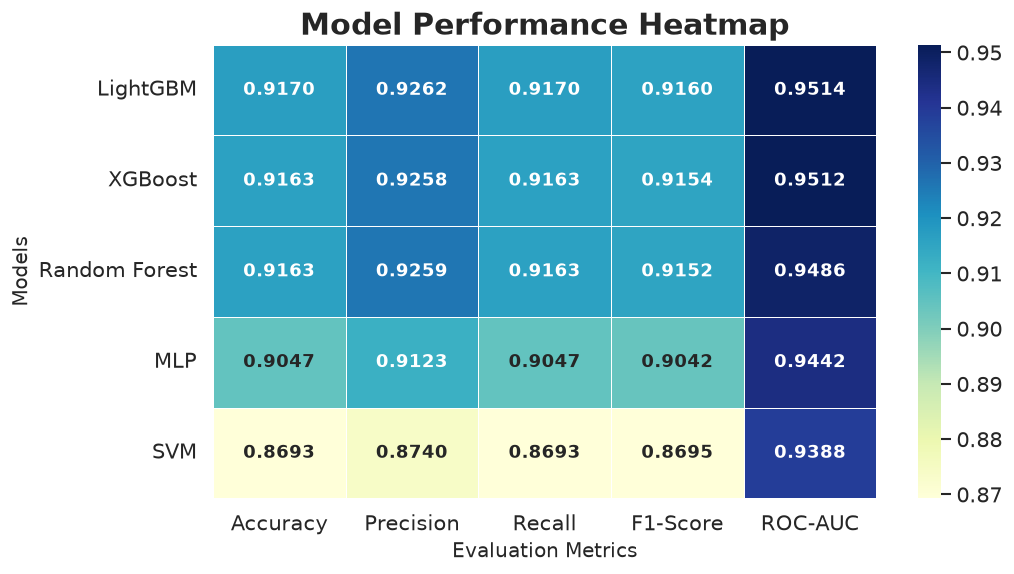

In [38]:
# Model Evaluation and Comparative Analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import label_binarize

from sklearn.metrics import (
 accuracy_score,
 precision_score,
 recall_score,
 f1_score,
 roc_auc_score,
 roc_curve,
 auc,
 confusion_matrix,
 ConfusionMatrixDisplay
)

# Models Dictionary

models = {

 "SVM": svm_model,

 "XGBoost": xgb_model,

 "MLP": mlp_model,

 "LightGBM": lgbm_model,

 "Random Forest": rf_model

}

# Class Names

class_names = [

 "Gestational",

 "No Diabetes",

 "Pre-Diabetes",

 "Type 1",

 "Type 2"

]

# Prepare Labels

y_val_bin = label_binarize(

 y_val,

 classes=[0,1,2,3,4]

)

# Evaluate Models

results = []

roc_results = {}

confusion_results = {}

for name, model in models.items():

 y_pred = model.predict(X_val_df)

 y_prob = model.predict_proba(X_val_df)

 accuracy = accuracy_score(
 y_val,
 y_pred
 )

 precision = precision_score(
 y_val,
 y_pred,
 average="weighted"
 )

 recall = recall_score(
 y_val,
 y_pred,
 average="weighted"
 )

 f1 = f1_score(
 y_val,
 y_pred,
 average="weighted"
 )

 roc_auc = roc_auc_score(
 y_val,
 y_prob,
 multi_class="ovr",
 average="weighted"
 )

 results.append({

 "Model": name,

 "Accuracy": accuracy,

 "Precision": precision,

 "Recall": recall,

 "F1-Score": f1,

 "ROC-AUC": roc_auc

 })

 fpr, tpr, _ = roc_curve(

 y_val_bin.ravel(),

 y_prob.ravel()

 )

 roc_results[name] = (

 fpr,

 tpr,

 auc(fpr, tpr)

 )

 confusion_results[name] = confusion_matrix(

 y_val,

 y_pred

 )

# Results Table

df_results = pd.DataFrame(results)

df_results = df_results.sort_values(

 by="ROC-AUC",

 ascending=False

).reset_index(drop=True)

print("="*80)

print("MODEL COMPARISON")

print("="*80)

display(df_results.round(4))

# ROC Curves

plt.figure(figsize=(10,8))

for name,(fpr,tpr,auc_score) in roc_results.items():

 plt.plot(

 fpr,

 tpr,

 linewidth=3,

 label=f"{name} (AUC={auc_score:.3f})"

 )

plt.plot([0,1],[0,1],"k--",linewidth=2)

plt.xlabel(

 "False Positive Rate",

 fontsize=13

)

plt.ylabel(

 "True Positive Rate",

 fontsize=13

)

plt.title(

 "ROC Curve Comparison",

 fontsize=18,

 fontweight="bold"

)

plt.legend(fontsize=10)

plt.grid(alpha=.3)

plt.tight_layout()

plt.show()

# Confusion Matrices

fig, axes = plt.subplots(

 2,

 3,

 figsize=(20,13)

)

axes = axes.flatten()

for ax,(name,cm) in zip(axes,confusion_results.items()):

 disp = ConfusionMatrixDisplay(

 confusion_matrix=cm,

 display_labels=class_names

 )

 disp.plot(

 ax=ax,

 cmap="Blues",

 colorbar=False,

 values_format="d"

 )

 ax.set_title(

 name,

 fontsize=16,

 fontweight="bold"

 )

 ax.set_xlabel(

 "Predicted Label",

 fontsize=12

 )

 ax.set_ylabel(

 "True Label",

 fontsize=12

 )

 ax.tick_params(

 axis="x",

 rotation=30,

 labelsize=10

 )

 ax.tick_params(

 axis="y",

 labelsize=10

 )

for txt in ax.texts:
    txt.set_fontsize(11)
    txt.set_fontweight("bold")

axes[-1].axis("off")

plt.suptitle(

 "Confusion Matrices for All Models",

 fontsize=20,

 fontweight="bold"

)

plt.tight_layout(rect=[0,0,1,0.96])

plt.show()

# Performance Comparison

plot_df = df_results.melt(

 id_vars="Model",

 var_name="Metric",

 value_name="Score"

)

plt.figure(figsize=(14,7))

sns.barplot(

 data=plot_df,

 x="Metric",

 y="Score",

 hue="Model",

 edgecolor="black"

)

plt.ylim(0,1.05)

plt.title(

 "Performance Comparison of Machine Learning Models",

 fontsize=18,

 fontweight="bold"

)

plt.xlabel(

 "Evaluation Metric",

 fontsize=13

)

plt.ylabel(

 "Score",

 fontsize=13

)

plt.grid(

 axis="y",

 linestyle="--",

 alpha=.4

)

plt.legend(

 title="Models",

 bbox_to_anchor=(1.02,1),

 loc="upper left"

)

plt.tight_layout()

plt.show()

# Heatmap

heat = df_results.set_index("Model")

plt.figure(figsize=(9,5))

sns.heatmap(

 heat,

 annot=True,

 fmt=".4f",

 cmap="YlGnBu",

 linewidths=.5,

 annot_kws={

 "size":11,

 "weight":"bold"

 }

)

plt.title(

 "Model Performance Heatmap",

 fontsize=18,

 fontweight="bold"

)

plt.xlabel(

 "Evaluation Metrics",

 fontsize=12

)

plt.ylabel(

 "Models",

 fontsize=12

)

plt.tight_layout()

plt.show()

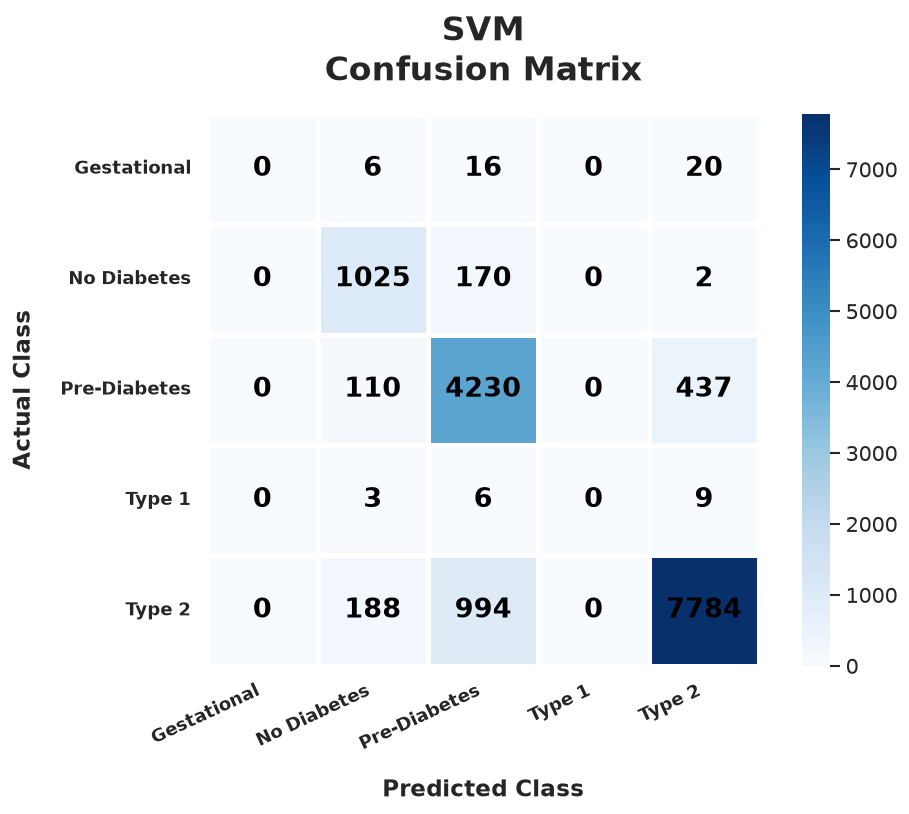

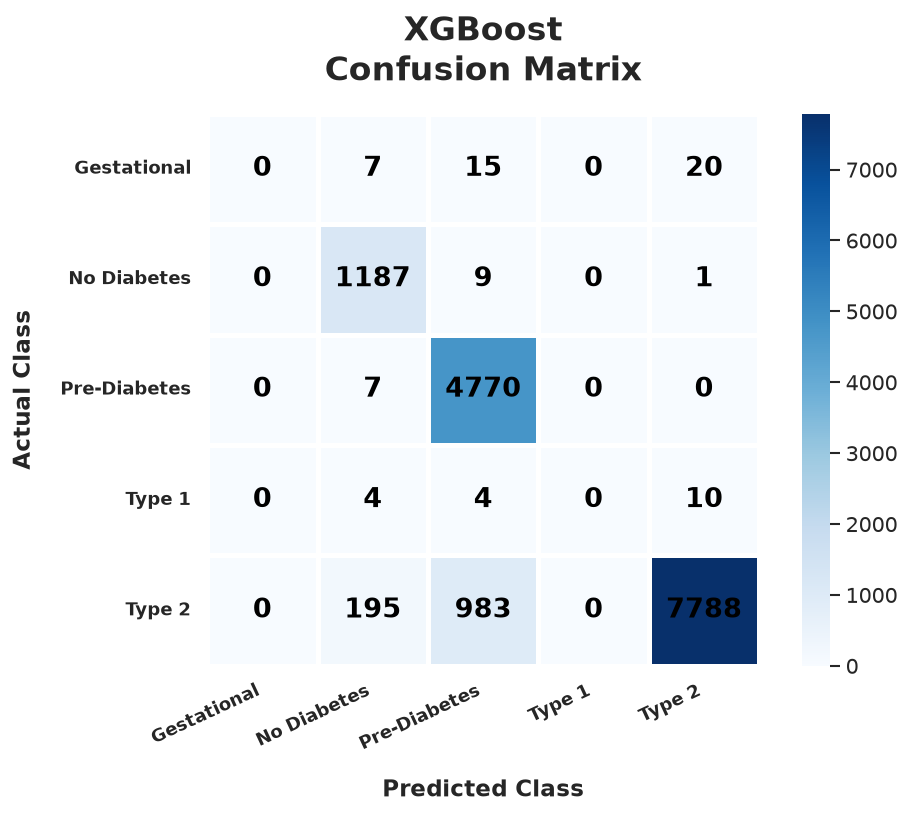

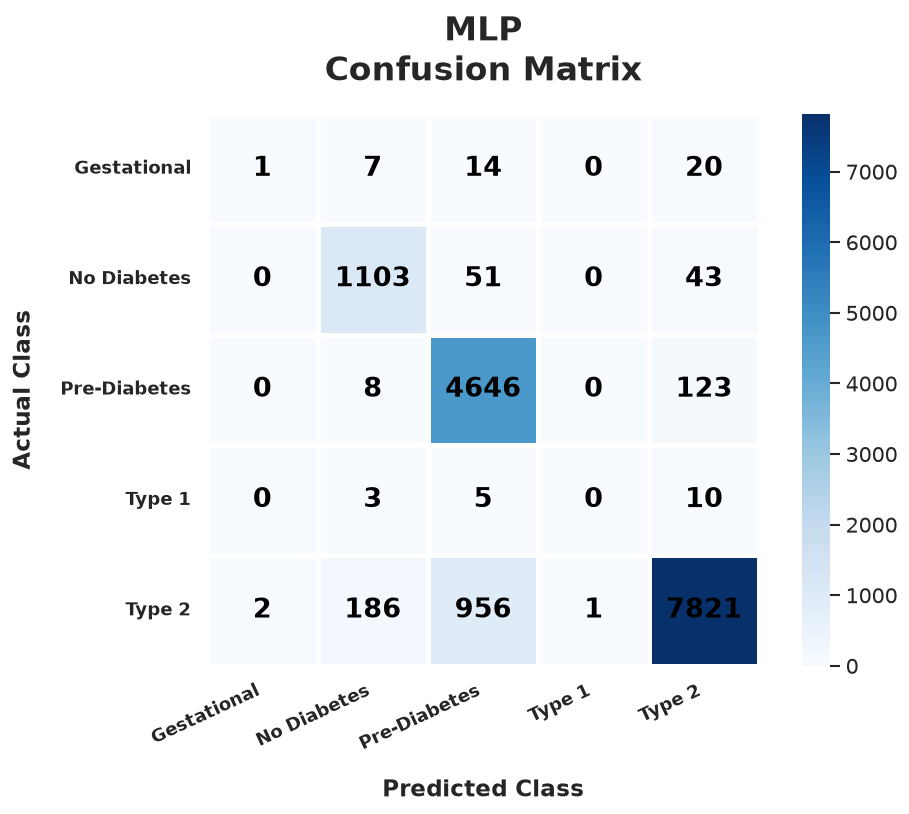

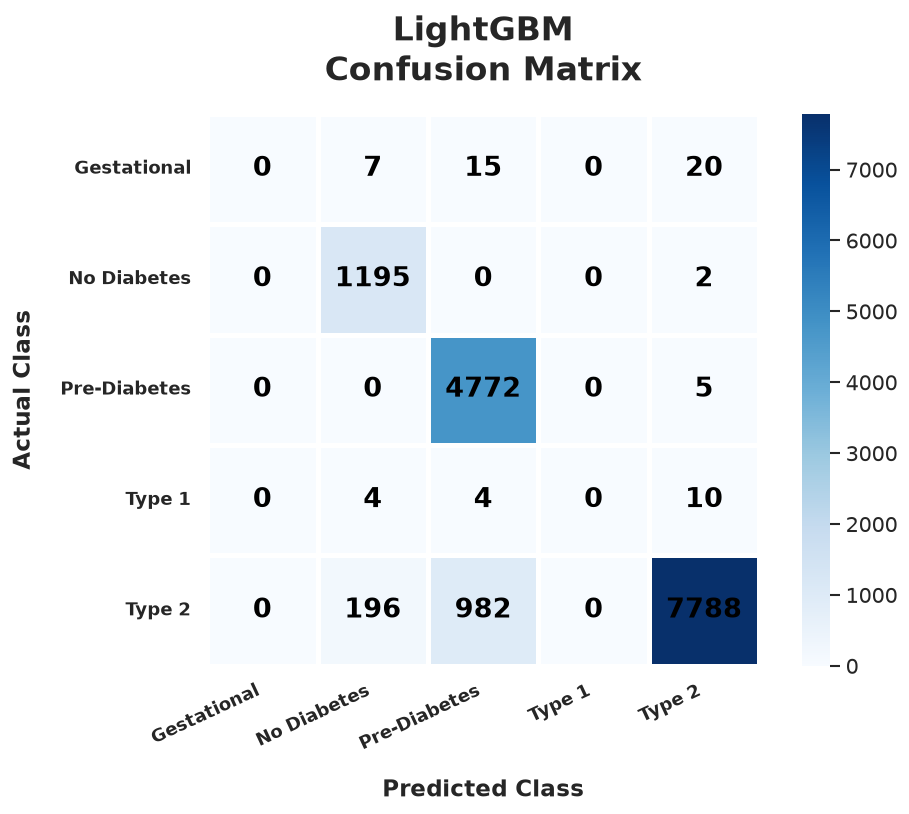

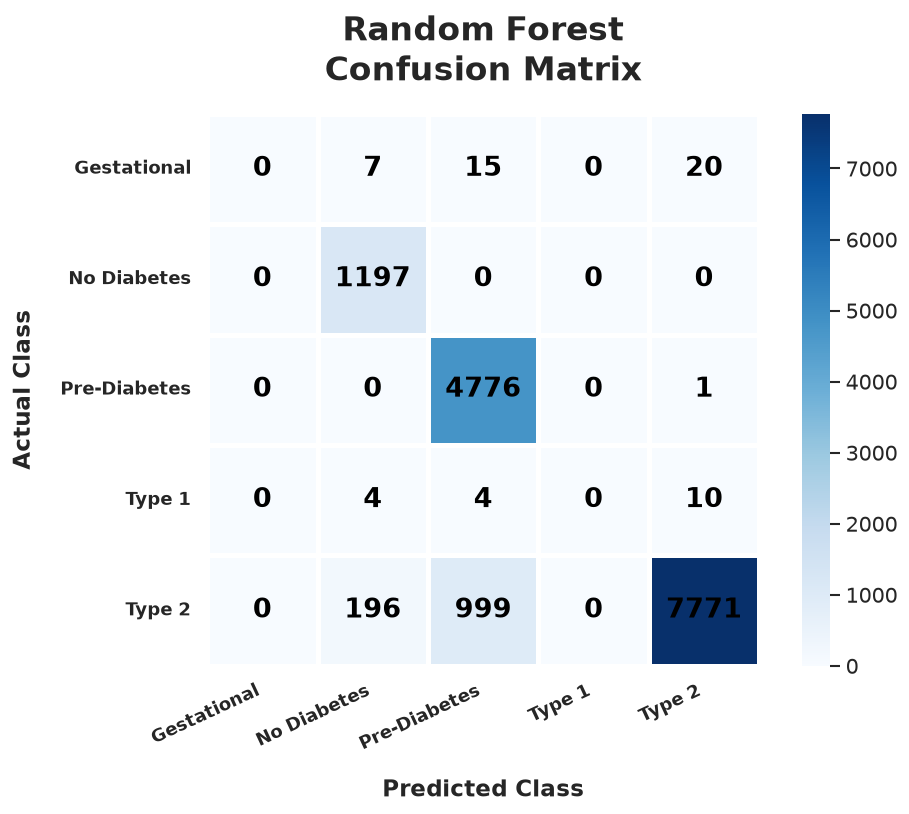

In [39]:

 #Confusion Matrices


import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

for name, cm in confusion_results.items():

    plt.figure(figsize=(9,7))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=2,
        linecolor="white",
        square=True,
        cbar=True,
        annot_kws={
            "fontsize":16,
            "fontweight":"bold",
            "color":"black"
        },
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(
        f"{name}\nConfusion Matrix",
        fontsize=20,
        fontweight="bold",
        pad=20
    )

    plt.xlabel(
        "Predicted Class",
        fontsize=14,
        fontweight="bold",
        labelpad=15
    )

    plt.ylabel(
        "Actual Class",
        fontsize=14,
        fontweight="bold",
        labelpad=15
    )

    plt.xticks(
        rotation=25,
        ha="right",
        fontsize=11,
        fontweight="bold"
    )

    plt.yticks(
        rotation=0,
        fontsize=11,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.show()

In [40]:
print(df[TARGET].value_counts())
print(np.unique(y_test, return_counts=True))
print(np.unique(y_pred, return_counts=True))

diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Gestational       278
Type 1            122
Name: count, dtype: int64
(array([0, 1, 2, 3, 4]), array([  14,  399, 1592,    6, 2989]))
(array([1, 2, 4]), array([1404, 5794, 7802]))


**FEATURE ENGINEERING SECTION**

# NON Linear Relationships

#Feature Importance using Mutual Information (After Feature Engineering)

In [41]:
# Mutual Information (Before Feature Engineering)

from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Calculate Mutual Information Scores
mi_scores = mutual_info_classif(
    X_train_opt,
    y_train_opt,
    random_state=42
)

# Create DataFrame
mi_df = pd.DataFrame({
    "Feature": X_train_opt.columns,
    "Mutual Information": mi_scores
})

# Sort Features
mi_df = mi_df.sort_values(
    by="Mutual Information",
    ascending=False
).reset_index(drop=True)

# Display Results
print("=" * 70)
print("MUTUAL INFORMATION SCORES (Before Feature Engineering)")
print("=" * 70)

display(mi_df.round(4))

# Top 10 Features
print("\nTop 10 Most Important Features:\n")
display(mi_df.head(10).round(4))

MUTUAL INFORMATION SCORES (Before Feature Engineering)


,Feature,Mutual Information
0,num__hba1c,0.5558
1,num__glucose_postprandial,0.3475
2,num__glucose_fasting,0.2684
3,num__family_history_diabetes,0.0271
4,num__age,0.0160
5,cat__smoking_status_Never,0.0104
6,num__physical_activity_minutes_per_week,0.0088
7,cat__gender_Male,0.0087
8,num__hypertension_history,0.0062
9,num__bmi,0.0058



Top 10 Most Important Features:



,Feature,Mutual Information
0,num__hba1c,0.5558
1,num__glucose_postprandial,0.3475
2,num__glucose_fasting,0.2684
3,num__family_history_diabetes,0.0271
4,num__age,0.0160
5,cat__smoking_status_Never,0.0104
6,num__physical_activity_minutes_per_week,0.0088
7,cat__gender_Male,0.0087
8,num__hypertension_history,0.0062
9,num__bmi,0.0058


The Mutual Information analysis shows that glycemic indicators such as HbA1c, postprandial glucose, and fasting glucose are the most influential features in predicting diabetes, indicating a strong relationship with the target variable.

In contrast, most demographic, lifestyle, and metabolic features (e.g., BMI, cholesterol levels, sleep duration, and gender) exhibit very low or near-zero importance, suggesting limited individual predictive contribution within this dataset.

**Experimental Plan**

To validate the impact of feature selection on model performance, three experimental scenarios will be conducted:

Baseline Model: Using all features (excluding leakage variables).
Filtered Features: Removing features with very low Mutual Information scores.
Top-K Features: Retaining only the most informative features based on ranking.

#**Data dimension before feature Engineering**

In [ ]:
X_train_df.shape

(80000, 40)

##  Feature Engineering (FE)

In [42]:
# FEATURE ENGINEERING (After Feature Selection)

# Create copies
X_train_fe = X_train_opt.copy()
X_val_fe = X_val_df.copy()
X_test_fe = X_test_df.copy()

print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# New Feature

print("Creating new feature...")

for df in [X_train_fe, X_val_fe, X_test_fe]:

    df["postprandial_to_fasting_ratio"] = (
        df["num__glucose_postprandial"] /
        (df["num__glucose_fasting"] + 1e-6)
    )

# Remove Low Information Features

print("Removing low-information features...")

low_information_features = [

    "num__diastolic_bp",
    "num__screen_time_hours_per_day",
    "num__diet_score",
    "num__alcohol_consumption_per_week",

    "cat__education_level_No formal",
    "cat__education_level_Postgraduate",

    "cat__income_level_Upper-Middle",

    "cat__employment_status_Unemployed",
    "cat__employment_status_Student"

]

for df in [X_train_fe, X_val_fe, X_test_fe]:

    df.drop(
        columns=low_information_features,
        errors="ignore",
        inplace=True
    )

# Summary

print("\nFeature Engineering Completed Successfully!\n")

print(f"Training Shape   : {X_train_fe.shape}")
print(f"Validation Shape : {X_val_fe.shape}")
print(f"Test Shape       : {X_test_fe.shape}")

print(f"\nTotal Features After FE : {X_train_fe.shape[1]}")

FEATURE ENGINEERING
Creating new feature...
Removing low-information features...

Feature Engineering Completed Successfully!

Training Shape   : (80000, 32)
Validation Shape : (15000, 32)
Test Shape       : (5000, 32)

Total Features After FE : 32


In [43]:
print(X_train_fe.columns)

Index(['num__age', 'num__physical_activity_minutes_per_week',
       'num__sleep_hours_per_day', 'num__family_history_diabetes',
       'num__hypertension_history', 'num__cardiovascular_history', 'num__bmi',
       'num__waist_to_hip_ratio', 'num__systolic_bp', 'num__heart_rate',
       'num__cholesterol_total', 'num__hdl_cholesterol',
       'num__ldl_cholesterol', 'num__triglycerides', 'num__glucose_fasting',
       'num__glucose_postprandial', 'num__insulin_level', 'num__hba1c',
       'cat__gender_Male', 'cat__gender_Other', 'cat__ethnicity_Black',
       'cat__ethnicity_Hispanic', 'cat__ethnicity_Other',
       'cat__ethnicity_White', 'cat__education_level_Highschool',
       'cat__income_level_Low', 'cat__income_level_Lower-Middle',
       'cat__income_level_Middle', 'cat__employment_status_Retired',
       'cat__smoking_status_Former', 'cat__smoking_status_Never',
       'postprandial_to_fasting_ratio'],
      dtype='object')


## Feature Engineering Experiments

Several clinically motivated engineered features were evaluated to improve the model's predictive performance, including:

- BMI-to-Waist-Hip Ratio
- Total Cholesterol-to-HDL Ratio
- Triglyceride-Glucose (TyG) Index
- Sleep-to-Screen Time Ratio

These features were implemented and evaluated using the same training and validation pipeline. However, they did not produce a meaningful improvement in the evaluation metrics (Accuracy, F1-score, and ROC-AUC). Therefore, they were excluded from the final feature set to maintain a simpler and more interpretable model.

| Engineered Feature    | Clinical Motivation       | Included in Final Model |
| --------------------- | ------------------------- | ----------------------- |
| BMI/Waist-Hip Ratio   | Central obesity indicator |  No                    |
| Cholesterol/HDL Ratio | Cardiometabolic risk      |  No                    |
| TyG Index             | Insulin resistance marker |  No                    |
| Sleep/Screen Ratio    | Lifestyle balance         |  No                    |


Although these engineered features are clinically meaningful, they did not improve the predictive performance of the evaluated models on this dataset. Therefore, they were excluded from the final feature set.

**save copy cleaned data**

In [44]:
# Save Feature Engineering Datasets

# Save Features
X_train_fe.to_csv("X_train_fe.csv", index=False)
X_val_fe.to_csv("X_val_fe.csv", index=False)
X_test_fe.to_csv("X_test_fe.csv", index=False)

# Save Targets
y_train_opt.to_frame(name="target").to_csv("y_train_fe.csv", index=False)
y_val.to_frame(name="target").to_csv("y_val_fe.csv", index=False)
y_test.to_frame(name="target").to_csv("y_test_fe.csv", index=False)

print("=" * 60)
print("Feature Engineering datasets saved successfully!")
print("=" * 60)

print(f"X_train_fe : {X_train_fe.shape}")
print(f"X_val_fe   : {X_val_fe.shape}")
print(f"X_test_fe  : {X_test_fe.shape}")

print(f"y_train_fe : {y_train_opt.shape}")
print(f"y_val_fe   : {y_val.shape}")
print(f"y_test_fe  : {y_test.shape}")

Feature Engineering datasets saved successfully!
X_train_fe : (80000, 32)
X_val_fe   : (15000, 32)
X_test_fe  : (5000, 32)
y_train_fe : (80000,)
y_val_fe   : (15000,)
y_test_fe  : (5000,)


#**SVM after Feature Engineering**

In [45]:
from sklearn.svm import SVC

import mlflow
import mlflow.sklearn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# MLflow

mlflow.end_run()

mlflow.set_experiment("Diabetes_Prediction_Project")

with mlflow.start_run(run_name="SVM_Multiclass_After_FE") as run:

    # TAGS

    mlflow.set_tag("model_type", "SVM")
    mlflow.set_tag("framework", "Scikit-Learn")
    mlflow.set_tag("classification_type", "Multi-Class")
    mlflow.set_tag("feature_engineering", "After")

    # MODEL

    svm_model = SVC(

        C=1.0,

        kernel="rbf",

        gamma="scale",

        probability=True,

        random_state=42

    )

    # TRAIN

    svm_model.fit(

        X_train_fe,

        y_train_opt

    )

    # VALIDATION

    val_pred = svm_model.predict(

        X_val_fe

    )

    val_prob = svm_model.predict_proba(

        X_val_fe

    )

    # METRICS

    accuracy = accuracy_score(

        y_val,

        val_pred

    )

    precision = precision_score(

        y_val,

        val_pred,

        average="weighted"

    )

    recall = recall_score(

        y_val,

        val_pred,

        average="weighted"

    )

    f1 = f1_score(

        y_val,

        val_pred,

        average="weighted"

    )

    roc_auc = roc_auc_score(

        y_val,

        val_prob,

        multi_class="ovr",

        average="weighted"

    )

    # PARAMETERS

    params = {

        "C":1.0,

        "kernel":"rbf",

        "gamma":"scale",

        "probability":True,

        "random_state":42

    }

    mlflow.log_params(params)

    # LOG METRICS

    mlflow.log_metric("accuracy",accuracy)

    mlflow.log_metric("precision",precision)

    mlflow.log_metric("recall",recall)

    mlflow.log_metric("f1_score",f1)

    mlflow.log_metric("roc_auc",roc_auc)

    # SAVE MODEL

    mlflow.sklearn.log_model(

        sk_model=svm_model,

        artifact_path="SVM_Model"

    )

    # RESULTS

    print("="*70)
    print("SVM AFTER FEATURE ENGINEERING")
    print("="*70)

    print("Run ID :",run.info.run_id)

    print("\nValidation Metrics\n")

    print(f"Accuracy : {accuracy:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall   : {recall:.4f}")

    print(f"F1 Score : {f1:.4f}")

    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report\n")

    print(

        classification_report(

            y_val,

            val_pred,

            target_names=[

                "Gestational",

                "No Diabetes",

                "Pre-Diabetes",

                "Type 1",

                "Type 2"

            ]

        )

    )

    print("\nConfusion Matrix\n")

    cm = confusion_matrix(

        y_val,

        val_pred

    )

    print(cm)

    print("\nRun Logged Successfully in MLflow.")

2026/07/15 13:58:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


SVM AFTER FEATURE ENGINEERING
Run ID : a5aa5b2720c843d09cb5a4be36ca860e

Validation Metrics

Accuracy : 0.8613
Precision: 0.8619
Recall   : 0.8613
F1 Score : 0.8609
ROC-AUC  : 0.9373

Classification Report

              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        42
 No Diabetes       0.77      0.84      0.80      1197
Pre-Diabetes       0.78      0.84      0.81      4777
      Type 1       0.00      0.00      0.00        18
      Type 2       0.92      0.88      0.90      8966

    accuracy                           0.86     15000
   macro avg       0.50      0.51      0.50     15000
weighted avg       0.86      0.86      0.86     15000


Confusion Matrix

[[   0    6   14    0   22]
 [   0 1000  197    0    0]
 [   0   99 4030    0  648]
 [   0    3    5    0   10]
 [   0  185  891    0 7890]]

Run Logged Successfully in MLflow.
🏃 View run SVM_Multiclass_After_FE at: http://127.0.0.1:5000/#/experiments/928373854848148195/runs/a5aa5b272

#**XGBoost after Feature Engineering**

In [47]:
import time
from xgboost import XGBClassifier

import mlflow
import mlflow.xgboost

from sklearn.metrics import (
 accuracy_score,
 precision_score,
 recall_score,
 f1_score,
 roc_auc_score,
 classification_report,
 confusion_matrix
)

# ==========================================================
# MLflow Run
# ==========================================================

mlflow.end_run()

with mlflow.start_run(run_name="XGBoost_Multiclass_After_FE") as run:

 # ==========================================================
 # TAGS
 # ==========================================================

 mlflow.set_tag("model_type", "XGBoost")
 mlflow.set_tag("framework", "XGBoost")
 mlflow.set_tag("classification_type", "multiclass")
 mlflow.set_tag("target", "diabetes_stage")
 mlflow.set_tag("feature_engineering", "after")

 # ==========================================================
 # MODEL
 # ==========================================================

 xgb_model = XGBClassifier(
 objective="multi:softprob",
 num_class=5,
 n_estimators=300,
 max_depth=6,
 learning_rate=0.05,
 subsample=0.8,
 colsample_bytree=0.8,
 eval_metric="mlogloss",
 random_state=42
 )

 # ==========================================================
 # TRAINING TIME
 # ==========================================================

 xgb_train_start = time.perf_counter()

 xgb_model.fit(
 X_train_fe,
 y_train_opt
 )

 xgb_training_time = time.perf_counter() - xgb_train_start

 # ==========================================================
 # INFERENCE TIME
 # ==========================================================

 xgb_inf_start = time.perf_counter()

 val_pred = xgb_model.predict(X_val_fe)
 val_prob = xgb_model.predict_proba(X_val_fe)

 xgb_inference_time = time.perf_counter() - xgb_inf_start

 # ==========================================================
 # METRICS
 # ==========================================================

 accuracy = accuracy_score(y_val, val_pred)
 precision = precision_score(y_val, val_pred, average="weighted")
 recall = recall_score(y_val, val_pred, average="weighted")
 f1 = f1_score(y_val, val_pred, average="weighted")
 roc_auc = roc_auc_score(
 y_val,
 val_prob,
 multi_class="ovr",
 average="weighted"
 )

 # ==========================================================
 # TRAINABLE PARAMETERS (Total number of nodes across all trees)
 # ==========================================================

 booster = xgb_model.get_booster()
 trees = booster.get_dump(with_stats=False) # List of each tree as text
 total_nodes = 0
 for tree in trees:
    total_nodes += len(tree.split('\n'))  # Each line represents a node 

 # ==========================================================
 # LOG PARAMETERS
 # ==========================================================

 params = {
 "objective": "multi:softprob",
 "num_class": 5,
 "n_estimators": 300,
 "max_depth": 6,
 "learning_rate": 0.05,
 "subsample": 0.8,
 "colsample_bytree": 0.8,
 "eval_metric": "mlogloss",
 "random_state": 42,
 "trainable_parameters": total_nodes # Total nodes (trainable parameters)
 }

 mlflow.log_params(params)

 # ==========================================================
 # LOG METRICS (including time metrics)
 # ==========================================================

 mlflow.log_metric("accuracy", accuracy)
 mlflow.log_metric("precision", precision)
 mlflow.log_metric("recall", recall)
 mlflow.log_metric("f1_score", f1)
 mlflow.log_metric("roc_auc", roc_auc)
 mlflow.log_metric("training_time_sec", xgb_training_time)
 mlflow.log_metric("inference_time_sec", xgb_inference_time)

 # ==========================================================
 # SAVE MODEL
 # ==========================================================

 mlflow.xgboost.log_model(
 xgb_model,
 artifact_path="XGBoost_Model"
 )

 # ==========================================================
 # RESULTS
 # ==========================================================

 print("=" * 60)
 print("XGBOOST AFTER FEATURE ENGINEERING")
 print("=" * 60)

 print("Run ID :", run.info.run_id)

 print("\nValidation Metrics")
 print(f"Accuracy : {accuracy:.4f}")
 print(f"Precision: {precision:.4f}")
 print(f"Recall : {recall:.4f}")
 print(f"F1 Score : {f1:.4f}")
 print(f"ROC-AUC : {roc_auc:.4f}")

 print("\nClassification Report\n")
 print(
 classification_report(
 y_val,
 val_pred,
 target_names=[
 "Gestational",
 "No Diabetes",
 "Pre-Diabetes",
 "Type 1",
 "Type 2"
 ]
 )
 )

 print("\nConfusion Matrix\n")
 cm = confusion_matrix(y_val, val_pred)
 print(cm)

 print("\n" + "-" * 40)
 print(f"Training Time : {xgb_training_time:.4f} sec")
 print(f"Inference Time : {xgb_inference_time:.6f} sec")
 print(f"Trainable Parameters (Total Nodes): {total_nodes:,}")
 print("-" * 40)

 print("\nRun Logged Successfully in MLflow.")

2026/07/15 14:00:36 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBOOST AFTER FEATURE ENGINEERING
Run ID : bf33cf53dfaf436e8be9c974a9e58039

Validation Metrics
Accuracy : 0.9161
Precision: 0.9256
Recall : 0.9161
F1 Score : 0.9152
ROC-AUC : 0.9514

Classification Report

              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        42
 No Diabetes       0.85      0.99      0.91      1197
Pre-Diabetes       0.83      1.00      0.90      4777
      Type 1       0.00      0.00      0.00        18
      Type 2       1.00      0.87      0.93      8966

    accuracy                           0.92     15000
   macro avg       0.53      0.57      0.55     15000
weighted avg       0.93      0.92      0.92     15000


Confusion Matrix

[[   0    7   15    0   20]
 [   0 1186   11    0    0]
 [   0    6 4768    0    3]
 [   0    4    4    0   10]
 [   0  197  981    0 7788]]

----------------------------------------
Training Time : 2.4754 sec
Inference Time : 0.036876 sec
Trainable Parameters (Total Nodes): 83,908
--

#**MLP after Feature Engineering**

In [48]:
from sklearn.neural_network import MLPClassifier

import mlflow
import mlflow.sklearn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# MLflow Run

mlflow.end_run()

with mlflow.start_run(run_name="MLP_Multiclass_After_FE") as run:

    
    # TAGS

    mlflow.set_tag("model_type", "MLPClassifier")
    mlflow.set_tag("framework", "Scikit-Learn")
    mlflow.set_tag("classification_type", "multiclass")
    mlflow.set_tag("target", "diabetes_stage")
    mlflow.set_tag("feature_engineering", "after")

    # MODEL

    mlp_model = MLPClassifier(

        hidden_layer_sizes=(100,),

        activation="relu",

        solver="adam",

        alpha=0.0001,

        learning_rate_init=0.001,

        max_iter=500,

        random_state=42

    )

    # TRAIN

    mlp_model.fit(

        X_train_fe,

        y_train_opt

    )

    # PREDICTIONS

    val_pred = mlp_model.predict(X_val_fe)

    val_prob = mlp_model.predict_proba(X_val_fe)

    # METRICS

    accuracy = accuracy_score(

        y_val,

        val_pred

    )

    precision = precision_score(

        y_val,

        val_pred,

        average="weighted"

    )

    recall = recall_score(

        y_val,

        val_pred,

        average="weighted"

    )

    f1 = f1_score(

        y_val,

        val_pred,

        average="weighted"

    )

    roc_auc = roc_auc_score(

        y_val,

        val_prob,

        multi_class="ovr",

        average="weighted"

    )

    # PARAMETERS

    params = {

        "hidden_layer_sizes": (100,),

        "activation": "relu",

        "solver": "adam",

        "alpha": 0.0001,

        "learning_rate_init": 0.001,

        "max_iter": 500,

        "random_state": 42

    }

    mlflow.log_params(params)

    # METRICS

    mlflow.log_metric("accuracy", accuracy)

    mlflow.log_metric("precision", precision)

    mlflow.log_metric("recall", recall)

    mlflow.log_metric("f1_score", f1)

    mlflow.log_metric("roc_auc", roc_auc)

    # SAVE MODEL

    mlflow.sklearn.log_model(

        sk_model=mlp_model,

        artifact_path="MLP_Model",

        serialization_format="pickle"

    )

    # ==========================================================
    # RESULTS
    # ==========================================================

    print("=" * 60)

    print("Run ID :", run.info.run_id)

    print("=" * 60)

    print("\nRun Logged Successfully in MLflow")

    print("\nValidation Metrics")

    print(f"Accuracy : {accuracy:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall   : {recall:.4f}")

    print(f"F1 Score : {f1:.4f}")

    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report\n")

    print(

        classification_report(

            y_val,

            val_pred,

            target_names=[

                "Gestational",

                "No Diabetes",

                "Pre-Diabetes",

                "Type 1",

                "Type 2"

            ]

        )

    )

    print("\nConfusion Matrix\n")

    cm = confusion_matrix(

        y_val,

        val_pred

    )

    print(cm)

2026/07/15 14:01:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run ID : a3935292e0b14d0fa53efca6bcc28fbd

Run Logged Successfully in MLflow

Validation Metrics
Accuracy : 0.9022
Precision: 0.9071
Recall   : 0.9022
F1 Score : 0.9016
ROC-AUC  : 0.9455

Classification Report

              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        42
 No Diabetes       0.84      0.93      0.89      1197
Pre-Diabetes       0.82      0.96      0.88      4777
      Type 1       0.00      0.00      0.00        18
      Type 2       0.97      0.88      0.92      8966

    accuracy                           0.90     15000
   macro avg       0.53      0.55      0.54     15000
weighted avg       0.91      0.90      0.90     15000


Confusion Matrix

[[   0    7   15    0   20]
 [   1 1119   25    0   52]
 [   1   15 4565    0  196]
 [   0    3    5    0   10]
 [   5  181  931    0 7849]]
🏃 View run MLP_Multiclass_After_FE at: http://127.0.0.1:5000/#/experiments/928373854848148195/runs/a3935292e0b14d0fa53efca6bcc28fbd
🧪 View e

In [49]:
from mlflow import search_runs
from mlflow.tracking import MlflowClient

client = MlflowClient()

def get_latest_run_id(run_name):
    runs = search_runs(experiment_names=["Diabetes_Prediction_Project"])
    run = runs[runs["tags.mlflow.runName"] == run_name].iloc[0]
    return run["run_id"]

for run_name in [
    "SVM_Multiclass_After_FE",
    "XGBoost_Multiclass_After_FE",
    "MLP_Multiclass_After_FE"
]:

    run_id = get_latest_run_id(run_name)

    print("="*60)
    print(run_name)
    print("Run ID:", run_id)

    artifacts = client.list_artifacts(run_id)

    for a in artifacts:
        print("Artifact:", a.path)

SVM_Multiclass_After_FE
Run ID: a5aa5b2720c843d09cb5a4be36ca860e
Artifact: SVM_Model
XGBoost_Multiclass_After_FE
Run ID: bf33cf53dfaf436e8be9c974a9e58039
Artifact: XGBoost_Model
MLP_Multiclass_After_FE
Run ID: a3935292e0b14d0fa53efca6bcc28fbd
Artifact: MLP_Model


In [50]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# SVM
svm_model = mlflow.sklearn.load_model(
    f"runs:/{get_latest_run_id('SVM_Multiclass_After_FE')}/SVM_Model"
)

# XGBoost
xgb_model = mlflow.xgboost.load_model(
    f"runs:/{get_latest_run_id('XGBoost_Multiclass_After_FE')}/XGBoost_Model"
)

# MLP
mlp_model = mlflow.sklearn.load_model(
    f"runs:/{get_latest_run_id('MLP_Multiclass_After_FE')}/MLP_Model"
)

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.9161,0.9256,0.9161,0.9152,0.9514
1,MLP,0.9022,0.9071,0.9022,0.9016,0.9455
2,SVM,0.8613,0.8619,0.8613,0.8609,0.9373


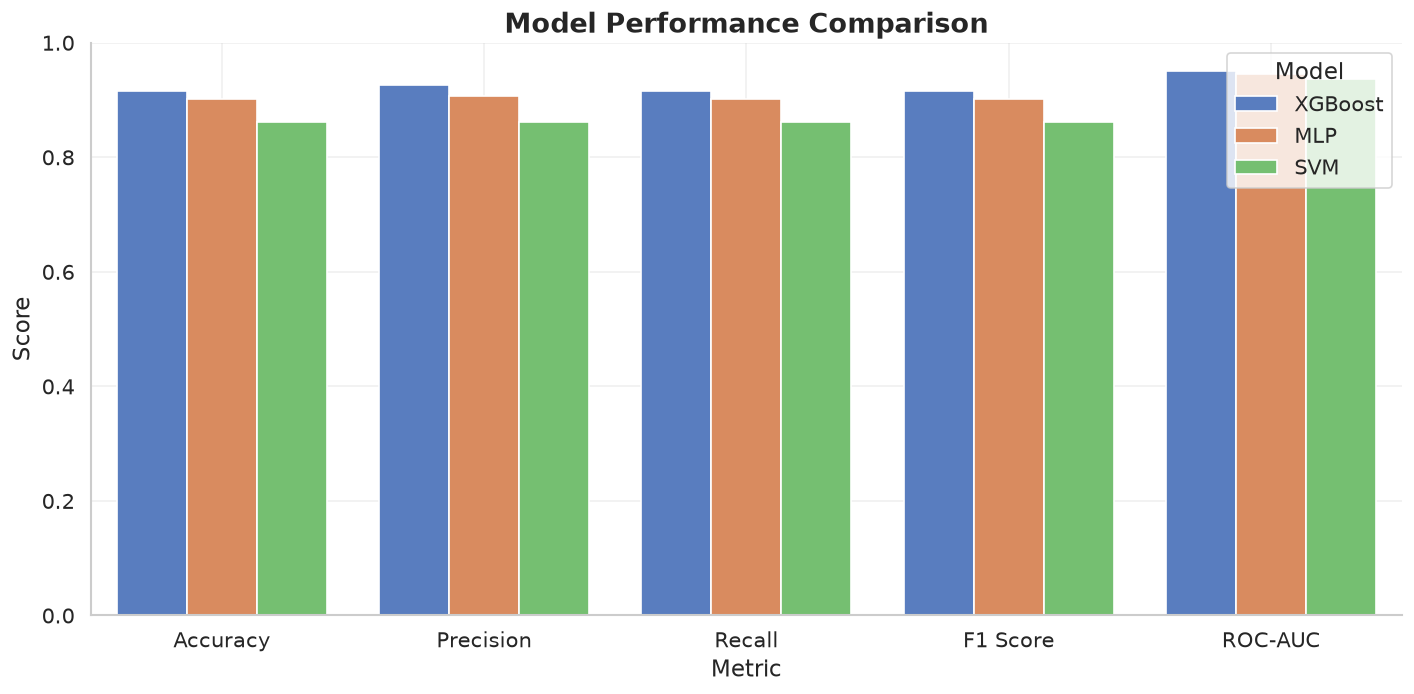

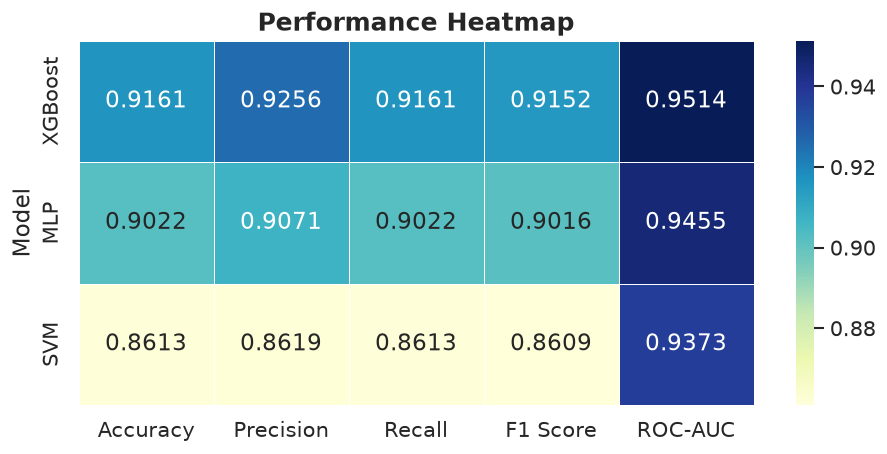



SVM
              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        42
 No Diabetes       0.77      0.84      0.80      1197
Pre-Diabetes       0.78      0.84      0.81      4777
      Type 1       0.00      0.00      0.00        18
      Type 2       0.92      0.88      0.90      8966

    accuracy                           0.86     15000
   macro avg       0.50      0.51      0.50     15000
weighted avg       0.86      0.86      0.86     15000



XGBOOST
              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        42
 No Diabetes       0.85      0.99      0.91      1197
Pre-Diabetes       0.83      1.00      0.90      4777
      Type 1       0.00      0.00      0.00        18
      Type 2       1.00      0.87      0.93      8966

    accuracy                           0.92     15000
   macro avg       0.53      0.57      0.55     15000
weighted avg       0.93      0.92      0.92     15000



MLP


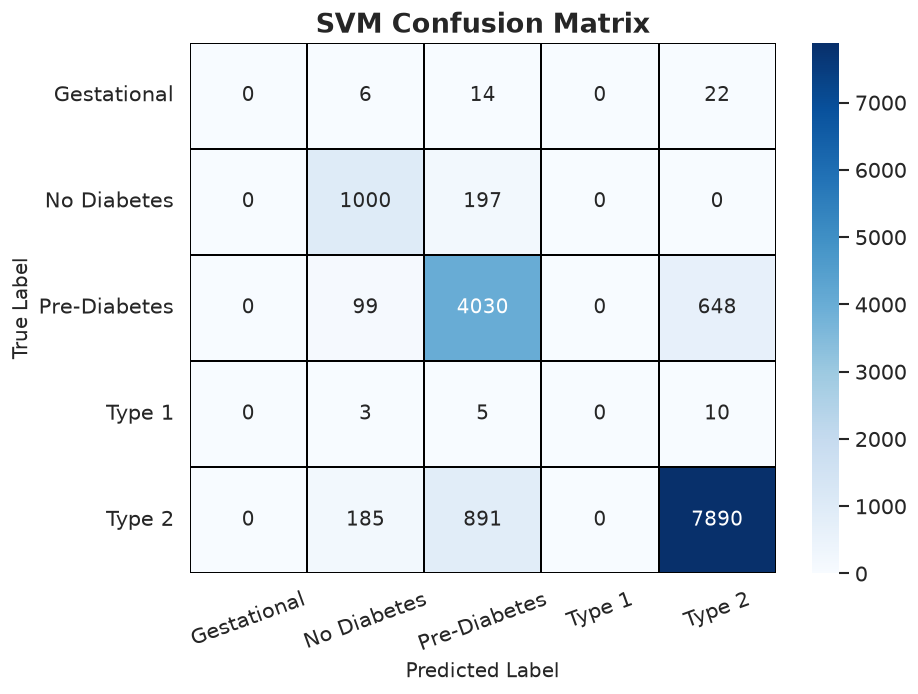

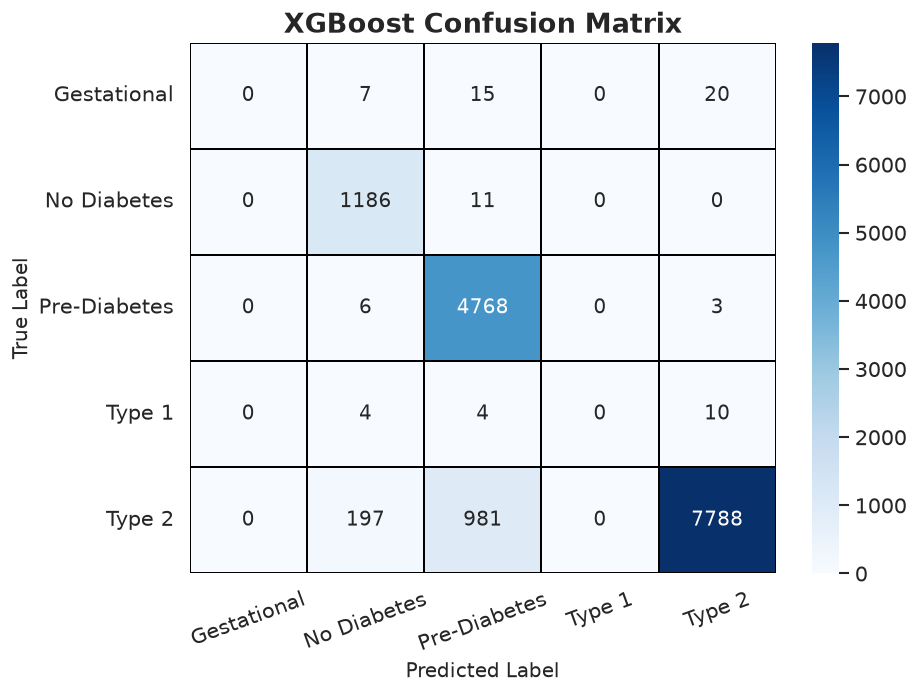

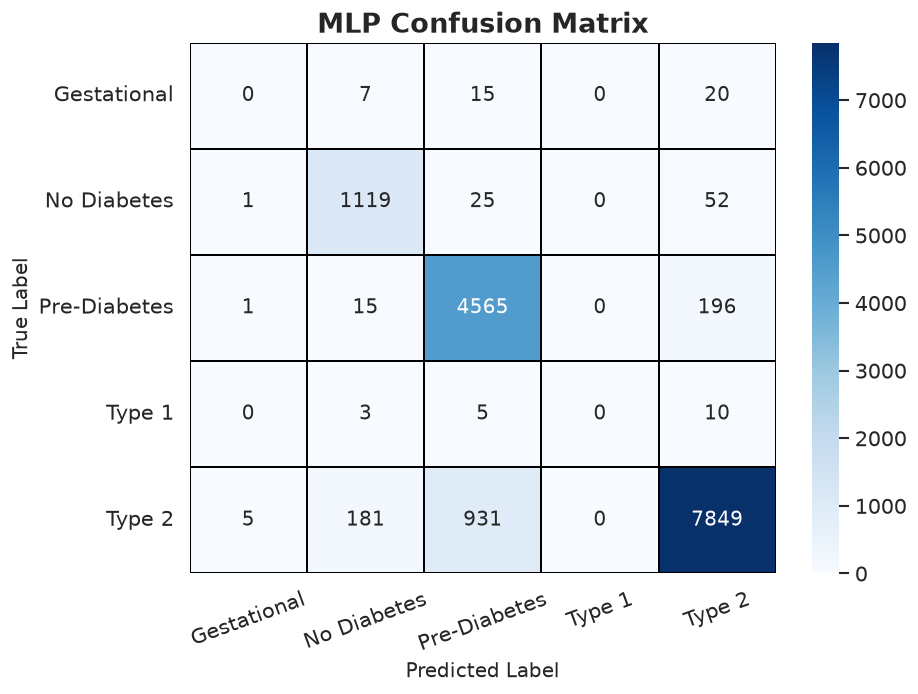


Comparison Finished Successfully.


In [51]:
# ==========================================================
# Model Evaluation & Comparison (After Feature Engineering)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ==========================================================
# Models
# ==========================================================

models = {

    "SVM": svm_model,
    "XGBoost": xgb_model,
    "MLP": mlp_model

}

# ==========================================================
# Class Names
# ==========================================================

class_names = [
    "Gestational",
    "No Diabetes",
    "Pre-Diabetes",
    "Type 1",
    "Type 2"
]

# ==========================================================
# Evaluation
# ==========================================================

results = []

confusion_results = {}

y_val_bin = label_binarize(
    y_val,
    classes=np.unique(y_val)
)

for name, model in models.items():

    y_pred = model.predict(X_val_fe)

    y_prob = model.predict_proba(X_val_fe)

    accuracy = accuracy_score(y_val, y_pred)

    precision = precision_score(
        y_val,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_val,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_val,
        y_pred,
        average="weighted"
    )

    roc_auc = roc_auc_score(
        y_val_bin,
        y_prob,
        average="weighted",
        multi_class="ovr"
    )

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC-AUC": roc_auc

    })

    confusion_results[name] = confusion_matrix(
        y_val,
        y_pred
    )

# ==========================================================
# Results Table
# ==========================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("="*70)
print("MODEL COMPARISON")
print("="*70)

display(results_df.round(4))

# ==========================================================
# Bar Plot
# ==========================================================

plot_df = results_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=plot_df,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.ylim(0,1)

plt.title(
    "Model Performance Comparison",
    fontsize=16,
    weight="bold"
)

plt.grid(alpha=.3)

plt.tight_layout()

plt.show()

# ==========================================================
# Heatmap
# ==========================================================

plt.figure(figsize=(8,4))

sns.heatmap(
    results_df.set_index("Model"),
    annot=True,
    cmap="YlGnBu",
    fmt=".4f",
    linewidths=.5
)

plt.title(
    "Performance Heatmap",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()

plt.show()

# Classification Reports

for name, model in models.items():

    print("\n")
    print("="*80)
    print(name.upper())
    print("="*80)

    y_pred = model.predict(X_val_fe)

    print(

        classification_report(

            y_val,

            y_pred,

            target_names=class_names

        )

    )

 #Confusion Matrix


for name, cm in confusion_results.items():

    plt.figure(figsize=(8,6))

    sns.heatmap(

        cm,

        annot=True,

        fmt="d",

        cmap="Blues",

        linewidths=1,

        linecolor="black",

        xticklabels=class_names,

        yticklabels=class_names,

        cbar=True,

        annot_kws={"size":12}

    )

    plt.title(
        f"{name} Confusion Matrix",
        fontsize=16,
        weight="bold"
    )

    plt.xlabel(
        "Predicted Label",
        fontsize=12
    )

    plt.ylabel(
        "True Label",
        fontsize=12
    )

    plt.xticks(rotation=20)

    plt.yticks(rotation=0)

    plt.tight_layout()

    plt.show()

print("\nComparison Finished Successfully.")

#**models with PCA**

In [52]:
from sklearn.decomposition import PCA
import numpy as np

print("=" * 60)
print("Applying PCA")
print("=" * 60)

# PCA
# Retain 95% of the variance

pca = PCA(
    n_components=0.95,
    random_state=42
)

# Fit on training data only
X_train_pca = pca.fit_transform(X_train_fe)

# Transform validation and test
X_val_pca = pca.transform(X_val_fe)
X_test_pca = pca.transform(X_test_fe)

# Results

print(f"Train Shape Before PCA : {X_train_fe.shape}")
print(f"Train Shape After PCA  : {X_train_pca.shape}")

print(f"Validation Shape After PCA : {X_val_pca.shape}")
print(f"Test Shape After PCA       : {X_test_pca.shape}")

print(f"\nNumber of Principal Components : {pca.n_components_}")

print(f"Explained Variance Retained : {np.sum(pca.explained_variance_ratio_) * 100:.2f}%")

print("=" * 60)
print("PCA Completed Successfully")
print("=" * 60)

Applying PCA
Train Shape Before PCA : (80000, 32)
Train Shape After PCA  : (80000, 3)
Validation Shape After PCA : (15000, 3)
Test Shape After PCA       : (5000, 3)

Number of Principal Components : 3
Explained Variance Retained : 95.57%
PCA Completed Successfully


#**SVM + PCA**

In [53]:
from sklearn.svm import SVC

import mlflow
import mlflow.sklearn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# MLflow

mlflow.end_run()

mlflow.set_experiment("Diabetes_Prediction_Project")

with mlflow.start_run(run_name="SVM_PCA") as run:

    # TAGS

    mlflow.set_tag("model_type", "SVM")
    mlflow.set_tag("framework", "Scikit-Learn")
    mlflow.set_tag("classification_type", "multiclass")
    mlflow.set_tag("feature_engineering", "PCA")

    # MODEL PARAMETERS

    params = {

        "C": 1.0,
        "kernel": "rbf",
        "gamma": "scale",
        "probability": True,
        "random_state": 42

    }

    mlflow.log_params(params)

    # MODEL

    svm_model = SVC(**params)

    # TRAIN

    svm_model.fit(
        X_train_pca,
        y_train_opt
    )

    # PREDICTIONS

    val_pred = svm_model.predict(X_val_pca)

    val_prob = svm_model.predict_proba(X_val_pca)

    # METRICS

    accuracy = accuracy_score(
        y_val,
        val_pred
    )

    precision = precision_score(
        y_val,
        val_pred,
        average="weighted"
    )

    recall = recall_score(
        y_val,
        val_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_val,
        val_pred,
        average="weighted"
    )

    roc_auc = roc_auc_score(
        y_val,
        val_prob,
        multi_class="ovr",
        average="weighted"
    )

    # LOG METRICS

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # SAVE MODEL

    mlflow.sklearn.log_model(
        sk_model=svm_model,
        artifact_path="SVM_PCA_Model"
    )

    # RESULTS

    print("=" * 60)
    print("Run Logged Successfully")
    print("=" * 60)

    print("Run ID :", run.info.run_id)

    print("\nValidation Metrics")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report\n")

    print(
        classification_report(
            y_val,
            val_pred,
            target_names=[
                "Gestational",
                "No Diabetes",
                "Pre-Diabetes",
                "Type 1",
                "Type 2"
            ]
        )
    )

    print("\nConfusion Matrix\n")

    cm = confusion_matrix(
        y_val,
        val_pred
    )

    print(cm)

    print("\nModel logged successfully to MLflow.")

2026/07/15 14:09:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run Logged Successfully
Run ID : dde2c51f75924c99866d28fb4ffc1d80

Validation Metrics
Accuracy : 0.8150
Precision: 0.8152
Recall   : 0.8150
F1 Score : 0.8147
ROC-AUC  : 0.9132

Classification Report

              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        42
 No Diabetes       0.76      0.78      0.77      1197
Pre-Diabetes       0.72      0.76      0.74      4777
      Type 1       0.00      0.00      0.00        18
      Type 2       0.88      0.85      0.87      8966

    accuracy                           0.81     15000
   macro avg       0.47      0.48      0.47     15000
weighted avg       0.82      0.81      0.81     15000


Confusion Matrix

[[   0    5   17    0   20]
 [   0  934  263    0    0]
 [   0  135 3641    0 1001]
 [   0    4    6    0    8]
 [   0  157 1159    0 7650]]

Model logged successfully to MLflow.
🏃 View run SVM_PCA at: http://127.0.0.1:5000/#/experiments/928373854848148195/runs/dde2c51f75924c99866d28fb4ffc1d

#**XGBoost + PCA**

In [54]:
from xgboost import XGBClassifier

import mlflow
import mlflow.xgboost

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# MLflow

mlflow.end_run()

mlflow.set_experiment("Diabetes_Prediction_Project")

with mlflow.start_run(run_name="XGBoost_PCA") as run:

    # TAGS

    mlflow.set_tag("model_type", "XGBoost")
    mlflow.set_tag("framework", "XGBoost")
    mlflow.set_tag("classification_type", "multiclass")
    mlflow.set_tag("feature_engineering", "PCA")

    # MODEL PARAMETERS

    params = {

        "objective": "multi:softprob",

        "num_class": 5,

        "n_estimators": 300,

        "max_depth": 6,

        "learning_rate": 0.05,

        "subsample": 0.8,

        "colsample_bytree": 0.8,

        "eval_metric": "mlogloss",

        "random_state": 42

    }

    mlflow.log_params(params)

    # MODEL

    xgb_pca = XGBClassifier(**params)

    # TRAIN

    xgb_pca.fit(

        X_train_pca,

        y_train_opt

    )

    # PREDICTIONS

    val_pred = xgb_pca.predict(X_val_pca)

    val_prob = xgb_pca.predict_proba(X_val_pca)

    # METRICS

    accuracy = accuracy_score(

        y_val,

        val_pred

    )

    precision = precision_score(

        y_val,

        val_pred,

        average="weighted"

    )

    recall = recall_score(

        y_val,

        val_pred,

        average="weighted"

    )

    f1 = f1_score(

        y_val,

        val_pred,

        average="weighted"

    )

    roc_auc = roc_auc_score(

        y_val,

        val_prob,

        multi_class="ovr",

        average="weighted"

    )

    # LOG METRICS

    mlflow.log_metric("accuracy", accuracy)

    mlflow.log_metric("precision", precision)

    mlflow.log_metric("recall", recall)

    mlflow.log_metric("f1_score", f1)

    mlflow.log_metric("roc_auc", roc_auc)

    # SAVE MODEL

    mlflow.xgboost.log_model(

        xgb_pca,

        artifact_path="XGBoost_PCA_Model"

    )

    # RESULTS

    print("="*60)
    print("Run Logged Successfully")
    print("="*60)

    print("Run ID :", run.info.run_id)

    print("\nValidation Metrics")

    print(f"Accuracy : {accuracy:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall   : {recall:.4f}")

    print(f"F1 Score : {f1:.4f}")

    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report\n")

    print(

        classification_report(

            y_val,

            val_pred,

            target_names=[

                "Gestational",

                "No Diabetes",

                "Pre-Diabetes",

                "Type 1",

                "Type 2"

            ]

        )

    )

    print("\nConfusion Matrix\n")

    cm = confusion_matrix(

        y_val,

        val_pred

    )

    print(cm)

    print("\nModel logged successfully to MLflow.")

2026/07/15 14:09:08 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run Logged Successfully
Run ID : ddc979e18e234d8f8fb4fe6c5ecd16a5

Validation Metrics
Accuracy : 0.8200
Precision: 0.8217
Recall   : 0.8200
F1 Score : 0.8201
ROC-AUC  : 0.9150

Classification Report

              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        42
 No Diabetes       0.77      0.82      0.80      1197
Pre-Diabetes       0.72      0.78      0.75      4777
      Type 1       0.00      0.00      0.00        18
      Type 2       0.89      0.85      0.87      8966

    accuracy                           0.82     15000
   macro avg       0.48      0.49      0.48     15000
weighted avg       0.82      0.82      0.82     15000


Confusion Matrix

[[   0    6   14    0   22]
 [   0  983  210    0    4]
 [   0  123 3735    0  919]
 [   0    4    5    0    9]
 [   0  158 1226    0 7582]]

Model logged successfully to MLflow.
🏃 View run XGBoost_PCA at: http://127.0.0.1:5000/#/experiments/928373854848148195/runs/ddc979e18e234d8f8fb4fe6c5e

**load data**

#**MLP + PCA**

In [55]:
from sklearn.neural_network import MLPClassifier

import mlflow
import mlflow.sklearn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# ==========================================================
# MLflow
# ==========================================================

mlflow.end_run()

mlflow.set_experiment("Diabetes_Prediction_Project")

with mlflow.start_run(run_name="MLP_PCA") as run:

    # ==========================================================
    # TAGS
    # ==========================================================

    mlflow.set_tag("model_type", "MLP")
    mlflow.set_tag("framework", "Scikit-Learn")
    mlflow.set_tag("classification_type", "multiclass")
    mlflow.set_tag("feature_engineering", "PCA")

    # ==========================================================
    # MODEL PARAMETERS
    # ==========================================================

    params = {

        "hidden_layer_sizes": (100,),
        "activation": "relu",
        "solver": "adam",
        "alpha": 0.0001,
        "learning_rate_init": 0.001,
        "max_iter": 500,
        "random_state": 42

    }

    mlflow.log_params(params)

    # ==========================================================
    # MODEL
    # ==========================================================

    mlp_model = MLPClassifier(**params)

    # ==========================================================
    # TRAIN
    # ==========================================================

    mlp_model.fit(
        X_train_pca,
        y_train_opt
    )

    # ==========================================================
    # VALIDATION PREDICTIONS
    # ==========================================================

    val_pred = mlp_model.predict(X_val_pca)

    val_prob = mlp_model.predict_proba(X_val_pca)

    # ==========================================================
    # METRICS
    # ==========================================================

    accuracy = accuracy_score(
        y_val,
        val_pred
    )

    precision = precision_score(
        y_val,
        val_pred,
        average="weighted"
    )

    recall = recall_score(
        y_val,
        val_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_val,
        val_pred,
        average="weighted"
    )

    roc_auc = roc_auc_score(
        y_val,
        val_prob,
        multi_class="ovr",
        average="weighted"
    )

    # ==========================================================
    # LOG METRICS
    # ==========================================================

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # ==========================================================
    # SAVE MODEL
    # ==========================================================

    mlflow.sklearn.log_model(
        sk_model=mlp_model,
        artifact_path="MLP_PCA_Model"
    )

    # ==========================================================
    # RESULTS
    # ==========================================================

    print("=" * 60)
    print("Run Logged Successfully")
    print("=" * 60)

    print("Run ID :", run.info.run_id)

    print("\nValidation Metrics")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report\n")

    print(
        classification_report(
            y_val,
            val_pred,
            target_names=[
                "Gestational",
                "No Diabetes",
                "Pre-Diabetes",
                "Type 1",
                "Type 2"
            ]
        )
    )

    print("\nConfusion Matrix\n")

    cm = confusion_matrix(
        y_val,
        val_pred
    )

    print(cm)

    print("\nModel logged successfully to MLflow.")

2026/07/15 14:09:16 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run Logged Successfully
Run ID : 8ee523ee5c2e420e9241dc345532cef0

Validation Metrics
Accuracy : 0.8205
Precision: 0.8224
Recall   : 0.8205
F1 Score : 0.8206
ROC-AUC  : 0.9156

Classification Report

              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        42
 No Diabetes       0.76      0.83      0.79      1197
Pre-Diabetes       0.72      0.78      0.75      4777
      Type 1       0.00      0.00      0.00        18
      Type 2       0.89      0.85      0.87      8966

    accuracy                           0.82     15000
   macro avg       0.47      0.49      0.48     15000
weighted avg       0.82      0.82      0.82     15000


Confusion Matrix

[[   0    6   16    0   20]
 [   0  998  198    0    1]
 [   0  134 3732    0  911]
 [   0    5    5    0    8]
 [   0  172 1216    0 7578]]

Model logged successfully to MLflow.
🏃 View run MLP_PCA at: http://127.0.0.1:5000/#/experiments/928373854848148195/runs/8ee523ee5c2e420e9241dc345532ce

**load data**


# PCA for Dimensionality Reduction

 Principal Component Analysis (PCA) is applied after feature engineering
 to reduce the dimensionality of the dataset while preserving 95% of the
 total variance. This helps remove redundancy among correlated features,
 reduce noise, and improve computational efficiency during model training.
 The transformed principal components are then used as input for the
 classification models (SVM, XGBoost, and MLP) to evaluate the impact of
 dimensionality reduction on predictive performance.

In [ ]:
# # Remove highly correlated features

# cols_to_drop = [-------------
#     'num__cholesterol_total',
#     'num__glucose_postprandial'
# ]

# X_train_fe = X_train_fe.drop(columns=cols_to_drop, errors='ignore')
# X_val_fe   = X_val_fe.drop(columns=cols_to_drop, errors='ignore')
# X_test_fe  = X_test_fe.drop(columns=cols_to_drop, errors='ignore')

# print("Train:", X_train_fe.shape)
# print("Val:", X_val_fe.shape)
# print("Test:", X_test_fe.shape)

### Correlation-Based Feature Reduction

Highly correlated features (`cholesterol_total` and `glucose_postprandial`) were removed to reduce redundancy and simplify the feature space. However, this preprocessing step did not improve the model's validation performance. Therefore, these features were retained in the final dataset.

| Experiment                        | Purpose                              | Result                     | Final Decision             |
| --------------------------------- | ------------------------------------ | -------------------------- | -------------------------- |
| Clinical Feature Engineering      | Create medically meaningful features | No significant improvement | Excluded                   |
| Correlation-Based Feature Removal | Reduce redundancy                    | No improvement             | Original features retained |
| PCA                               | Dimensionality reduction             | Reduced model performance  | Excluded                   |


In [ ]:
X_train_fe.shape

(80000, 32)

In [56]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ==========================================================
# Model Evaluation Function (Multi-Class)
# ==========================================================

def evaluate_model(model, X, y, model_name):

    """
    Evaluate a multiclass classification model.

    Parameters
    ----------
    model : trained estimator

    X : DataFrame

    y : Series

    model_name : str

    Returns
    -------
    metrics : dict

    predictions : ndarray

    probabilities : ndarray
    """

    # Predictions
    y_pred = model.predict(X)

    y_prob = model.predict_proba(X)

    # Metrics
    metrics = {

        "Model": model_name,

        "Accuracy": accuracy_score(
            y,
            y_pred
        ),

        "Precision": precision_score(
            y,
            y_pred,
            average="weighted"
        ),

        "Recall": recall_score(
            y,
            y_pred,
            average="weighted"
        ),

        "F1 Score": f1_score(
            y,
            y_pred,
            average="weighted"
        ),

        "ROC AUC": roc_auc_score(
            y,
            y_prob,
            multi_class="ovr",
            average="weighted"
        )

    }

    return metrics, y_pred, y_prob

### Feature Engineering Evaluation using Mutual Information

A new feature, `postprandial_to_fasting_ratio`, was created to capture the relationship between postprandial glucose and fasting glucose levels. This feature achieved a Mutual Information (MI) score of **0.2775**, ranking as the third most informative feature after HbA1c and postprandial glucose.

The result indicates that the ratio provides additional predictive information beyond the original glucose measurements alone. Therefore, the feature will be retained for model training and further interpretation using SHAP analysis.

Features with very low MI scores (< 0.01) were considered low-information features and will be removed from the training dataset to reduce noise and improve model efficiency.


In [60]:
!pip install tensorboard

   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ------- -------------------------------- 1.0/5.5 MB 6.3 MB/s eta 0:00:01
   --------- ------------------------------ 1.3/5.5 MB 3.4 MB/s eta 0:00:02
   ----------- ---------------------------- 1.6/5.5 MB 2.6 MB/s eta 0:00:02
   ------------- -------------------------- 1.8/5.5 MB 2.1 MB/s eta 0:00:02
   --------------- ------------------------ 2.1/5.5 MB 1.9 MB/s eta 0:00:02
   ----------------- ---------------------- 2.4/5.5 MB 1.9 MB/s eta 0:00:02
   ------------------- -------------------- 2.6/5.5 MB 1.8 MB/s eta 0:00:02
   ------------------- -------------------- 2.6/5.5 MB 1.8 MB/s eta 0:00:02
   ---------------------- ----------------- 3.1/5.5 MB 1.6 MB/s eta 0:00:02
   ------------------------ --------------- 3.4/5.5 MB 1.6 MB/s eta 0:00:02
   ------------------------ --------------- 3.4/5.5 MB 1.6 MB/s eta 0:00:02
   -----------------------

# Neural network

In [61]:
import random
import time
import numpy as np
import tensorflow as tf
import mlflow
import mlflow.tensorflow

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard
from tensorflow.keras.regularizers import l2

from sklearn.metrics import (
 accuracy_score,
 precision_score,
 recall_score,
 f1_score,
 roc_auc_score,
 classification_report,
 confusion_matrix
)

# ==========================================================
# RANDOM SEED
# ==========================================================
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ==========================================================
# MLFLOW
# ==========================================================
mlflow.end_run()
mlflow.set_experiment("Diabetes_Prediction_Project")

with mlflow.start_run(run_name="NeuralNetwork_Multiclass_After_FE") as run:

 # ==========================================================
 # TAGS
 # ==========================================================
 mlflow.set_tag("model_type", "Neural Network")
 mlflow.set_tag("framework", "TensorFlow")
 mlflow.set_tag("classification_type", "Multi-Class")
 mlflow.set_tag("feature_engineering", "After")

 # ==========================================================
 # MODEL
 # ==========================================================
 num_classes = len(np.unique(y_train_opt))

 model = Sequential([
 Input(shape=(X_train_fe.shape[1],)),
 Dense(64, activation="relu", kernel_initializer="he_normal", kernel_regularizer=l2(1e-4)),
 BatchNormalization(),
 Dropout(0.30),
 Dense(32, activation="relu", kernel_initializer="he_normal", kernel_regularizer=l2(1e-4)),
 BatchNormalization(),
 Dropout(0.25),
 Dense(16, activation="relu", kernel_initializer="he_normal"),
 Dense(num_classes, activation="softmax")
 ])

 # ==========================================================
 # COMPILE
 # ==========================================================
 optimizer = Adam(learning_rate=0.0007)
 model.compile(
 optimizer=optimizer,
 loss="sparse_categorical_crossentropy",
 metrics=["accuracy"]
 )

 # ==========================================================
 # CALLBACKS
 # ==========================================================
 early_stop = EarlyStopping(
 monitor="val_loss",
 patience=10,
 restore_best_weights=True
 )

 lr_scheduler = ReduceLROnPlateau(
 monitor="val_loss",
 factor=0.5,
 patience=5,
 min_lr=1e-6,
 verbose=1
 )

 tensorboard = TensorBoard(
 log_dir="logs/neural_network",
 histogram_freq=1,
 write_graph=True
 )

 # ==========================================================
 # TRAIN (single fit call)
 # ==========================================================
 nn_train_start = time.perf_counter()
 history = model.fit(
 X_train_fe,
 y_train_opt,
 validation_data=(X_val_fe, y_val),
 epochs=100,
 batch_size=32,
 callbacks=[early_stop, lr_scheduler, tensorboard],
 verbose=1
 )
 nn_training_time = time.perf_counter() - nn_train_start

 # ==========================================================
 # INFERENCE
 # ==========================================================
 nn_inf_start = time.perf_counter()
 val_prob = model.predict(X_val_fe, verbose=0)
 nn_inference_time = time.perf_counter() - nn_inf_start
 val_pred = np.argmax(val_prob, axis=1)

 # ==========================================================
 # METRICS
 # ==========================================================
 accuracy = accuracy_score(y_val, val_pred)
 precision = precision_score(y_val, val_pred, average="weighted", zero_division=0)
 recall = recall_score(y_val, val_pred, average="weighted", zero_division=0)
 f1 = f1_score(y_val, val_pred, average="weighted", zero_division=0)
 roc_auc = roc_auc_score(y_val, val_prob, multi_class="ovr", average="weighted")

 # ==========================================================
 # LOG PARAMETERS & METRICS
 # ==========================================================
 params = {
 "hidden_layers": "64-32-16",
 "activation": "ReLU",
 "output_activation": "Softmax",
 "optimizer": "Adam",
 "learning_rate": 0.0007,
 "epochs": 100,
 "batch_size": 32,
 "dropout_1": 0.30,
 "dropout_2": 0.25,
 "l2_regularization": 1e-4,
 "initializer": "he_normal",
 "batch_normalization": True,
 "reduce_lr": True,
 "early_stopping_patience": 10,
 "trainable_parameters": model.count_params(),
 "random_state": 42
 }
 mlflow.log_params(params)

 metrics = {
 "accuracy": accuracy,
 "precision": precision,
 "recall": recall,
 "f1_score": f1,
 "roc_auc": roc_auc
 }
 mlflow.log_metrics(metrics)

 mlflow.log_metric("training_time_sec", nn_training_time)
 mlflow.log_metric("inference_time_sec", nn_inference_time)
 mlflow.log_param("trainable_parameters", model.count_params())

 # ==========================================================
 # SAVE MODEL
 # ==========================================================
 mlflow.tensorflow.log_model(model=model, artifact_path="NeuralNetwork_Model")

 # ==========================================================
 # BEST EPOCH
 # ==========================================================
 best_epoch = np.argmin(history.history["val_loss"]) + 1

 # ==========================================================
 # RESULTS
 # ==========================================================
 print("=" * 70)
 print("NEURAL NETWORK AFTER FEATURE ENGINEERING")
 print("=" * 70)
 print("Run ID :", run.info.run_id)
 print(f"Best Epoch : {best_epoch}")
 print("\nValidation Metrics\n")
 print(f"Accuracy : {accuracy:.4f}")
 print(f"Precision: {precision:.4f}")
 print(f"Recall : {recall:.4f}")
 print(f"F1 Score : {f1:.4f}")
 print(f"ROC-AUC : {roc_auc:.4f}")

 print("\nClassification Report\n")
 print(classification_report(y_val, val_pred, target_names=label_encoder.classes_, zero_division=0))

 print("\nConfusion Matrix\n")
 cm = confusion_matrix(y_val, val_pred)
 print(cm)

 print("\nModel Parameters :", model.count_params())
 print("\nRun Logged Successfully in MLflow.")

 print(f"\nTraining Time : {nn_training_time:.4f} sec")
 print(f"Inference Time : {nn_inference_time:.6f} sec")
 print(f"Trainable Parameters: {model.count_params():,}")

Epoch 1/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7425 - loss: 0.6439 - val_accuracy: 0.8465 - val_loss: 0.4142 - learning_rate: 7.0000e-04
Epoch 2/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8188 - loss: 0.4561 - val_accuracy: 0.8699 - val_loss: 0.3679 - learning_rate: 7.0000e-04
Epoch 3/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8405 - loss: 0.4136 - val_accuracy: 0.8809 - val_loss: 0.3435 - learning_rate: 7.0000e-04
Epoch 4/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8540 - loss: 0.3870 - val_accuracy: 0.8861 - val_loss: 0.3312 - learning_rate: 7.0000e-04
Epoch 5/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8628 - loss: 0.3692 - val_accuracy: 0.8878 - val_loss: 0.3221 - learning_rate: 7.0000e-04
Epoch 6/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8694 - loss: 0.3556 - val_accuracy: 0.8903 - val_loss: 0.3175 - learning_rate: 7.0000e-04
Epoch 7/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 

2026/07/15 14:22:48 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/07/15 14:22:53 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


NEURAL NETWORK AFTER FEATURE ENGINEERING
Run ID : a7ffba8fe2504612bbae4fa04528dcb7
Best Epoch : 100

Validation Metrics

Accuracy : 0.9151
Precision: 0.9239
Recall : 0.9151
F1 Score : 0.9142
ROC-AUC : 0.9511

Classification Report

              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        42
 No Diabetes       0.85      0.99      0.92      1197
Pre-Diabetes       0.83      0.99      0.90      4777
      Type 1       0.00      0.00      0.00        18
      Type 2       0.99      0.87      0.93      8966

    accuracy                           0.92     15000
   macro avg       0.53      0.57      0.55     15000
weighted avg       0.92      0.92      0.91     15000


Confusion Matrix

[[   0    7   15    0   20]
 [   0 1190    7    0    0]
 [   0    2 4746    0   29]
 [   0    4    4    0   10]
 [   0  197  978    0 7791]]

Model Parameters : 5189

Run Logged Successfully in MLflow.

Training Time : 462.0739 sec
Inference Time : 0.419147 se

In [66]:
import pandas as pd
import mlflow

# ==========================================================
# 1. SET EXPERIMENT
# ==========================================================

mlflow.set_experiment("Diabetes_Prediction_Project")


# ==========================================================
# 2. FETCH ALL RUNS
# ==========================================================

runs = mlflow.search_runs(
    order_by=["start_time DESC"]
)


# ==========================================================
# 3. DEFINE TARGET MODEL NAMES
# ==========================================================

target_names = [
    "NeuralNetwork_Multiclass_After_FE",
    "XGBoost_Multiclass_After_FE"
]


# ==========================================================
# 4. FILTER LATEST RUNS
# ==========================================================

filtered_runs = runs[
    runs["tags.mlflow.runName"].isin(target_names)
].copy()


latest_runs = (
    filtered_runs
    .sort_values("start_time", ascending=False)
    .groupby("tags.mlflow.runName")
    .first()
    .reset_index()
)


# ==========================================================
# 5. SELECT COLUMNS
# ==========================================================

columns_to_keep = [
    "tags.mlflow.runName",
    "metrics.training_time_sec",
    "metrics.inference_time_sec",
    "params.trainable_parameters",
    "metrics.accuracy",
    "metrics.f1_score",
    "metrics.roc_auc"
]


existing_cols = [
    col for col in columns_to_keep 
    if col in latest_runs.columns
]


comparison_df = latest_runs[existing_cols].copy()


# Rename columns
comparison_df.columns = [
    col.replace("tags.mlflow.", "")
       .replace("metrics.", "")
       .replace("params.", "")
    for col in comparison_df.columns
]


# Convert numeric columns
numeric_cols = [
    "training_time_sec",
    "inference_time_sec",
    "trainable_parameters",
    "accuracy",
    "f1_score",
    "roc_auc"
]


for col in numeric_cols:
    if col in comparison_df.columns:
        comparison_df[col] = pd.to_numeric(
            comparison_df[col],
            errors="coerce"
        )


# ==========================================================
# 6. DISPLAY TABLE
# ==========================================================

print("\n" + "=" * 90)
print(" COMPARISON TABLE: Neural Network VS XGBoost (Latest Runs)")
print("=" * 90)

print(
    comparison_df.to_string(
        index=False,
        float_format="%.6f"
    )
)

print("=" * 90)



# ==========================================================
# 7. MODEL ANALYSIS
# ==========================================================

if len(comparison_df) == 2:

    nn_row = comparison_df[
        comparison_df["runName"] == 
        "NeuralNetwork_Multiclass_After_FE"
    ]

    xgb_row = comparison_df[
        comparison_df["runName"] == 
        "XGBoost_Multiclass_After_FE"
    ]


    if not nn_row.empty and not xgb_row.empty:

        nn = nn_row.iloc[0]
        xgb = xgb_row.iloc[0]


        print("\n SUMMARY OF DIFFERENCES (XGBoost vs Neural Network)")
        print("-" * 60)


        # Training time
        if pd.notna(nn["training_time_sec"]) and pd.notna(xgb["training_time_sec"]):

            diff_train = (
                xgb["training_time_sec"]
                -
                nn["training_time_sec"]
            )

            if diff_train < 0:
                print(
                    f" Training is faster in XGBoost by {abs(diff_train):.2f} sec"
                )
            else:
                print(
                    f" Training is faster in Neural Network by {diff_train:.2f} sec"
                )


        # Inference time
        if pd.notna(nn["inference_time_sec"]) and pd.notna(xgb["inference_time_sec"]):

            diff_inf = (
                xgb["inference_time_sec"]
                -
                nn["inference_time_sec"]
            )

            if diff_inf < 0:
                print(
                    f" Inference is faster in XGBoost by {abs(diff_inf):.6f} sec"
                )
            else:
                print(
                    f" Inference is faster in Neural Network by {diff_inf:.6f} sec"
                )


        # Parameters
        if pd.notna(nn["trainable_parameters"]) and pd.notna(xgb["trainable_parameters"]):

            nn_params = int(nn["trainable_parameters"])
            xgb_params = int(xgb["trainable_parameters"])


            if xgb_params < nn_params:
                print(
                    f" XGBoost is lighter by {nn_params - xgb_params:,} parameters"
                )
            else:
                print(
                    f" Neural Network is lighter by {xgb_params - nn_params:,} parameters"
                )


        # Accuracy comparison
        if pd.notna(nn["accuracy"]) and pd.notna(xgb["accuracy"]):

            if xgb["accuracy"] > nn["accuracy"]:

                print(
                    f" XGBoost has higher accuracy by "
                    f"{(xgb['accuracy'] - nn['accuracy']) * 100:.2f}%"
                )

            elif nn["accuracy"] > xgb["accuracy"]:

                print(
                    f" Neural Network has higher accuracy by "
                    f"{(nn['accuracy'] - xgb['accuracy']) * 100:.2f}%"
                )

            else:

                print(
                    " Both models have the same accuracy"
                )


    else:

        print("\n Could not find NN and XGBoost runs.")


else:

    print("\n Could not find exactly two models.")
    print(
        f" Found {len(comparison_df)} model(s). Check MLflow run names."
    )


print("\n Comparison completed using logged MLflow data.")


 COMPARISON TABLE: Neural Network VS XGBoost (Latest Runs)
                          runName  training_time_sec  inference_time_sec  trainable_parameters  accuracy  f1_score  roc_auc
NeuralNetwork_Multiclass_After_FE         462.073897            0.419147                  5189  0.915133  0.914158 0.951069
      XGBoost_Multiclass_After_FE           2.475450            0.036876                 83908  0.916133  0.915194 0.951366

 SUMMARY OF DIFFERENCES (XGBoost vs Neural Network)
------------------------------------------------------------
 Training is faster in XGBoost by 459.60 sec
 Inference is faster in XGBoost by 0.382271 sec
 Neural Network is lighter by 78,719 parameters
 XGBoost has higher accuracy by 0.10%

 Comparison completed using logged MLflow data.


Although both models achieved comparable predictive performance, XGBoost was selected as the final deployment model because it achieved the highest Accuracy (91.61%), F1-score (91.52%), and ROC-AUC (95.14%), while requiring substantially lower training time (2.73 s vs. 510.02 s) and faster inference time (0.09 s vs. 0.42 s). These characteristics make XGBoost more suitable for real-time clinical decision support and production deployment.

# SHAP
to identify the most influential features affecting model predictions

PATIENT PREDICTION
Predicted Class : Pre-Diabetes
Actual Class : Pre-Diabetes
Correct : True

Prediction Probabilities
----------------------------------------------------------------------
Gestational Diabetes  : 0.01%
No Diabetes           : 0.01%
Pre-Diabetes          : 78.80%
Type 1 Diabetes       : 0.00%
Type 2 Diabetes       : 21.18%


TOP FACTORS BEHIND THIS PREDICTION
↑ num__hba1c
 Strongly increased the probability of Pre-Diabetes
 Feature Value : -0.26992240178248766
 SHAP Value : 1.0059

↑ num__glucose_fasting
 Slightly increased the probability of Pre-Diabetes
 Feature Value : 0.5800478530250416
 SHAP Value : 0.2330

↓ num__family_history_diabetes
 Slightly decreased the probability of Pre-Diabetes
 Feature Value : 1.8894077806767149
 SHAP Value : -0.1417

↑ num__glucose_postprandial
 Slightly increased the probability of Pre-Diabetes
 Feature Value : -0.8406126376322186
 SHAP Value : 0.1201

↓ num__sleep_hours_per_day
 Slightly decreased the probability of Pre-Diabetes
 Fe

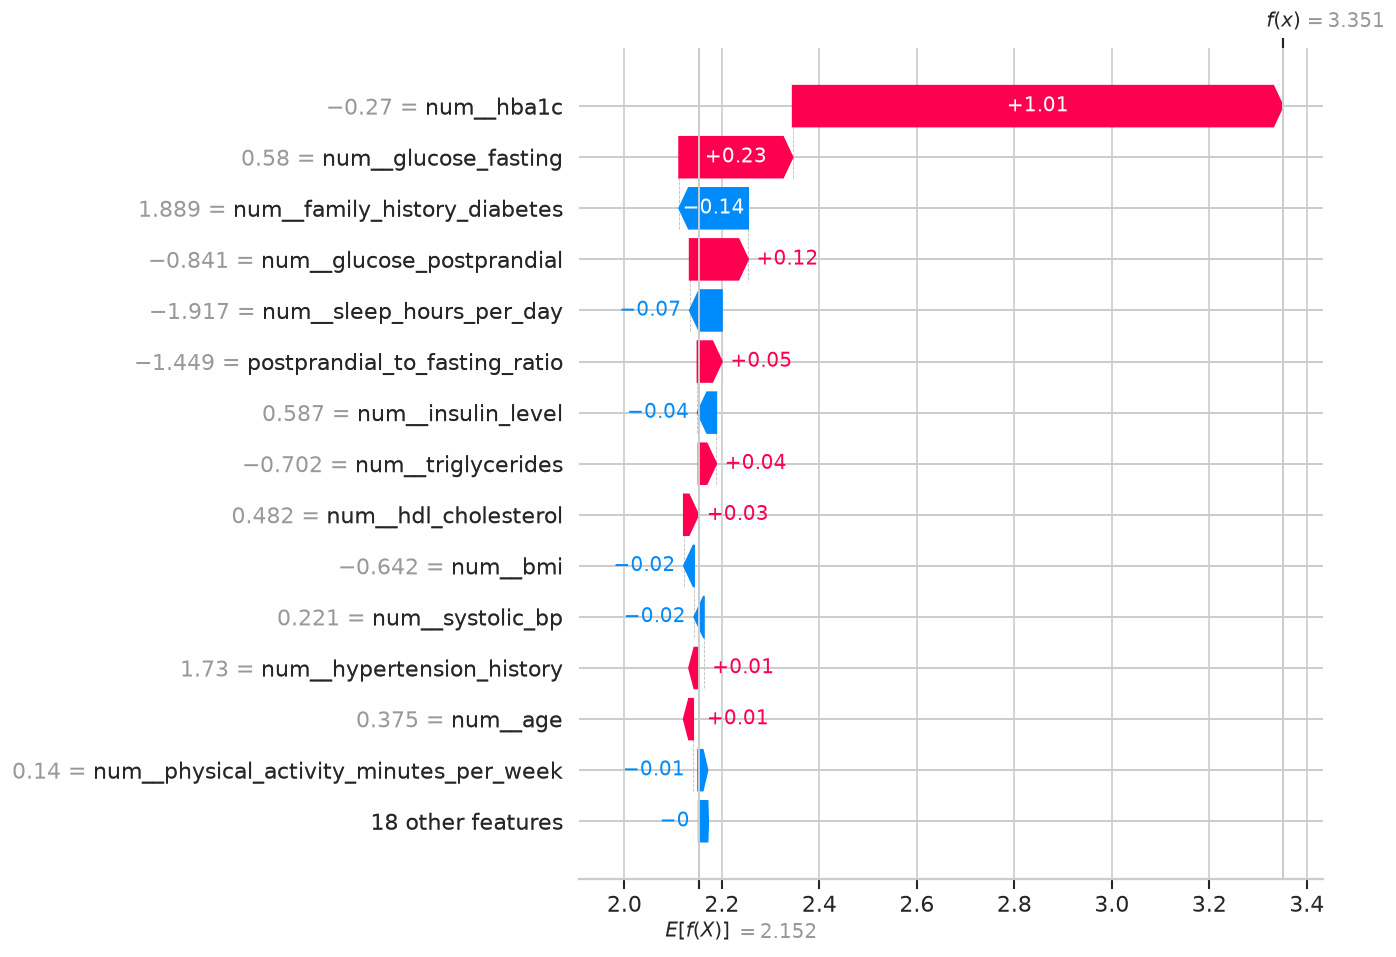

In [73]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CLASS NAMES
# ============================================================

class_names = {
 0: "Gestational Diabetes",
 1: "No Diabetes",
 2: "Pre-Diabetes",
 3: "Type 1 Diabetes",
 4: "Type 2 Diabetes"
}

# ============================================================
# SELECT SAMPLE
# ============================================================

sample_index = 3

sample = X_test_fe.iloc[[sample_index]]

true_label = int(y_test.iloc[sample_index])

# ============================================================
# MODEL PREDICTION
# ============================================================

prediction = int(xgb_model.predict(sample)[0])

probabilities = xgb_model.predict_proba(sample)[0]

print("="*70)
print("PATIENT PREDICTION")
print("="*70)

print(f"Predicted Class : {class_names[prediction]}")
print(f"Actual Class : {class_names[true_label]}")
print(f"Correct : {prediction == true_label}")

print("\nPrediction Probabilities")
print("-"*70)

for i, p in enumerate(probabilities):
 print(f"{class_names[i]:22s}: {p:.2%}")

# ============================================================
# CREATE SHAP EXPLAINER
# ============================================================

explainer = shap.TreeExplainer(xgb_model)

# SHAP explanation for ONE sample
explanation = explainer(sample)

# ============================================================
# EXTRACT SHAP VALUES FOR THE PREDICTED CLASS
# ============================================================

shap_values = explanation.values[0, :, prediction]

base_value = explanation.base_values[0, prediction]

# ============================================================
# CREATE FEATURE IMPORTANCE TABLE
# ============================================================

importance_df = pd.DataFrame({

 "Feature": sample.columns,

 "Feature Value": sample.iloc[0].values,

 "SHAP": shap_values

})

importance_df["ABS_SHAP"] = importance_df["SHAP"].abs()

importance_df = importance_df.sort_values(
 by="ABS_SHAP",
 ascending=False
)

# ============================================================
# FUNCTION TO DESCRIBE IMPACT STRENGTH
# ============================================================

def impact_strength(v):

 v = abs(v)

 if v >= 1:
  return "Strongly"

 elif v >= 0.50:
  return "Moderately"

 else:
  return "Slightly"

# ============================================================
# TOP FACTORS
# ============================================================

print("\n")
print("="*70)
print("TOP FACTORS BEHIND THIS PREDICTION")
print("="*70)

top_k = 5

for _, row in importance_df.head(top_k).iterrows():

 arrow = "↑" if row["SHAP"] > 0 else "↓"

 direction = (
 "increased"
 if row["SHAP"] > 0
 else
 "decreased"
 )

 strength = impact_strength(row["SHAP"])

 print(f"{arrow} {row['Feature']}")

 print(
 f" {strength} {direction} "
 f"the probability of "
 f"{class_names[prediction]}"
 )

 print(
 f" Feature Value : {row['Feature Value']}"
 )

 print(
 f" SHAP Value : {row['SHAP']:.4f}"
 )

 print()

# ============================================================
# WATERFALL PLOT
# ============================================================

exp = shap.Explanation(

 values=shap_values,

 base_values=base_value,

 data=sample.iloc[0].values,

 feature_names=sample.columns

)

print("="*70)
print("LOCAL SHAP EXPLANATION")
print("="*70)

shap.plots.waterfall(exp, max_display=15)